# Import Statements (libraries + Functions)

In [643]:
import numpy as np
import pandas as pd
import vcf
from tqdm import tqdm
import matplotlib.pyplot as plt
import seaborn as sns
import pickle

%matplotlib inline

In [644]:
#import sklearn

In [645]:
import scipy.stats
import scipy.stats as stats
from statsmodels.stats.proportion import proportions_ztest
from scipy.stats import spearmanr
from scipy.stats import ranksums

In [646]:
#from Bio import SeqIO

In [647]:
#import io

In [648]:
import json

In [649]:
# import screed
# import mmh3

In [650]:
#import subprocess

In [651]:
#from pycirclize import Circos

In [652]:
from matplotlib.patches import Patch
import matplotlib.patches as mpatches
from matplotlib.lines import Line2D
from matplotlib.patches import FancyArrowPatch
import matplotlib.ticker as mticker


In [653]:
# Define matplotlib plot style from config file
plt.style.use('../mgm.v1.mplstyle')

In [654]:
import matplotlib
matplotlib.rcParams['pdf.fonttype'] = 42
matplotlib.rcParams['ps.fonttype'] = 42

In [655]:
# https://bioframe.readthedocs.io/en/latest/guide-intervalops.html
import bioframe as bf
#import bioframe.vis

#### Define sets of coord cols for using BioFrame

In [656]:
Query_CoordCols = ("Query_Name", "Query_Start", "Query_End")
HmReg_CoordCols = ("Chr", "Start", "End")
HmRegion_CoordCols = HmReg_CoordCols
Epitope_CoordCols = ("Chrom", "Rv_Start", "Rv_End")
RE_CoordCols = ("seqname", "start_0based", "end_1based")
GenomeAnno_CoordCols = ("Chrom", "Start", "End")


#### Pandas Viewing Settings

In [657]:
pd.set_option('display.max_rows', 500)
pd.set_option('display.max_columns', 500)
pd.set_option('display.width', 1000)

# Defining Functions

### Define `DNA-Features-Viewer` Preprocessing Functions

In [658]:

def generate_Event_GraphicFeatures(i_GC_Events_DF):

    L_GFeats = []
    
    for i, row in i_GC_Events_DF.iterrows():
        
        Rv_Start = row["start_0based"]
        Rv_End = row["end_1based"]
        i_Event_ID = row["EventID"]

        Event_Feat = GraphicFeature(start = Rv_Start , end = Rv_End,
                                      label = i_Event_ID[-3:],
                                      linewidth = 0.5,
                                      color = "#CBC3E3", #"purple",
                                      thickness = 5, 
                                      fontdict = {"fontsize": 4},
                                      linecolor = "black")
        
        L_GFeats.append(Event_Feat)

    return L_GFeats


def AddEvents_ToGraphicRecord(Graphic_Record, i_GC_Events_DF):

    L_Event_GFeats = generate_Event_GraphicFeatures(i_GC_Events_DF)
    
    Graphic_Record.features = Graphic_Record.features + L_Event_GFeats

    return Graphic_Record


def generate_Epitope_GraphicFeatures(i_Epitopes_DF):

    L_GFeats = []
    
    for i, row in i_Epitopes_DF.iterrows():
        
        Rv_Start = row["Rv_Start"]
        Rv_End = row["Rv_End"]
        i_epitope_seq = row["Epitope_Seq"]
        i_epitope_ID = row["Epitope_ID"]

        Epitope_Feat = GraphicFeature(start = Rv_Start , end = Rv_End ,
                                      #label = i_epitope_ID,
                                      color = "darkred",
                                      linecolor = "black")
        
        L_GFeats.append(Epitope_Feat)

    return L_GFeats


def generate_AssayedEpitope_GraphicFeatures(i_Epitopes_DF):

    L_GFeats = []
    
    for i, row in i_Epitopes_DF.iterrows():
        
        Rv_Start = row["Rv_Start"]
        Rv_End = row["Rv_End"]
        i_epitope_seq = row["Epitope_Seq"]
        i_epitope_ID = row["Epitope_ID"]
        i_PosEpitope = row["PosEpitope_Any"]
        if i_PosEpitope == True:
    
            Epitope_Feat = GraphicFeature(start = Rv_Start , end = Rv_End ,
                                          #label = i_epitope_ID,
                                          linewidth = 0.5,
                                          color = "darkred",
                                          thickness = 5,
                                          linecolor = "black")
            
        else:
            Epitope_Feat = GraphicFeature(start = Rv_Start , end = Rv_End ,
                                          #label = i_epitope_ID,
                                          #linewidth = 0.5,
                                          color = "lightgrey", alpha = 0.3,
                                          thickness = 5,
                                          linewidth = 0.5,
                                          linecolor = "black")

            
        L_GFeats.append(Epitope_Feat)

    return L_GFeats


def AddEpitopes_ToGraphicRecord(Graphic_Record, i_Epitopes_DF):

    L_Epitope_GFeats = generate_Epitope_GraphicFeatures(i_Epitopes_DF)
    
    Graphic_Record.features = Graphic_Record.features + L_Epitope_GFeats

    return Graphic_Record




## Functions for Composite vizs of results + gene annotations
`H37Rv Gene Annoations` + `Epitope Mapping`, + `mutation frequency` + `GC Events`, `etc`

In [659]:
from typing import Optional, Tuple, Dict
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from typing import Optional, Tuple, Dict
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

def plot_Anno_Epitope_MutFreq(
    Viz_Start: int,
    Viz_End: int,
    in_PerCodon_MutCt_DF,                 # cols: Pos_0based, Mutation_Count
    in_Genome_Graphic_Record,             # dna_features_viewer GraphicRecord (H37Rv)
    in_AllPeptides_GraphicRecord,         # GraphicRecord of all assayed peptides
    in_EpitopeCov_DF,                     # cols: start, end, Cov_PosEpitopes
    *,
    mut_ylim: Optional[Tuple[float, float]] = (0, 15),
    figsize: Tuple[float, float] = (7, 3),
    height_ratios: Tuple[int, int, int, int] = (3, 5, 1, 4),
    cmap_name: str = "Reds",
    point_size: float = 2.0,
    vline_lw: float = 0.9,
    epi_linewidth: float = 2.5,
    genome_label_threshold: int = 5,
    show_bottom_xticks: bool = True,
    tight_layout: bool = True,
    epi_global_max: Optional[float] = None,   # 👈 new option
) -> Tuple[plt.Figure, Dict[str, plt.Axes]]:
    """
    Plot genomic annotations, per-codon mutation counts, epitope coverage summary,
    and assayed peptides for a window [Viz_Start, Viz_End].

    Epitope coverage colors are normalized to the global max of Cov_PosEpitopes
    across the entire in_EpitopeCov_DF.
    """
    # --- Crop graphic records to region ---
    Graphic_Record_cropped = in_Genome_Graphic_Record.crop((Viz_Start, Viz_End + 1))
    AllPeptides_Records_cropped = in_AllPeptides_GraphicRecord.crop((Viz_Start, Viz_End + 1))

    # --- Create figure & axes ---
    fig, axs = plt.subplots(
        4, 1, figsize=figsize,
        gridspec_kw={'height_ratios': height_ratios}
    )
    Genome_Anno_ax, MF_ax, EpiSumm_ax, AllAssayedPeptides_ax = axs

    # --- Gene Annotations ---
    if hasattr(Graphic_Record_cropped, "plot"):
        Graphic_Record_cropped.plot(strand_in_label_threshold=genome_label_threshold,
                                    ax=Genome_Anno_ax)
    Genome_Anno_ax.set_xlim(Viz_Start, Viz_End)
    Genome_Anno_ax.set_xticks([])

    # --- Mutation Counts ---
    if {"Pos_0based", "Mutation_Count"}.issubset(in_PerCodon_MutCt_DF.columns):
        mut_df = in_PerCodon_MutCt_DF.query(
            f"(Pos_0based + 1) >= {Viz_Start} & (Pos_0based + 1) <= {Viz_End}"
        ).copy()
        if not mut_df.empty:
            xvals = mut_df["Pos_0based"].to_numpy() + 1
            yvals = mut_df["Mutation_Count"].to_numpy()
            MF_ax.vlines(x=xvals, ymin=0, ymax=yvals, color="black", linewidth=vline_lw, alpha=0.6)
            MF_ax.scatter(x=xvals, y=yvals, color="red", s=point_size, alpha=1)

    MF_ax.xaxis.set_major_formatter(mticker.ScalarFormatter())
    MF_ax.ticklabel_format(style='plain', axis='x')
    MF_ax.xaxis.set_major_locator(mticker.MaxNLocator(integer=True))
    MF_ax.set_xlim(Viz_Start, Viz_End)
    if mut_ylim is not None:
        MF_ax.set_ylim(*mut_ylim)
    MF_ax.set_xticks([])
    sns.despine(ax=MF_ax)

    # --- Epitope density summary ---
    cmap = plt.get_cmap(cmap_name)
    if {"start", "end", "Cov_PosEpitopes"}.issubset(in_EpitopeCov_DF.columns):
        Reg_EpiCov_DF = in_EpitopeCov_DF.query(
            f"start >= {Viz_Start} & end <= {Viz_End}"
        ).copy()
        if not Reg_EpiCov_DF.empty:
            if epi_global_max is None:
                global_max = in_EpitopeCov_DF["Cov_PosEpitopes"].max()
            else:
                global_max = epi_global_max
                
            norm = plt.Normalize(vmin=0, vmax=global_max if global_max > 0 else 1)
            for _, row in Reg_EpiCov_DF.iterrows():
                cov = row["Cov_PosEpitopes"]
                if cov > 0:
                    EpiSumm_ax.vlines(x=row["start"], ymin=0, ymax=1,
                                      color=cmap(norm(cov)), linewidth=epi_linewidth, alpha=1)

    EpiSumm_ax.set_xlim(Viz_Start, Viz_End)
    EpiSumm_ax.set_ylim(0, 1)
    EpiSumm_ax.set_xticks([])
    EpiSumm_ax.set_yticks([])
    for spine in ("left", "top", "right"):
        EpiSumm_ax.spines[spine].set_visible(False)
    EpiSumm_ax.set_xlabel("")

    # --- Assayed peptides ---
    #if hasattr(AllPeptides_Records_cropped, "plot"):
    AllPeptides_Records_cropped.plot(strand_in_label_threshold=genome_label_threshold,
                                         ax=AllAssayedPeptides_ax)
    
    AllAssayedPeptides_ax.set_xlim(Viz_Start, Viz_End)
    AllAssayedPeptides_ax.set_ylim(-0.5, 5.5)


    # full integers on x-axis (no sci/offset)
    formatter = mticker.ScalarFormatter(useOffset=False)
    formatter.set_scientific(False)
    AllAssayedPeptides_ax.xaxis.set_major_formatter(formatter)
    AllAssayedPeptides_ax.ticklabel_format(style='plain', axis='x', useOffset=False)
    AllAssayedPeptides_ax.xaxis.set_major_locator(mticker.MaxNLocator(nbins=6, integer=True))
    
    if tight_layout:
        fig.tight_layout()

    axes = {
        "Genome_Anno_ax": Genome_Anno_ax,
        "MF_ax": MF_ax,
        "EpiSumm_ax": EpiSumm_ax,
        "AllAssayedPeptides_ax": AllAssayedPeptides_ax,
    }
    return fig, axes


### Functions - composite viz of `epitopes`,`mutation-freq`, and `GC events`

In [660]:
# Define all functions from scratch, then apply them to esxK/L and PPE18 regions.
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from matplotlib.patches import Rectangle
from pathlib import Path


# ------------------------
# Constants (colors + sizes)
# ------------------------
NT_COLORS = {"A": "green", "T": "red", "C": "blue", "G": "orange"}
EVENT_BAR_COLOR = "#C9A0DC"   # light purple

# ------------------------
# Helper functions
# ------------------------
def _to_int_series(s: pd.Series) -> pd.Series:
    """Convert a Series to Int64 safely (NaNs preserved)."""
    return pd.to_numeric(s, errors="coerce").astype("Int64")

def select_events_overlapping_region(pGCE_df: pd.DataFrame, start1: int, end1: int) -> pd.DataFrame:
    """
    Return events whose intervals intersect [start1, end1] (1-based, inclusive).
    Expects event columns: 'start_0based' and 'end_1based'.
    Adds '__start1__' and '__end1__' (both floats, 1-based) to the result.
    """
    start0 = _to_int_series(pGCE_df["start_0based"])
    end1b  = _to_int_series(pGCE_df["end_1based"])
    s1 = start0 + 1           # convert to 1-based
    e1 = end1b                # already 1-based
    mask = (e1 >= start1) & (s1 <= end1)
    out = pGCE_df.loc[mask].copy()
    out["__start1__"] = s1[mask].astype(float)
    out["__end1__"]   = e1[mask].astype(float)
    return out

def prepare_snps_positions(snps_df: pd.DataFrame) -> pd.DataFrame:
    """
    Create a '__pos1__' column (1-based position) using Pos_0based or Pos_1based.
    Keeps all other columns intact.
    """
    out = snps_df.copy()
    if "Pos_0based" in out.columns:
        out["__pos1__"] = out["Pos_0based"].astype(int) + 1
    elif "Pos_1based" in out.columns:
        out["__pos1__"] = out["Pos_1based"].astype(int)
    else:
        raise ValueError("SNPs DF must include 'Pos_0based' or 'Pos_1based'.")
    return out

def _format_x_plain(ax):
    """Force full integer tick labels (no scientific notation, no offset)."""
    formatter = mticker.ScalarFormatter(useOffset=False)
    formatter.set_scientific(False)
    ax.xaxis.set_major_formatter(formatter)
    ax.ticklabel_format(style='plain', axis='x', useOffset=False)
    ax.xaxis.set_major_locator(mticker.MaxNLocator(nbins=6, integer=True))

def _draw_event_rect(ax, y_center: float, x0: float, x1: float, bar_height: float, color: str = EVENT_BAR_COLOR):
    """Draw an event as a filled rectangle centered at y_center with given height."""
    width = max(0.0, x1 - x0)
    rect = Rectangle((x0, y_center - bar_height/2), width, bar_height,
                     facecolor=color, edgecolor='none', alpha=0.9)
    ax.add_patch(rect)

# ------------------------
# Plotting functions
# ------------------------
def plot_multi_event_snp_stack(
    region_start1: int,
    region_end1:   int,
    pGCE_df: pd.DataFrame,
    snps_df: pd.DataFrame,
    *,
    bar_height: float = 0.5,         # thickness of each event bar
    snp_line_width: float = 0.9, #1.2,     # SNP tick thickness
    label_fontsize: int = 8,
    fig_width: float = 9.0,
    dpi: int = 180,
    title: str | None = None,
    outfile: str | None = None,
):
    """
    Stacked view: one row per overlapping event. Labels are placed slightly ABOVE each event.
    SNP ticks span the same height as the event bar.
    """
    # Choose events & SNPs in the window
    events = select_events_overlapping_region(pGCE_df, region_start1, region_end1)
    if events.empty:
        raise ValueError("No events overlap the requested region.")
    events = events.sort_values(["__start1__", "__end1__"]).reset_index(drop=True)

    snps = prepare_snps_positions(snps_df)
    snps_in_region = snps[(snps["__pos1__"] >= region_start1) & (snps["__pos1__"] <= region_end1)].copy()

    # Layout
    n = len(events)
    fig_height = max(1.5, 0.38 * n + 1.0)
    fig, ax = plt.subplots(figsize=(fig_width, fig_height), dpi=dpi)
    y_levels = np.arange(n, dtype=float)[::-1]  # top to bottom

    # Draw
    for idx, (_, ev) in enumerate(events.iterrows()):
        y = y_levels[idx]
        x0 = max(region_start1, float(ev["__start1__"]))
        x1 = min(region_end1,   float(ev["__end1__"]))
        _draw_event_rect(ax, y, x0, x1, bar_height, EVENT_BAR_COLOR)

        # SNPs (same height)
        s_ev = snps_in_region[snps_in_region["EventID"] == ev["EventID"]]
        if not s_ev.empty:
            ymin = y - bar_height/2
            ymax = y + bar_height/2
            for _, r in s_ev.iterrows():
                xv = float(r["__pos1__"])
                nt = str(r.get("Child_Call", "")).upper()[:1]
                color = NT_COLORS.get(nt, "black")
                ax.vlines(x=xv, ymin=ymin, ymax=ymax, lw=snp_line_width, color=color, alpha=0.95)

        # Label above the bar
        x_mid = (x0 + x1) / 2.0
        ax.text(x_mid, y + 0.7 * bar_height, str(ev["EventID"]),
                ha="center", va="bottom", fontsize=label_fontsize)

    # Cosmetics
    ax.set_xlim(region_start1, region_end1)
    ax.set_ylim(-0.8, len(y_levels) - 1 + 0.8)
    ax.set_yticks([])
    ax.set_xlabel("Genomic position (1-based)")
    _format_x_plain(ax)
    ax.grid(axis="x", linestyle=":", linewidth=0.5, alpha=0.4)

    from matplotlib.lines import Line2D
    legend_elems = [Line2D([0], [0], color=NT_COLORS[k], lw=2, label=k) for k in ["A","T","C","G"] if k in NT_COLORS]
    ax.legend(handles=legend_elems, title="Mut allele", fontsize=8, title_fontsize=9, loc="upper right")

    if title is None:
        title = f"Events & SNPs in region {region_start1}-{region_end1}"
    ax.set_title(title, fontsize=10)

    fig.tight_layout()
    if outfile:
        fig.savefig(outfile, bbox_inches="tight")
        return fig, ax, outfile
    return fig, ax, None
import numpy as np
import pandas as pd
import matplotlib.ticker as mticker
from matplotlib.patches import Rectangle
from matplotlib.lines import Line2D

def plot_multi_event_snp_packed_on_ax(
    ax,
    region_start1: int,
    region_end1:   int,
    pGCE_df: pd.DataFrame,
    snps_df: pd.DataFrame,
    *,
    min_gap: int = 0,                 # bp gap required to share a row
    bar_height: float = 0.5,          # thickness of each event bar
    snp_line_width: float = 1.2,      # SNP tick thickness
    label_fontsize: int = 8,
    nt_colors: dict | None = None,    # e.g. {"A":"green","T":"red","C":"blue","G":"orange"}
    event_bar_color: str = "#C9A0DC", # light purple
    hide_spines: tuple[str, ...] = ("left", "top", "right"),
    show_xlabel: bool = True,
    title: str | None = None,
    add_legend: bool = False,
):
    """
    Packed view: non-overlapping events (within [region_start1, region_end1], 1-based)
    share rows to save vertical space. Draws onto the provided Matplotlib Axes `ax`.

    Returns
    -------
    ax, summary
      summary = {"nrows": int, "events_plotted": list[str], "window": (start1, end1)}
    """
    # defaults
    if nt_colors is None:
        nt_colors = {"A":"green", "T":"red", "C":"blue", "G":"orange"}

    # --- Select events that overlap the window (convert to 1-based) ---
    s1 = pd.to_numeric(pGCE_df["start_0based"], errors="coerce").astype("Int64") + 1
    e1 = pd.to_numeric(pGCE_df["end_1based"],   errors="coerce").astype("Int64")
    mask = (e1 >= region_start1) & (s1 <= region_end1)
    events = pGCE_df.loc[mask].copy()
    if events.empty:
        print("No events overlap the requested region.")
        return ax, None
        #raise ValueError("No events overlap the requested region.")
        
    events["__start1__"] = s1[mask].astype(float)
    events["__end1__"]   = e1[mask].astype(float)

    # Clip to window & sort for packing
    events["__clip_start__"] = np.maximum(events["__start1__"].values, region_start1)
    events["__clip_end__"]   = np.minimum(events["__end1__"].values,   region_end1)
    events = events.sort_values(["__clip_start__", "__clip_end__"]).reset_index(drop=True)

    # --- Greedy row packing (no overlaps on the same row) ---
    rows_last_end = []
    row_of_event = []
    for _, ev in events.iterrows():
        placed = False
        s = float(ev["__clip_start__"])
        e = float(ev["__clip_end__"])
        for ri in range(len(rows_last_end)):
            if s > (rows_last_end[ri] + min_gap):
                row_of_event.append(ri)
                rows_last_end[ri] = e
                placed = True
                break
        if not placed:
            row_of_event.append(len(rows_last_end))
            rows_last_end.append(e)
    events["__row__"] = row_of_event

    # --- Prepare SNPs (get 1-based position) ---
    snps = snps_df.copy()
    if "Pos_0based" in snps.columns:
        snps["__pos1__"] = snps["Pos_0based"].astype(int) + 1
    elif "Pos_1based" in snps.columns:
        snps["__pos1__"] = snps["Pos_1based"].astype(int)
    else:
        raise ValueError("SNPs DF must include 'Pos_0based' or 'Pos_1based'.")
    snps_in_region = snps[(snps["__pos1__"] >= region_start1) & (snps["__pos1__"] <= region_end1)].copy()

    # --- Layout and draw ---
    nrows = int(events["__row__"].max()) + 1
    for _, ev in events.iterrows():
        r = int(ev["__row__"])
        y = (nrows - 1 - r)  # row 0 at top
        x0 = float(ev["__clip_start__"])
        x1 = float(ev["__clip_end__"])

        # event rectangle
        width = max(0.0, x1 - x0)
        rect = Rectangle((x0, y - bar_height/2), width, bar_height,
                         facecolor=event_bar_color, edgecolor='none', alpha=0.9)
        ax.add_patch(rect)

        # SNP ticks (span full bar height)
        s_ev = snps_in_region[snps_in_region["EventID"] == ev["EventID"]]
        if not s_ev.empty:
            ymin = y - bar_height/2
            ymax = y + bar_height/2
            for _, rS in s_ev.iterrows():
                xv = float(rS["__pos1__"])
                nt = str(rS.get("Child_Call", "")).upper()[:1]
                color = nt_colors.get(nt, "black")
                ax.vlines(x=xv, ymin=ymin, ymax=ymax, lw=snp_line_width, color=color, alpha=0.95)

        # label above bar
        x_mid = (x0 + x1) / 2.0
        ax.text(x_mid, y + 0.7 * bar_height, str(ev["EventID"]),
                ha="center", va="bottom", fontsize=label_fontsize)

    # --- Cosmetics ---
    ax.set_xlim(region_start1, region_end1)
    ax.set_ylim(-0.8, nrows - 1 + 0.8)
    ax.set_yticks([])
    if show_xlabel:
        ax.set_xlabel("Genomic position (1-based)")

    # full integers on x-axis (no sci/offset)
    formatter = mticker.ScalarFormatter(useOffset=False)
    formatter.set_scientific(False)
    ax.xaxis.set_major_formatter(formatter)
    ax.ticklabel_format(style='plain', axis='x', useOffset=False)
    ax.xaxis.set_major_locator(mticker.MaxNLocator(nbins=6, integer=True))

    ax.grid(axis="x", linestyle=":", linewidth=0.5, alpha=0.4)
    for spine in hide_spines:
        ax.spines[spine].set_visible(False)

    if add_legend:
        legend_elems = [Line2D([0], [0], color=nt_colors[k], lw=2, label=k)
                        for k in ["A","T","C","G"] if k in nt_colors]
        ax.legend(handles=legend_elems, title="Mut allele", fontsize=8, title_fontsize=9,
                  loc="upper right")

    if title is not None:
        ax.set_title(title, fontsize=10)

    summary = {
        "nrows": int(nrows),
        "events_plotted": events["EventID"].tolist(),
        "window": (region_start1, region_end1),
    }
    return ax, summary


In [661]:
from typing import Optional, Tuple, Dict
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

def plot_mut_epitope_region_with_gce_V2(
    Viz_Start: int,
    Viz_End: int,
    in_PerCodon_MutCt_DF,                 # cols: Pos_0based, Mutation_Count
    in_Genome_Graphic_Record,             # dna_features_viewer GraphicRecord (H37Rv)
    in_AllPeptides_GraphicRecord,         # GraphicRecord of all assayed peptides
    in_EpitopeCov_DF,                     # cols: start, end, Cov_PosEpitopes
    pGCE_df,          
    snps_df,
    *,
    mut_ylim: Optional[Tuple[float, float]] = (0, 15),
    figsize: Tuple[float, float] = (5, 5),
    height_ratios: Tuple[int, int, int, int, int] = (4, 5, 1, 4, 8),
    cmap_name: str = "Reds",
    point_size: float = 2.0,
    vline_lw: float = 0.9,
    epi_linewidth: float = 2.5,
    genome_label_threshold: int = 5,
    # GC-event track style
    gce_min_gap: int = 0,
    gce_bar_height: float = 0.5,
    gce_snp_line_width: float = 1.2,
    gce_label_fontsize: int = 8,
    show_bottom_xticks: bool = True,
    tight_layout: bool = True,
    epi_global_max: Optional[float] = None,   # if None, uses global max from in_EpitopeCov_DF
) -> Tuple[plt.Figure, Dict[str, plt.Axes]]:
    """
    Same as plot_mut_epitope_region, but adds a GC events track at the bottom.

    Axes order (top→bottom):
      0: Genome_Anno_ax (gene annotations)
      1: MF_ax          (mutation counts)
      2: EpiSumm_ax     (epitope density summary bar)
      3: AllAssayedPeptides_ax (all assayed peptides)
      4: GCE_ax         (gene conversion events)
    """
    # --- Crop graphic records to region ---
    Graphic_Record_cropped   = in_Genome_Graphic_Record.crop((Viz_Start, Viz_End + 1))
    AllPeptides_Records_cropped = in_AllPeptides_GraphicRecord.crop((Viz_Start, Viz_End + 1))

    # --- Create figure & axes ---
    fig, axs = plt.subplots(
        5, 1, figsize=figsize,
        gridspec_kw={'height_ratios': height_ratios}
    )
    Genome_Anno_ax, MF_ax, EpiSumm_ax, AllAssayedPeptides_ax, GCE_ax = axs

    # --- Gene Annotations (top track) ---
    if hasattr(Graphic_Record_cropped, "plot"):
        Graphic_Record_cropped.plot(strand_in_label_threshold = genome_label_threshold,
                                    ax=Genome_Anno_ax)
    Genome_Anno_ax.set_xlim(Viz_Start, Viz_End)
    Genome_Anno_ax.set_xticks([])

    # --- Mutation Counts ---
    if {"Pos_0based", "Mutation_Count"}.issubset(in_PerCodon_MutCt_DF.columns):
        mut_df = in_PerCodon_MutCt_DF.query(
            f"(Pos_0based + 1) >= {Viz_Start} & (Pos_0based + 1) <= {Viz_End}"
        ).copy()
        if not mut_df.empty:
            xvals = mut_df["Pos_0based"].to_numpy() + 1
            yvals = mut_df["Mutation_Count"].to_numpy()
            MF_ax.vlines(x=xvals, ymin=0, ymax=yvals, color="black", linewidth=vline_lw, alpha=0.6)
            MF_ax.scatter(x=xvals, y=yvals, color="red", s=point_size, alpha=1)

    MF_ax.xaxis.set_major_formatter(mticker.ScalarFormatter())
    MF_ax.ticklabel_format(style='plain', axis='x')
    MF_ax.xaxis.set_major_locator(mticker.MaxNLocator(integer=True))
    MF_ax.set_xlim(Viz_Start, Viz_End)
    if mut_ylim is not None:
        MF_ax.set_ylim(*mut_ylim)
    MF_ax.set_xticks([])
    sns.despine(ax=MF_ax)

    # --- Epitope density summary (global-normalized) ---
    cmap = plt.get_cmap(cmap_name)
    if {"start", "end", "Cov_PosEpitopes"}.issubset(in_EpitopeCov_DF.columns):
        Reg_EpiCov_DF = in_EpitopeCov_DF.query(
            f"start >= {Viz_Start} & end <= {Viz_End}"
        ).copy()
        if not Reg_EpiCov_DF.empty:
            global_max = (in_EpitopeCov_DF["Cov_PosEpitopes"].max()
                          if epi_global_max is None else float(epi_global_max))
            norm = plt.Normalize(vmin=0, vmax=global_max if global_max > 0 else 1)
            for _, row in Reg_EpiCov_DF.iterrows():
                cov = row["Cov_PosEpitopes"]
                if cov > 0:
                    EpiSumm_ax.vlines(x=row["start"], ymin=0, ymax=1,
                                      color=cmap(norm(cov)), linewidth=epi_linewidth, alpha=1)

    EpiSumm_ax.set_xlim(Viz_Start, Viz_End)
    EpiSumm_ax.set_ylim(0, 1)
    EpiSumm_ax.set_xticks([])
    EpiSumm_ax.set_yticks([])
    for spine in ("left", "top", "right"):
        EpiSumm_ax.spines[spine].set_visible(False)
    EpiSumm_ax.set_xlabel("")


    # --- Assayed peptides ---
    if hasattr(AllPeptides_Records_cropped, "plot"):
        AllPeptides_Records_cropped.plot(strand_in_label_threshold=genome_label_threshold,
                                         ax=AllAssayedPeptides_ax)
    AllAssayedPeptides_ax.set_xlim(Viz_Start, Viz_End)
    AllAssayedPeptides_ax.set_ylim(-0.5, 5.5)
    AllAssayedPeptides_ax.set_xticks([])

    
    # --- GC events (bottom track) ---
    
    
    plot_multi_event_snp_packed_on_ax(GCE_ax,
                                      region_start1 = Viz_Start, region_end1 = Viz_End,
                                      pGCE_df = pGCE_DF, snps_df = snps_df, label_fontsize = 4,
                                      add_legend=False, )

    plot_multi_event_snp_packed_on_ax(GCE_ax,
                                      region_start1=Viz_Start, region_end1=Viz_End,
                                      pGCE_df = pGCE_df,
                                      snps_df = snps_df,
                                      min_gap=gce_min_gap,
                                      bar_height=gce_bar_height,
                                      snp_line_width=gce_snp_line_width,
                                      label_fontsize=gce_label_fontsize,
                                      #show_xlabel=show_xlabel_on_gce,
                                      add_legend=False,
                                      title=None,)



    if show_bottom_xticks:
        GCE_ax.xaxis.set_major_formatter(mticker.ScalarFormatter())
        GCE_ax.ticklabel_format(style='plain', axis='x')
        GCE_ax.xaxis.set_major_locator(mticker.MaxNLocator(integer=True))




    
    if tight_layout:
        fig.tight_layout()

    axes = {
        "Genome_Anno_ax": Genome_Anno_ax,
        "MF_ax": MF_ax,
        "EpiSumm_ax": EpiSumm_ax,
        "AllAssayedPeptides_ax": AllAssayedPeptides_ax,
        "GCE_ax": GCE_ax,
    }
    return fig, axes


### Define function for ploting Anno + GCEs in a region

In [662]:
from typing import Optional, Tuple, Dict
import matplotlib.pyplot as plt

def plot_Anno_with_GCE(
    Viz_Start: int,
    Viz_End: int,
    in_Genome_Graphic_Record,   # dna_features_viewer GraphicRecord (H37Rv)
    pGCE_df,                    # GC events dataframe
    snps_df,                    # SNPs dataframe (Pos_0based or Pos_1based, EventID, Child_Call)
    *,
    figsize: Tuple[float, float] = (5, 5), 
    dpi: int = 180,                            
    height_ratios: Tuple[float, float] = (1.0, 2.5),
    genome_label_threshold: int = 5,
    # GC-event track style
    gce_min_gap: int = 0,
    gce_bar_height: float = 0.5,
    gce_snp_line_width: float = 1.2,
    gce_label_fontsize: int = 8,
    show_xlabel_on_gce: bool = True,
    title: Optional[str] = None,
    tight_layout: bool = True,
) -> Tuple[plt.Figure, Dict[str, plt.Axes]]:
    """
    Plot gene annotations (top) and packed GC events with SNPs (bottom).
    Returns (fig, {'Genome_Anno_ax':..., 'GCE_ax':...}).
    """
    # Crop genome record to region
    Graphic_Record_cropped = in_Genome_Graphic_Record.crop((Viz_Start, Viz_End + 1))

    # Figure & axes
    fig, axs = plt.subplots(
        2, 1, figsize=figsize, dpi=dpi,
        gridspec_kw={'height_ratios': height_ratios}
    )
    Genome_Anno_ax, GCE_ax = axs

    # Top: gene annotations
    if hasattr(Graphic_Record_cropped, "plot"):
        Graphic_Record_cropped.plot(
            strand_in_label_threshold=genome_label_threshold, ax=Genome_Anno_ax
        )
    Genome_Anno_ax.set_xlim(Viz_Start, Viz_End)
    Genome_Anno_ax.set_xticks([])
    Genome_Anno_ax.set_xlabel("")

    # Bottom: packed GC events + SNPs (uses your on-axis helper)
    plot_multi_event_snp_packed_on_ax(
        GCE_ax,
        region_start1=Viz_Start, region_end1=Viz_End,
        pGCE_df=pGCE_df, snps_df=snps_df,
        min_gap=gce_min_gap,
        bar_height=gce_bar_height,
        snp_line_width=gce_snp_line_width,
        label_fontsize=gce_label_fontsize,
        show_xlabel=show_xlabel_on_gce,
        add_legend=False,
        title=None
    )

    if title:
        fig.suptitle(title, fontsize=11)

    if tight_layout:
        fig.tight_layout()

    return fig, {"Genome_Anno_ax": Genome_Anno_ax, "GCE_ax": GCE_ax}


# Parse `Mtb151CI` Isolate Metadata

In [663]:
Repo_DataDir = "../../Data"
InputAsmPath_Dir = f"{Repo_DataDir}/231121.InputAsmTSVs.MtbSetV3.151CI"

MtbSetV3_151CI_InputAsmPATHs_TSV = f"{InputAsmPath_Dir}/231121.MtbSetV3.151CI.HybridAndSRAsm.FAPATHs.V1.tsv"
MtbSetV3_151CI_AsmSumm_TSV = f"{InputAsmPath_Dir}/231121.MtbSetV3.151CI.HybridAsm.AsmSummary.V2.tsv"


### Reading in "WGA151CI_AsmSummary_DF"

In [664]:
WGA151CI_AsmSummary_DF = pd.read_csv(MtbSetV3_151CI_AsmSumm_TSV, sep = "\t")

SampleIDs_151CI_SOI = list( WGA151CI_AsmSummary_DF["SampleID"].values )
WGA151CI_SampleIDs = SampleIDs_151CI_SOI
WGA151CI_AsmSummary_DF.shape


(151, 7)

#### Create SampleID Mapping Dicts

In [665]:
WGA151CI_ID_To_PrimLineage_Dict = dict(WGA151CI_AsmSummary_DF[['SampleID', 'PrimaryLineage']].values)
WGA151CI_ID_To_SubLineage_Dict = dict( WGA151CI_AsmSummary_DF[["SampleID", "Lineage"]].values)
WGA151CI_ID_To_Dataset_Dict = dict(WGA151CI_AsmSummary_DF[['SampleID', 'Dataset_Tag']].values)  
ID_To_PrimLineage_Dict = dict(WGA151CI_AsmSummary_DF[['SampleID', 'PrimaryLineage']].values)
ID_To_SubLineage_Dict = dict( WGA151CI_AsmSummary_DF[["SampleID", "Lineage"]].values)
ID_To_Dataset_Dict = dict(WGA151CI_AsmSummary_DF[['SampleID', 'Dataset_Tag']].values)  


# Import/parse processed H37rv genome annotations

In [666]:
RepoRef_Dir = "../../References"

AnnotatedGenes_And_IntergenicRegions_RepoRef_Dir = f"{RepoRef_Dir}/201027_H37rv_AnnotatedGenes_And_IntergenicRegions"
H37Rv_GenomeAnnotations_Genes_TSV = f"{AnnotatedGenes_And_IntergenicRegions_RepoRef_Dir}/H37Rv_GenomeAnnotations.Genes.tsv"

## H37Rv Gene Annotations TSV
H37Rv_GenomeAnno_Genes_DF = pd.read_csv(H37Rv_GenomeAnnotations_Genes_TSV, sep = "\t")
H37Rv_GeneInfo_Subset_DF = H37Rv_GenomeAnno_Genes_DF[["H37rv_GeneID", "Symbol", "Feature", "Functional_Category", "Is_Pseudogene", "Product", "PEandPPE_Subfamily", "ExcludedGroup_Category"]]

RvID_To_Symbol_Dict = dict(H37Rv_GenomeAnno_Genes_DF[['H37rv_GeneID', 'Symbol']].values)
Symbol_To_RvID_Dict = dict(H37Rv_GenomeAnno_Genes_DF[['Symbol', 'H37rv_GeneID']].values)
Symbol_To_FuncCat_Dict = dict(H37Rv_GenomeAnno_Genes_DF[['Symbol', 'Functional_Category']].values)

ESX_Genes_List_TSV = f"{RepoRef_Dir}/190927_H37rv_ListOf_ESXgenes.tsv"
Esx_Genes_DF = pd.read_csv(ESX_Genes_List_TSV, sep = '\t')

In [667]:
H37Rv_GenomeAnno_Genes_DF.head(1)

,Chrom,Start,End,Strand,H37rv_GeneID,Symbol,Feature,Functional_Category,Is_Pseudogene,Product,PEandPPE_Subfamily,ExcludedGroup_Category
0,NC_000962.3,0,1524,+,Rv0001,dnaA,CDS,information pathways,No,Chromosomal replication initiator protein DnaA,NaN,NotExcluded


### Parse the WHO AR Variant Catalog (Mtb)

In [668]:
WHO_ResVar_DF = pd.read_csv("../../References/WHO_MtbAMR_Catalog/WHO_resistance_variants_all.csv", sep =",")
WHO_ResVar_LVL1_DF = WHO_ResVar_DF[ WHO_ResVar_DF["confidence"] == '1) Assoc w R']
WHO_ResVar_DF.shape

(17419, 5)

In [669]:
WHO_ResVar_LVL1_DF.shape

(201, 5)

In [670]:
WHO_ConfResGenes = list(WHO_ResVar_LVL1_DF["gene"].unique())
print(len(WHO_ConfResGenes))
print( WHO_ConfResGenes )

15
['inhA', 'rrs', 'eis', 'tlyA', 'embB', 'embA', 'ethA', 'katG', 'gyrA', 'rplC', 'gyrB', 'pncA', 'rpoB', 'rpsL', 'gid']


# Parse H37Rv Reference sequences (Genome, Genes, Proteins)

## Parse H37Rv genome sequence (DNA)

In [671]:
from Bio import SeqIO


In [672]:
H37rv_Ref_GBK_PATH = "/n/data1/hms/dbmi/farhat/mm774/References/GCF_000195955.2_ASM19595v2_genomic.gbk"
H37Rv_FA = "/n/data1/hms/dbmi/farhat/mm774/References/GCF_000195955.2_ASM19595v2_genomic.fasta"

H37Rv_Seq = SeqIO.read(H37Rv_FA, "fasta").seq
len(H37Rv_Seq)

4411532

## Parse H37Rv Protein (AA) and gene (DNA) sequences

In [673]:
O2_RefDir = "/n/data1/hms/dbmi/farhat/mm774/References"

MycoBrowser_RefFiles_Dir = f"{O2_RefDir}/190619_Mycobrowser_H37rv_ReferenceFiles"

H37Rv_Proteins_MycoBro_FAA = f"{MycoBrowser_RefFiles_Dir}/Mycobacterium_tuberculosis_H37Rv_proteins_v3_TrimmedHeader.fasta"
H37Rv_Proteins_MycoBro_FAA = f"{MycoBrowser_RefFiles_Dir}/Mycobacterium_tuberculosis_H37Rv_proteins_v3_TrimmedHeader.esxM_Added.fasta"
H37Rv_Proteins_NCBI_FAA = f"{MycoBrowser_RefFiles_Dir}/Mycobacterium_tuberculosis_H37Rv_proteins_v3_TrimmedHeader.fasta"
H37RV_Genes_FA = f"{MycoBrowser_RefFiles_Dir}/Mycobacterium_tuberculosis_H37Rv_genes_v3.fasta"



H37Rv_FAA_PATH = f"{O2_RefDir}/GCF_000195955.2_ASM19595v2_proteins.faa"
H37Rv_FAA_PATH = f"{O2_RefDir}/GCF_000195955.2_ASM19595v2_proteins.esxM_Added.faa"
H37Rv_GBK_PATH = f"{O2_RefDir}/GCF_000195955.2_ASM19595v2_genomic.gbk"


In [674]:
!ls -1 $MycoBrowser_RefFiles_Dir

Mycobacterium_tuberculosis_H37Rv_genes_v3.fasta
Mycobacterium_tuberculosis_H37Rv_genome_v3.fasta
Mycobacterium_tuberculosis_H37Rv_genome_v3.fasta.fai
Mycobacterium_tuberculosis_H37Rv_gff_v3.gff
Mycobacterium_tuberculosis_H37Rv_gff_v3.REP13E12_Regions.gff
Mycobacterium_tuberculosis_H37Rv_proteins_v3.fasta
Mycobacterium_tuberculosis_H37Rv_proteins_v3_TrimmedHeader.esxM_Added.fasta
Mycobacterium_tuberculosis_H37Rv_proteins_v3_TrimmedHeader.fasta
Mycobacterium_tuberculosis_H37Rv_txt_v3_PEPPE_subfamilies.txt
Mycobacterium_tuberculosis_H37Rv_txt_v3.txt.tsv


### Parse MycoBrowser Protein Seq Ref

In [675]:
dictOf_H37Rv_MycoBrow_ProtSeq = {}

for index, record in tqdm(enumerate(SeqIO.parse(H37Rv_Proteins_MycoBro_FAA, "fasta"))):
    ShortID = record.name
    
    dictOf_H37Rv_MycoBrow_ProtSeq[ShortID] = record.seq


4091it [00:00, 125275.78it/s]


### Parse MycoBrowser Gene Seq Ref

In [676]:
dictOf_H37Rv_MycoBrow_Gene_Seq = {}

for index, record in tqdm(enumerate(SeqIO.parse(H37RV_Genes_FA, "fasta"))):

    ShortID = record.name.split("|")[0]
    dictOf_H37Rv_MycoBrow_Gene_Seq[ShortID] = record.seq


4187it [00:00, 87638.61it/s]


In [677]:
list(dictOf_H37Rv_MycoBrow_Gene_Seq.keys())[:2]

['Rv3728', 'Rv3729']

### Parse NCBI Protein Seq Ref

In [678]:
dictOf_H37Rv_ProtSeq = {}
dictOf_H37Rv_ProtRecord = {}

for index, record in tqdm(enumerate(SeqIO.parse(H37Rv_FAA_PATH, "fasta"))):
    Rec_Description = record.description
    dict_Attr = {}
    for i in Rec_Description.split(" "):
        ###Just looking for line with " " character (as key = value)
        if "=" in i:
            key = i.strip().split("=")[0].strip('"').strip('[')
            value = i.strip().split("=")[1].strip('"').strip(']')
            ###Put them in a dictionnary
            dict_Attr[key]=value
    
    ShortID = dict_Attr["locus_tag"]
    dictOf_H37Rv_ProtSeq[ShortID] = record.seq
    dictOf_H37Rv_ProtRecord[ShortID] = record


3907it [00:00, 91099.93it/s]


In [679]:
#dictOf_H37Rv_ProtSeq["Rv1196"]

In [680]:
#dictOf_H37Rv_ProtSeq["Rv1196"] == dictOf_H37Rv_MycoBrow_ProtSeq["Rv1196"]

In [681]:
dictOf_H37Rv_ProtSeq["Rv1792"]

Seq('MASRFMTDPHAMRDMAGRFEVHAQTVEDEARRMWASAQNISGAGWSGMAEATSLDTMT')

In [682]:
dictOf_H37Rv_MycoBrow_ProtSeq["Rv1792"]

Seq('MASRFMTDPHAMRDMAGRFEVHAQTVEDEARRMWASAQNISGAGWSGMAEATSLDTMT')

# Parse in H37Rv Homology-Map Results (k19w19)

### Define all HmMap file paths

In [683]:
Main_Project_Dir = "/n/data1/hms/dbmi/farhat/mm774/Projects/Mtb_WGA_Analysis_V9"

H37_Rv_MM2_HomologyMapping_Dir = f"{Main_Project_Dir}/250901.H37Rv.HomologyMapping.k19w19.ProcessedData.V2"

# Define paths to output TSVS

### Homologous regions (MERGED)
RvHmMap_Merged_ParaRegions_TSV  = f"{H37_Rv_MM2_HomologyMapping_Dir}/RvHmMap.MergedRegions.ParalogousRegions.k19w19.tsv"
RvHmMap_Merged_LocalRepeats_TSV = f"{H37_Rv_MM2_HomologyMapping_Dir}/RvHmMap.MergedRegions.LocalRepeats.k19w19.tsv"

### Homology map (pairwise alignments)
RvHmMap_Aln_All_TSV           = f"{H37_Rv_MM2_HomologyMapping_Dir}/RvHmMap.k19w19.Aln.All.tsv"
RvHmMap_Aln_PRs_NoOverlap_TSV = f"{H37_Rv_MM2_HomologyMapping_Dir}/RvHmMap.k19w19.Aln.NoOverlap.tsv"
RvHmMap_Aln_LRs_WiOverlap_TSV = f"{H37_Rv_MM2_HomologyMapping_Dir}/RvHmMap.k19w19.Aln.WiOverlap.tsv"

RvHmMap_Aln_PRs_NoOverlap_Clustered_TSV     = f"{H37_Rv_MM2_HomologyMapping_Dir}/RvHmMap.k19w19.Aln.NoOverlap.Clustered.tsv"
RvHmMap_Aln_LRs_WiOverlap_Clustered_TSV     = f"{H37_Rv_MM2_HomologyMapping_Dir}/RvHmMap.k19w19.Aln.OnlyOverlap.Clustered.tsv"

### Variants from the homology map alignments
RvHmMap_Var_TSV      = f"{H37_Rv_MM2_HomologyMapping_Dir}/RvHmMap.k19w19.variants.tsv"
RvHmMap_Var_SNPs_TSV = f"{H37_Rv_MM2_HomologyMapping_Dir}/RvHmMap.k19w19.variants.snps.tsv"


### Parse in HmRegions (`Paralogous_Regions` and `Local_Repeats`)

In [684]:
HmMapRegs_ParaRegs_k19w19_DF = pd.read_csv(RvHmMap_Merged_ParaRegions_TSV,
                                    sep="\t")
#HmMapRegs_ParaRegs_k19w19_DF["Overlap_Genes"] = HmMapRegs_ParaRegs_k19w19_DF["Overlap_Genes"].fillna("_")

HmMapRegs_ParaRegs_k19w19_DF.shape

(200, 13)

In [685]:
Rv_HHR_DF = HmMapRegs_ParaRegs_k19w19_DF
Rv_HHR_DF.shape

(200, 13)

In [686]:
HmMapRegs_LocalRepeats_k19w19_DF = pd.read_csv(RvHmMap_Merged_LocalRepeats_TSV, 
                                        sep="\t")

#HmMapRegs_LocalRepeats_k19w19_DF["Overlap_Genes"] = HmMapRegs_LocalRepeats_k19w19_DF["Overlap_Genes"].fillna("_")

HmMapRegs_LocalRepeats_k19w19_DF.shape

(50, 13)

In [687]:
HmMapRegs_All_LRsPRs_K19w19_DF = pd.concat([HmMapRegs_ParaRegs_k19w19_DF,
                                            HmMapRegs_LocalRepeats_k19w19_DF])

HmMapRegs_All_LRsPRs_K19w19_DF.shape

(250, 13)

In [688]:
HmMapRegs_ParaRegs_k19w19_DF.head(2)

,HmRegion_Num,Chr,Start,End,Center,Length,Overlap_Genes,NOvrlap_Transposase,num_HmAln_All,num_HmAln_PR_BelowSeqID100,num_HmAln_PR_MinSeqID99,HmRegionNum,HmRegionID
0,0,NC_000962.3,80184,80523,80353.5,339,Rv0071,0,1,1,1,0,PR_HmRegion_000
1,1,NC_000962.3,80623,82664,81643.5,2041,"Rv0072,Rv0073",0,1,1,1,1,PR_HmRegion_001


#### Peak at head of each HmMap Regions DFs

In [689]:
HmMapRegs_ParaRegs_k19w19_DF.head()

,HmRegion_Num,Chr,Start,End,Center,Length,Overlap_Genes,NOvrlap_Transposase,num_HmAln_All,num_HmAln_PR_BelowSeqID100,num_HmAln_PR_MinSeqID99,HmRegionNum,HmRegionID
0,0,NC_000962.3,80184,80523,80353.5,339,Rv0071,0,1,1,1,0,PR_HmRegion_000
1,1,NC_000962.3,80623,82664,81643.5,2041,"Rv0072,Rv0073",0,1,1,1,1,PR_HmRegion_001
2,2,NC_000962.3,103705,105130,104417.5,1425,"Rv0094c,Rv0095c",0,2,2,2,2,PR_HmRegion_002
3,3,NC_000962.3,149571,149808,149689.5,237,PE_PGRS2,0,1,1,1,3,PR_HmRegion_003
4,4,NC_000962.3,177203,177447,177325.0,244,_,0,1,1,1,4,PR_HmRegion_004


In [690]:
HmMapRegs_LocalRepeats_k19w19_DF.head()

,HmRegion_Num,Chr,Start,End,Center,Length,Overlap_Genes,NOvrlap_Transposase,num_HmAln_All,num_HmAln_PR_BelowSeqID100,num_HmAln_PR_MinSeqID99,HmRegionNum,HmRegionID
0,0,NC_000962.3,333811,335879,334845.0,2068,PE_PGRS3,0,1,1,1,0,LR_HmRegion_000
1,1,NC_000962.3,366430,375121,370775.5,8691,"PPE5,PPE6",0,6,6,6,1,LR_HmRegion_001
2,2,NC_000962.3,424011,432951,428481.0,8940,"hspR,PPE7,PPE8",0,5,4,4,2,LR_HmRegion_002
3,3,NC_000962.3,566288,580814,573551.0,14526,"hbhA,Rv0476,Rv0477,deoC,Rv0479c,Rv0480c,Rv0481...",0,4,2,1,3,LR_HmRegion_003
4,4,NC_000962.3,631298,631436,631367.0,138,Rv0538,0,2,2,2,4,LR_HmRegion_004


### Parse in homology-map DFs (pairwise alignments between all homologous regions)

In [691]:
HmMap_Aln_k19w19_DF = pd.read_csv(RvHmMap_Aln_All_TSV,
                           sep="\t")
HmMap_Aln_k19w19_DF.shape

(776, 24)

In [692]:
HmMap_Aln_k19w19_NoOverlap_DF = pd.read_csv(RvHmMap_Aln_PRs_NoOverlap_Clustered_TSV,
                                     sep="\t")
HmMap_Aln_k19w19_NoOverlap_DF.shape

(640, 34)

In [693]:
HmMap_Aln_k19w19_LocalRepeat_DF = pd.read_csv(RvHmMap_Aln_LRs_WiOverlap_Clustered_TSV,
                                              sep="\t")
HmMap_Aln_k19w19_LocalRepeat_DF.shape

(136, 34)

In [694]:
HmMap_Aln_PR_ExactCopy_DF = HmMap_Aln_k19w19_NoOverlap_DF.query("SeqID == 1.0")
print(HmMap_Aln_PR_ExactCopy_DF.shape)

(255, 34)


In [695]:
HmMap_Aln_PR_NoPerfAln_DF = HmMap_Aln_k19w19_NoOverlap_DF.query("SeqID != 1.0")
print(HmMap_Aln_PR_NoPerfAln_DF.shape)

(385, 34)


In [696]:

HmMap_Aln_PR_MaxSeqID99_DF = HmMap_Aln_k19w19_NoOverlap_DF.query("SeqID <= 0.99")
print(HmMap_Aln_PR_MaxSeqID99_DF.shape)

(331, 34)


### Parse in HomologyMap Alignment Variants DFs

In [697]:
Mtb_HM_Var_DF = pd.read_csv(RvHmMap_Var_TSV, sep="\t")
Mtb_HM_Var_SNPs_DF = pd.read_csv(RvHmMap_Var_SNPs_TSV, sep="\t")

In [698]:
# Build trimmed + unique HM SNPs DF
UnqSNPs_TarCol = ['Query_Name', 'Query_Start', 'Query_End', 'Ref', 'Alt', 'SNP']

HM_Var_SNPs_TrimUnq_DF = Mtb_HM_Var_SNPs_DF[UnqSNPs_TarCol].drop_duplicates()
HM_Var_SNPs_TrimUnq_DF.shape

(51590, 6)

In [699]:
Mtb_HM_Var_DF.shape

(79508, 13)

In [700]:
Mtb_HM_Var_SNPs_DF.shape

(65617, 13)

# Parse curated TB antigens + epitopes (T-cell, CD4+)
Source Datasets: (Panda-24, Lindestam-16)

In [701]:
Repo_Epitope_MainDir = "../../Data/220813_MtbEpitopes"

#LPM_AllAssayedPeptides_Mapped_TSV = f"{Repo_Epitope_MainDir}/240820.Panda24_Lind16.Merged.PeptidesMappedToRv.AllAssayed.V1.tsv" 
Lind16_Peptides_HLAInfo_TSV = f"{Repo_Epitope_MainDir}/240815.Lindestram2016.HLA_ResponseInfo.V1.tsv" 

LPM_AllAssayedPeptides_WiMutInfo_TSV = f"{Repo_Epitope_MainDir}/240820.Panda24_Lind16.Merged.PeptidesMappedToRv.All.AnnoByMutFreq.V2.tsv" 

Rv_Genes_Epitope_SummStats_TSV = f"{Repo_Epitope_MainDir}/240820.RvGene.EpitopeMappingStats.V1.tsv"


In [702]:
!du -sh $Rv_Genes_Epitope_SummStats_TSV $LPM_AllAssayedPeptides_WiMutInfo_TSV

615K	../../Data/220813_MtbEpitopes/240820.RvGene.EpitopeMappingStats.V1.tsv
3.7M	../../Data/220813_MtbEpitopes/240820.Panda24_Lind16.Merged.PeptidesMappedToRv.All.AnnoByMutFreq.V2.tsv


### Parse in DF of all epitope mapping results (all assayed peptides, N = `18741`)

In [703]:
LPM_AllPep_V2_DF = pd.read_csv(LPM_AllAssayedPeptides_WiMutInfo_TSV, sep = "\t")
LPM_AllPep_V2_DF["Reactivity"] = LPM_AllPep_V2_DF["PosEpitope_Any"].replace(True, "Positive").replace(False, "Negative")
LPM_AllPep_V2_DF.shape

(18741, 31)

In [704]:
LPM_AllPep_V2_DF.columns

Index(['Epitope_ID', 'Epitope_Seq', 'Epitope_Len', 'RvID', 'Symbol', 'AA_Start', 'AA_End', 'Chrom', 'Rv_Start', 'Rv_End', 'EpitopeSeqFreqInAntigen', 'Dataset', 'Assayed_Panda24', 'PosEpitope_Panda24', 'Assayed_Lindestam16', 'PosEpitope_Lindestam16', 'PosEpitope_Any', 'EpitopeSymbol_ID', 'N_HmRegion', 'HasHmRegion', 'Antigen_LVL2', 'N_NSMut_Total', 'N_NSMut_mGCE', 'IsMutBymGCE', 'N_NSMut_pGCE', 'IsMutBypGCE', 'N_mGCEs_WiNS', 'WiNS_mGC_EventIDs', 'N_pGCEs_WiNS', 'WiNS_pGC_EventIDs', 'Reactivity'], dtype='object')

### Create a Dict that maps each epitope sequence to all gene's that contain the sequence

In [705]:
# Group by 'Epitope_Seq' and aggregate the unique 'Symbol' values into a string
EpiSeq_to_Symbols_dict = (
    LPM_AllPep_V2_DF.groupby('Epitope_Seq')['Symbol']
    .apply(lambda x: ', '.join(x.unique()))
    .to_dict()
)    

In [706]:
EpiSeq_to_Symbols_dict["DLYSKIESLPASQRD"]

'icd2'

### Subset DF for only POSITIVE EPITOPES or NEGATIVE PEPTIDES 

In [707]:
LPM_AllPep_V2_DF.shape

(18741, 31)

In [708]:
LPM_PosEpi_V2_DF = LPM_AllPep_V2_DF.query("PosEpitope_Any == True")
LPM_PosEpi_V2_DF.shape

(424, 31)

In [709]:
LPM_PosEpi_InL2Antigen_V2_DF = LPM_PosEpi_V2_DF.query("Antigen_LVL2 == True")
LPM_PosEpi_InL2Antigen_V2_DF.shape

(342, 31)

In [710]:
LPM_NegPep_V2_DF = LPM_AllPep_V2_DF.query("PosEpitope_Any == False")
LPM_NegPep_V2_DF.shape

(18317, 31)

## Parse gene-level epitope mapping summary for all H37Rv genes

In [711]:
Rv_Genes_EpitopeSummary_DF = pd.read_csv(Rv_Genes_Epitope_SummStats_TSV, sep="\t")
Rv_Genes_EpitopeSummary_DF.shape

(3841, 20)

In [712]:
Rv_Genes_EpitopeSummary_DF.head()

,Chrom,Start,End,Strand,Feature,H37rv_GeneID,Symbol,Functional_Category,Gene_Cat_V2,N_Pos,N_Neg,Total,Positive_Proportion,Middle,Length,AnyPosEpitope,Antigen_LVL2,N_HmRegion,HasHmRegion,AntigenLVL2_And_HHR_Comb
0,NC_000962.3,0,1524,+,CDS,Rv0001,dnaA,information pathways,information pathways,0,8,8,0.0,762.0,1524,False,False,0,False,NonReactive-Unq
1,NC_000962.3,2051,3260,+,CDS,Rv0002,dnaN,information pathways,information pathways,0,6,6,0.0,2655.5,1209,False,False,0,False,NonReactive-Unq
2,NC_000962.3,3279,4437,+,CDS,Rv0003,recF,information pathways,information pathways,0,6,6,0.0,3858.0,1158,False,False,0,False,NonReactive-Unq
3,NC_000962.3,4433,4997,+,CDS,Rv0004,Rv0004,conserved hypotheticals,conserved hypotheticals,0,3,3,0.0,4715.0,564,False,False,0,False,NonReactive-Unq
4,NC_000962.3,5239,7267,+,CDS,Rv0005,gyrB,information pathways,information pathways,0,8,8,0.0,6253.0,2028,False,False,0,False,NonReactive-Unq


In [713]:
Rv_AntigensL2_EpitopeSummary_DF = Rv_Genes_EpitopeSummary_DF.query("Antigen_LVL2 == True")

Antigens_LVL2 = Rv_AntigensL2_EpitopeSummary_DF["Symbol"].values

print(len(Antigens_LVL2))
Rv_AntigensL2_EpitopeSummary_DF.shape

53


(53, 20)

In [714]:
Antigens_LVL2[:5]

array(['Rv0010c', 'pepA', 'Rv0176', 'Rv0276', 'eccC3'], dtype=object)

### `Lind-16` - parse and process HLA and epitope positivity info in 63 ZA individuals

In [715]:
Lind16_IEDB_AllPeptides_HLAInfo_DF = pd.read_csv(Lind16_Peptides_HLAInfo_TSV, sep = "\t")

Lind16_IEDB_AllPeptides_HLAInfo_DF["Gene(s)"] = Lind16_IEDB_AllPeptides_HLAInfo_DF["Epitope_Seq"].map(EpiSeq_to_Symbols_dict)

Lind16_IEDB_PosEpitopes_HLAInfo_DF = Lind16_IEDB_AllPeptides_HLAInfo_DF.query("Epitope_Status == 'Positive' ")


# Group by "Epitope_Seq" and sum the relevant numeric columns
Lind16_EpiPosFreq_DF = Lind16_IEDB_AllPeptides_HLAInfo_DF.groupby("Epitope_Seq")["Num_Positive"].sum()
Lind16_EpiPosFreq_DF = Lind16_EpiPosFreq_DF.reset_index()

Lind16_EpiPosFreq_DF["Num_Assayed"] = 63

# Assuming Num_Assayed is 63 for each epitope, calculate the fraction of individuals positive for each epitope
Lind16_EpiPosFreq_DF['Fraction_Positive'] = Lind16_EpiPosFreq_DF['Num_Positive'] / 63

Lind16_EpiPosFreq_DF["Gene(s)"] = Lind16_EpiPosFreq_DF["Epitope_Seq"].map(EpiSeq_to_Symbols_dict)

Lind16_EpiPosFreq_DF["Gene(s)"] = Lind16_EpiPosFreq_DF["Gene(s)"].fillna("")


In [716]:
Lind16_IEDB_AllPeptides_HLAInfo_DF.head(3)

,Epitope_Seq,Epitope_Status,HLA_Allele,Num_Assayed,Num_Positive,Fraction_PositiveAssay,Gene(s)
0,DAHGAMIRAQAGSLE,Positive,HLA-DQB1*06:02,5,5,1.0,"esxI, esxV"
1,ISTNIRQAGVQYSRA,Positive,HLA-DQB1*06:02,4,4,1.0,esxB
2,MHVSFVMAYPEMLAA,Positive,HLA-DQB1*06:02,4,4,1.0,NaN


In [717]:
Lind16_IEDB_AllPeptides_HLAInfo_DF.shape

(1025, 7)

In [718]:
Lind16_IEDB_PosEpitopes_HLAInfo_DF.shape

(499, 7)

In [719]:
Lind16_EpiPosFreq_DF["Epitope_Seq"].nunique()

761

In [720]:
Lind16_IEDB_AllPeptides_HLAInfo_DF["Epitope_Seq"].nunique()

761

In [721]:
Lind16_IEDB_PosEpitopes_HLAInfo_DF["Epitope_Seq"].nunique()

235

# Parse gene-level epitope + mutation + GCE stats - (antigen/epitope info, GCE info, Mutational Burden, etc)

In [722]:
Repo_AntigenMut_MainDir = "../../Data/250609.AntigenMutationalBurdenAnalysis"

Rv_Gene_MutStats_V1_TSV     = f"{Repo_AntigenMut_MainDir}/250808.RvGenes.GCE.MutationFreq.Epitopes.SummaryStats.V1.tsv"

Rv_Antigens_MutStats_V1_TSV = f"{Repo_AntigenMut_MainDir}/250808.RvL2Antigens.GCE.MutationFreq.Epitopes.SummaryStats.V1.tsv"

PerRvPosition_EpitopeCovStats_TSV = f"{Repo_AntigenMut_MainDir}/250609.PerRvPos.EpitopeCoverage.AssayedPosOnly.V1.tsv.gz"

PerRvCodon_MutationFreq_TSV = f"{Repo_AntigenMut_MainDir}/250609.PerRvCodon.MissenseMutatationFreq.V1.tsv.gz"

### a) Parse gene-level - mutational burden and epitope mapping summary DFs

In [723]:
Genes_GCandMutFreqStats_DF = pd.read_csv(Rv_Gene_MutStats_V1_TSV,
                                           sep = "\t")

Genes_GCandMutFreqStats_DF.shape

(3841, 36)

In [724]:
Antigen_GCandMutFreqStats_DF = pd.read_csv(Rv_Antigens_MutStats_V1_TSV,
                                           sep = "\t")

Antigen_GCandMutFreqStats_DF.shape

(53, 38)

In [725]:
Antigen_GCandMutFreqStats_DF.head()

,Chrom,Start,End,Strand,Feature,H37rv_GeneID,Symbol,Functional_Category,Gene_Cat_V2,N_Pos,N_Neg,Total,Positive_Proportion,Middle,Length,AnyPosEpitope,Antigen_LVL2,N_HmRegion,HasHmRegion,AntigenLVL2_And_HHR_Comb,pGCE_Ovrlap,mGCE_Ovrlap,Total_NS_Muts,Total_NS_Muts_InEpitope,Total_NS_Muts_BymGCE,Total_NS_Muts_BypGCE,Total_NS_Muts_BymGCE_InEpitope,Total_NS_Muts_BypGCE_InEpitope,RelFreq_NS_Muts,RelFreq_NS_Mut_InEpitope,Has_mGCE,Has_mGCE_WiNSMut,Has_mGCE_WiNSMut_InEpitope,Has_pGCE,Has_pGCE_WiNSMut,Has_pGCE_WiNSMut_InEpitope,Length_WiPosEpitope,RelLength_WiPosEpitope
0,NC_000962.3,3894425,3895607,+,CDS,Rv3478,PPE60,PE/PPE,PE/PPE,5,15,20,0.250000,3895016.0,1182,True,True,1,True,Antigen-HHR,8,8,141.0,24.0,120.0,120.0,120.0,141.0,35.786802,6.091371,True,True,True,True,True,True,165,0.139594
1,NC_000962.3,1341005,1341290,+,CDS,Rv1198,esxL,cell wall and cell processes,esx,9,7,16,0.562500,1341147.5,285,True,True,1,True,Antigen-HHR,10,7,30.0,27.0,13.0,20.0,13.0,30.0,31.578947,28.421053,True,True,True,True,True,True,225,0.789474
2,NC_000962.3,2626222,2626519,-,CDS,Rv2347c,esxP,cell wall and cell processes,esx,10,6,16,0.625000,2626370.5,297,True,True,1,True,Antigen-HHR,9,9,17.0,2.0,12.0,12.0,12.0,17.0,17.171717,2.020202,True,True,True,True,True,True,210,0.707071
3,NC_000962.3,1339348,1340524,+,CDS,Rv1196,PPE18,PE/PPE,PE/PPE,27,56,83,0.325301,1339936.0,1176,True,True,2,True,Antigen-HHR,8,7,61.0,44.0,45.0,46.0,45.0,61.0,15.561224,11.224490,True,True,True,True,True,True,705,0.599490
4,NC_000962.3,1532442,1533633,-,CDS,Rv1361c,PPE19,PE/PPE,PE/PPE,16,21,37,0.432432,1533037.5,1191,True,True,1,True,Antigen-HHR,5,5,61.0,9.0,36.0,36.0,36.0,61.0,15.365239,2.267003,True,True,True,True,True,True,390,0.327456


In [726]:
Antigen_GCandMutFreqStats_DF["Length"].sum()

48474

#### How much oftthe genome is an epitope genome-wide (HHR + Unique)

In [727]:
Antigen_GCandMutFreqStats_DF["Length_WiPosEpitope"].sum()

9117

#### How much of genome is an epitope in an HHR?

In [728]:
Antigen_GCandMutFreqStats_DF.query("AntigenLVL2_And_HHR_Comb == 'Antigen-HHR'")["Length_WiPosEpitope"].sum()


4395

#### How much of genome is an HHR?

In [729]:
Rv_HHR_DF["Length"].sum()

256568

In [730]:
4411532

4411532

#### How much of genome is an HHR-antigen?

In [731]:
Antigen_GCandMutFreqStats_DF.query("AntigenLVL2_And_HHR_Comb == 'Antigen-HHR'")["Length"].sum()

14304

In [732]:
Genes_GCandMutFreqStats_DF.query("AntigenLVL2_And_HHR_Comb == 'Antigen-Unq'")["Length"].sum()

34170

In [733]:
Genes_GCandMutFreqStats_DF.query("AntigenLVL2_And_HHR_Comb == 'NonReactive-HHR'")["Length"].sum()

326052

In [734]:
Genes_GCandMutFreqStats_DF["AntigenLVL2_And_HHR_Comb"].value_counts()

AntigenLVL2_And_HHR_Comb
NonReactive-Unq    3584
NonReactive-HHR     204
Antigen-Unq          33
Antigen-HHR          20
Name: count, dtype: int64

In [735]:
# Antigen_GCandMutFreqStats_DF = Genes_GCandMutFreqStats_DF.query("Antigen_LVL2 == True")
# Antigen_GCandMutFreqStats_DF.shape

### b) Parse Per Codon Position Mutation Freq (Across Gubbins ASR SNP Events) + Epitope mapping coverage DFs

In [736]:
RvPerCodon_NSMutFreq_DF = pd.read_csv(PerRvCodon_MutationFreq_TSV,
                                  sep = "\t")
RvPerCodon_NSMutFreq_DF.shape 

(12132, 4)

In [737]:
RvPerCodon_NSMutFreq_DF.head(1)

,Symbol,Codon,Mutation_Count,Pos_0based
0,35kd_ag,230.0,1,3057374


### c) Parse Per Genome Position  Epitope mapping coverage DF

In [738]:
Rv_EpitopeCov_NonZero_DF = pd.read_csv(PerRvPosition_EpitopeCovStats_TSV,
                                  sep = "\t")

Rv_EpitopeCov_NonZero_DF.shape

(746901, 5)

In [739]:
Rv_EpitopeCov_NonZero_DF.head(2)

,chrom,start,end,Cov_PosEpitopes,Cov_AssayedPeptides
0,NC_000962.3,537,538,0,1
1,NC_000962.3,538,539,0,1


# Parse `Mtb151CI` Gubbins Results

### Define dictionary of file paths for Gubbins analysis

In [740]:
AnalysisName = "250901.WGA151CI.V9"

Main_Project_Dir = "/n/data1/hms/dbmi/farhat/mm774/Projects/Mtb_WGA_Analysis_V9"

Target_Output_Dir = f"{Main_Project_Dir}/{AnalysisName}"

WGA151_Gubbins_V1_OutputDir = f"{Target_Output_Dir}/Gubbins_v321_ExtSearch_SW_MS4_mpileup_SNVs_10AmbThresh"

Gubbins_V1_OutputDir = WGA151_Gubbins_V1_OutputDir

WGA151_Gubbins_OutPrefix = "Gubbins"

WGA151_Gubbins_FullPrefix_PATH  = f"{WGA151_Gubbins_V1_OutputDir}/{WGA151_Gubbins_OutPrefix}"

WGA151_Gubbins_FilePath_Dict = {}

WGA151_Gubbins_FilePath_Dict["NodeLabelledTree_PATH"]           = f"{WGA151_Gubbins_FullPrefix_PATH}.node_labelled.final_tree.tre"
WGA151_Gubbins_FilePath_Dict["NodeToPriLineage_Dict_JSON"]      = f"{WGA151_Gubbins_FullPrefix_PATH}.NodeToPrimaryLineage.json"
WGA151_Gubbins_FilePath_Dict["BranchStats_CSV"]                 = f"{WGA151_Gubbins_FullPrefix_PATH}.per_branch_statistics.csv"
WGA151_Gubbins_FilePath_Dict["BranchStats_WithLineage_CSV"]     = f"{WGA151_Gubbins_FullPrefix_PATH}.per_branch_statistics.WithLineagePerNode.tsv"
WGA151_Gubbins_FilePath_Dict["EventsPer_1kb_H37Rv_TSV"]         = f"{WGA151_Gubbins_FullPrefix_PATH}.H37Rv.EventsPer1kb.tsv"
WGA151_Gubbins_FilePath_Dict["EventsPer_Gene_H37Rv_TSV"]        = f"{WGA151_Gubbins_FullPrefix_PATH}.H37Rv.EventsPerGene.tsv"
WGA151_Gubbins_FilePath_Dict["EventsPer_HHR_H37Rv_TSV"]         = f"{WGA151_Gubbins_FullPrefix_PATH}.H37Rv.EventsPerMergedHomologousRegion.tsv"

WGA151_Gubbins_FilePath_Dict["RecombPred_Anno_TSV"]             = f"{WGA151_Gubbins_FullPrefix_PATH}.recombination_predictions.Anno.tsv"
WGA151_Gubbins_FilePath_Dict["BaseAncRec_All_TSV"]              = f"{WGA151_Gubbins_FullPrefix_PATH}.branch_base_reconstruction.AnnoByEvent.All.tsv"  
WGA151_Gubbins_FilePath_Dict["BaseAncRec_EventsOnly_TSV"]       = f"{WGA151_Gubbins_FullPrefix_PATH}.branch_base_reconstruction.AnnoByEvent.EventSNPsOnly.tsv" 

WGA151_Gubbins_FilePath_Dict["ASR_SNPs_Anno_V2_All_TSV"]        = f"{WGA151_Gubbins_FullPrefix_PATH}.SNPs.AnnoByEvent.AnnoByCDSEffect.All.tsv"
WGA151_Gubbins_FilePath_Dict["ASR_SNPs_Anno_V2_EventsOnly_TSV"] = f"{WGA151_Gubbins_FullPrefix_PATH}.SNPs.AnnoByEvent.AnnoByCDSEffect.EventSNPsOnly.tsv"

WGA151_Gubbins_FilePath_Dict["BaseAncRec_All_WiCDS_Epitope_Info_TSV"] = f"{WGA151_Gubbins_FullPrefix_PATH}.SNPs.AnnoByEvent.AnnoByCDSandEpitope.All.V2.tsv"  


RecombPreds_Anno_ByHmMatch_ByEpiMut_V3_TSV = f"{Gubbins_V1_OutputDir}/Gubbins.All_GCEs.AnnoBy.EpitopeEffect.V3.tsv"

WGA151_Gubbins_FilePath_Dict["GCEvents.AnnoByHmMatch.AnnoByEpitopeEffect.V3"] = RecombPreds_Anno_ByHmMatch_ByEpiMut_V3_TSV



######### Add Event to Paralog Mapping Results File Paths ##########

EventMapping_ResultsDir = f"{Target_Output_Dir}/RecombEvent-To-HmRegion-Comparison-V3"

GRE_Anno_ByTopHomologMatch_TSV              = f"{EventMapping_ResultsDir}/GubbinsEvents.WiParalogMapping.V1.tsv"
EventMappingToAllParalogs_Info_TSV_PATH     = f"{EventMapping_ResultsDir}/EventMapping.EventsToAllHmRegions.SeqComparisonInfo.tsv"
Pickle_PATH_dictOf_EventAndHomolog_KmerComp = f"{EventMapping_ResultsDir}/EventMapping.DictOf.KmerComparisons.pickle"   


WGA151_Gubbins_FilePath_Dict["GCEvents_WiParalogMapInfo_TSV"]       = GRE_Anno_ByTopHomologMatch_TSV
WGA151_Gubbins_FilePath_Dict["EventMappingToAllParalogs_TSV"]       = EventMappingToAllParalogs_Info_TSV_PATH
WGA151_Gubbins_FilePath_Dict["EventKmerAnalysis_Dict_PicklePath"]   = Pickle_PATH_dictOf_EventAndHomolog_KmerComp

HmRegions_MappedEvents_TSV = f"{EventMapping_ResultsDir}/GCE.Stats.PerMergedHmRegion.PRs.tsv"
HmPairs_MappedEvents_TSV   = f"{EventMapping_ResultsDir}/GCE.Stats.PerPairwiseAln.PRs.tsv"

WGA151_Gubbins_FilePath_Dict["MergedHmRegion_PRs_GCE_Stats_TSV"] = HmRegions_MappedEvents_TSV
WGA151_Gubbins_FilePath_Dict["HmMapAln_PRs_GCE_Stats_TSV"]       = HmPairs_MappedEvents_TSV

####################################################################


## Parse Gene Conv Event Info (pGCEs + mGCEs)

In [741]:
pGCE_DF = pd.read_csv(WGA151_Gubbins_FilePath_Dict["GCEvents.AnnoByHmMatch.AnnoByEpitopeEffect.V3"],
                         sep = "\t")

pGCE_DF.shape

(324, 50)

In [742]:
pGCE_EventIDs = pGCE_DF["EventID"].unique()
len(pGCE_EventIDs)

324

#### Filter All putative GC events to MAPPED GC events

In [743]:
mGCE_DF = pGCE_DF.query("(Max_KmerMatch_ToHm > 0.5)")
mGCE_DF.shape

(213, 50)

In [744]:
mGCE_EventIDs = mGCE_DF["EventID"].unique()
len(mGCE_EventIDs)

213

In [745]:
pGCE_DF.head(1)

,seqname,start_1based,end_1based,score,strand,Parent_Node,Child_Node,neg_log_likelihood,snp_count,taxa_List,start_0based,CenterOfRegion,EventLen,Lineage,Overlap_Genes,Overlap_Gene_RvIDs,Contains_Esx,Contains_PEPPE,Contains_REP13E12,NoOverlap_Wi_PEPPE_Esx_13E12_Genes,EventID,N_HmMapAln_PR_Ovrlap,OvrlapWi_HmMapAln_PR,N_HmMapAln_LR_Ovrlap,OvrlapWi_HmMapAln_LR,Overlap_HHRs,N_LCR_Ovrlap,OvrlapWi_LowComplexityRegion,N_LowPmap_Ovrlap,OvrlapWi_LowPmap,LenOfTaxaList,IsTermNode,Freq_SNP_FoundInAnyPR,NumHmTargets,NumHm_AtMaxKmerMatch,Top_KmerMatch_HomologTarIDs,Top_KmerMatch_HomologGeneIDs,Max_KmerMatch_ToHm,DistToHm_TopKmatch,TotalKmers_Eval,NumHm_AtMaxSNPMatch,Top_SNPMatch_HomologTarIDs,Top_SNPMatch_HomologGeneIDs,Max_SNPMatch_ToHm,DistToHm_TopSNPmatch,Overlap_WiAntigenLVL2Gene,N_NS_Mut,N_EpiMutated_By_GCE,N_NegPepMutated_By_GCE,EpitopeIDs_NSMutByEvent
0,NC_000962.3,103600,104478,0.0,.,Node_148,Node_133,1737.432787,10,"['mada_2-31', 'mada_1-41', 'MT_0080', 'mada_10...",103599,104038.5,879,NaN,"Rv0093c,Rv0094c","Rv0093c,Rv0094c",False,False,True,False,Event_001,2,1,0,0,PR_HmRegion_002,0,0,1,1,130,False,0.0,2,2,"Rv1587c,Rv1588c-H37Rv-1788513-1789865-Rv3466,R...","Rv1587c,Rv1588c-Rv3466,Rv3467",0.8608,NaN,79,2,"Rv1587c,Rv1588c-H37Rv-1788513-1789865-Rv3466,R...","Rv1587c,Rv1588c-Rv3466,Rv3467",0.0,NaN,False,0,0,0,.


## Parse Gubbins ASR SNP files (w/ Codon Variant Annotations)

In [746]:
Gub_SNPs_V2_DF = pd.read_csv(WGA151_Gubbins_FilePath_Dict["BaseAncRec_All_WiCDS_Epitope_Info_TSV"],
                                         sep = "\t")

Gub_SNPs_V2_DF.shape

(26508, 23)

In [747]:
Gub_SNPs_V2_DF.head()

,Pos_1based,Parent_Node,Child_Node,Parent_Call,Child_Call,EventID,Pos_0based,Chrom,NumHmOvrlap,HmOvrlap,RegionType,N_OverlapGenes,Symbol,Strand,Gene_Pos_0,Codon,Codon_Pos,Ref_AA,Mut_AA,Start,End,Lineage,N_Epitopes_Overlap
0,1088,Node_1,N1176,G,A,NaN,1087,NC_000962.3,0,0,Unq,1,dnaA,+,1087.0,363.0,2.0,S,N,1087,1088,lineage5,0
1,10321,Node_1,N1176,C,T,NaN,10320,NC_000962.3,0,0,Unq,1,Rv0007,+,407.0,136.0,3.0,NaN,NaN,10320,10321,lineage5,0
2,11846,Node_1,N1176,C,G,NaN,11845,NC_000962.3,0,0,Unq,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,11845,11846,lineage5,0
3,16515,Node_1,N1176,T,C,NaN,16514,NC_000962.3,0,0,Unq,1,pknB,-,955.0,319.0,2.0,D,G,16514,16515,lineage5,0
4,34063,Node_1,N1176,C,T,NaN,34062,NC_000962.3,0,0,Unq,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,34062,34063,lineage5,0


### Subset Gubbins ASR SNPs (V2 Table) into groups of interest

In [748]:
Gub_SNPs_NSMutOnly_DF       = Gub_SNPs_V2_DF[~Gub_SNPs_V2_DF["Mut_AA"].isna()].query("Ref_AA != Mut_AA")

Gub_SNPs_NSMutIn_pGCE_DF    = Gub_SNPs_NSMutOnly_DF.query("EventID != 'None'")

Gub_SNPs_NSMutIn_mGCE_DF    = Gub_SNPs_NSMutOnly_DF[ Gub_SNPs_NSMutOnly_DF["EventID"].isin(mGCE_EventIDs) ]

Gub_SNPs_NSMutInEpitope_DF  = Gub_SNPs_NSMutOnly_DF.query(" N_Epitopes_Overlap > 0 ")


# Begin Analysis

# Get familiar w/ epitope mapping data (`peptide-level`)

In [749]:
LPM_AllPep_V2_DF.head()

,Epitope_ID,Epitope_Seq,Epitope_Len,RvID,Symbol,AA_Start,AA_End,Chrom,Rv_Start,Rv_End,EpitopeSeqFreqInAntigen,Dataset,Assayed_Panda24,PosEpitope_Panda24,Assayed_Lindestam16,PosEpitope_Lindestam16,PosEpitope_Any,EpitopeSymbol_ID,N_HmRegion,HasHmRegion,Antigen_LVL2,N_NSMut_Total,N_NSMut_mGCE,IsMutBymGCE,N_NSMut_pGCE,IsMutBypGCE,N_mGCEs_WiNS,WiNS_mGC_EventIDs,N_pGCEs_WiNS,WiNS_pGC_EventIDs,Reactivity
0,UnqPeptide_1,FPTLNYAVSVAEACE,15,Rv0322,udgA,368,383,NC_000962.3,390363,390408,1,Lindestam16_Panda24_Merged,True,False,False,False,False,UnqPeptide_1-udgA,0,False,False,0,0,False,0,False,0,.,0,.,Negative
1,UnqPeptide_2,ERIPKFAHLPTVLGE,15,Rv2992c,gltS,238,253,NC_000962.3,3349518,3349563,1,Lindestam16_Panda24_Merged,True,False,False,False,False,UnqPeptide_2-gltS,0,False,False,2,0,False,0,False,0,.,0,.,Negative
2,UnqPeptide_3,FPGVLVAARPVGMFR,15,Rv3628,ppa,66,81,NC_000962.3,4067620,4067665,1,Lindestam16_Panda24_Merged,True,False,False,False,False,UnqPeptide_3-ppa,0,False,False,0,0,False,0,False,0,.,0,.,Negative
3,UnqPeptide_4,GDPARTMRRMIGGLR,15,Rv3617,ephA,167,182,NC_000962.3,4058233,4058278,1,Lindestam16_Panda24_Merged,True,False,False,False,False,UnqPeptide_4-ephA,0,False,False,0,0,False,0,False,0,.,0,.,Negative
4,UnqPeptide_5,LLPYSYDDLDFNALL,15,Rv1282c,oppC,40,55,NC_000962.3,1435978,1436023,1,Lindestam16_Panda24_Merged,True,False,False,False,False,UnqPeptide_5-oppC,0,False,False,0,0,False,0,False,0,.,0,.,Negative


# Analysis of mutational burden across all epitipes

In [750]:
LPM_AllPep_V2_DF.head()

,Epitope_ID,Epitope_Seq,Epitope_Len,RvID,Symbol,AA_Start,AA_End,Chrom,Rv_Start,Rv_End,EpitopeSeqFreqInAntigen,Dataset,Assayed_Panda24,PosEpitope_Panda24,Assayed_Lindestam16,PosEpitope_Lindestam16,PosEpitope_Any,EpitopeSymbol_ID,N_HmRegion,HasHmRegion,Antigen_LVL2,N_NSMut_Total,N_NSMut_mGCE,IsMutBymGCE,N_NSMut_pGCE,IsMutBypGCE,N_mGCEs_WiNS,WiNS_mGC_EventIDs,N_pGCEs_WiNS,WiNS_pGC_EventIDs,Reactivity
0,UnqPeptide_1,FPTLNYAVSVAEACE,15,Rv0322,udgA,368,383,NC_000962.3,390363,390408,1,Lindestam16_Panda24_Merged,True,False,False,False,False,UnqPeptide_1-udgA,0,False,False,0,0,False,0,False,0,.,0,.,Negative
1,UnqPeptide_2,ERIPKFAHLPTVLGE,15,Rv2992c,gltS,238,253,NC_000962.3,3349518,3349563,1,Lindestam16_Panda24_Merged,True,False,False,False,False,UnqPeptide_2-gltS,0,False,False,2,0,False,0,False,0,.,0,.,Negative
2,UnqPeptide_3,FPGVLVAARPVGMFR,15,Rv3628,ppa,66,81,NC_000962.3,4067620,4067665,1,Lindestam16_Panda24_Merged,True,False,False,False,False,UnqPeptide_3-ppa,0,False,False,0,0,False,0,False,0,.,0,.,Negative
3,UnqPeptide_4,GDPARTMRRMIGGLR,15,Rv3617,ephA,167,182,NC_000962.3,4058233,4058278,1,Lindestam16_Panda24_Merged,True,False,False,False,False,UnqPeptide_4-ephA,0,False,False,0,0,False,0,False,0,.,0,.,Negative
4,UnqPeptide_5,LLPYSYDDLDFNALL,15,Rv1282c,oppC,40,55,NC_000962.3,1435978,1436023,1,Lindestam16_Panda24_Merged,True,False,False,False,False,UnqPeptide_5-oppC,0,False,False,0,0,False,0,False,0,.,0,.,Negative


In [751]:
LPM_AllPep_V2_DF["Antigen_LVL2"].value_counts()

Antigen_LVL2
False    17817
True       924
Name: count, dtype: int64

In [752]:
LPM_AllPep_V3_DF = LPM_AllPep_V2_DF.copy()

LPM_AllPep_V3_DF["Hm_And_Reactivity_Tag"] = LPM_AllPep_V3_DF["HasHmRegion"].astype(str) + "-" + LPM_AllPep_V2_DF["Reactivity"]
LPM_AllPep_V3_DF["Region_Label"] = LPM_AllPep_V3_DF["HasHmRegion"].map({True: "HHR", False: "non-HHR"})

#LPM_AllPep_V3_DF["IsMutByGCE"] = LPM_AllPep_V3_DF[""] > 0 

LPM_AllPep_V3_DF.shape

(18741, 33)

In [753]:
LPM_AllPep_V3_DF.columns

Index(['Epitope_ID', 'Epitope_Seq', 'Epitope_Len', 'RvID', 'Symbol', 'AA_Start', 'AA_End', 'Chrom', 'Rv_Start', 'Rv_End', 'EpitopeSeqFreqInAntigen', 'Dataset', 'Assayed_Panda24', 'PosEpitope_Panda24', 'Assayed_Lindestam16', 'PosEpitope_Lindestam16', 'PosEpitope_Any', 'EpitopeSymbol_ID', 'N_HmRegion', 'HasHmRegion', 'Antigen_LVL2', 'N_NSMut_Total', 'N_NSMut_mGCE', 'IsMutBymGCE', 'N_NSMut_pGCE', 'IsMutBypGCE', 'N_mGCEs_WiNS', 'WiNS_mGC_EventIDs', 'N_pGCEs_WiNS', 'WiNS_pGC_EventIDs', 'Reactivity', 'Hm_And_Reactivity_Tag', 'Region_Label'], dtype='object')

In [754]:
LPM_AllPep_V2_DF.shape

(18741, 31)

In [755]:
LPM_AllPep_InL2Antigen_V3_DF = LPM_AllPep_V3_DF.query("Antigen_LVL2 == True")
LPM_AllPep_InL2Antigen_V3_DF.shape

(924, 33)

In [756]:
LPM_PosEpi_InL2Antigen_V3_DF = LPM_AllPep_InL2Antigen_V3_DF.query("PosEpitope_Any == True")
LPM_PosEpi_InL2Antigen_V3_DF.shape

(342, 33)

In [757]:
LPM_PosEpi_InL2Antigen_V3_DF.head()

,Epitope_ID,Epitope_Seq,Epitope_Len,RvID,Symbol,AA_Start,AA_End,Chrom,Rv_Start,Rv_End,EpitopeSeqFreqInAntigen,Dataset,Assayed_Panda24,PosEpitope_Panda24,Assayed_Lindestam16,PosEpitope_Lindestam16,PosEpitope_Any,EpitopeSymbol_ID,N_HmRegion,HasHmRegion,Antigen_LVL2,N_NSMut_Total,N_NSMut_mGCE,IsMutBymGCE,N_NSMut_pGCE,IsMutBypGCE,N_mGCEs_WiNS,WiNS_mGC_EventIDs,N_pGCEs_WiNS,WiNS_pGC_EventIDs,Reactivity,Hm_And_Reactivity_Tag,Region_Label
29,UnqPeptide_29,AQAAVVRFQEAANKQ,15,Rv3874,esxB,50,65,NC_000962.3,4352423,4352468,1,Lindestam16_Panda24_Merged,True,False,True,True,True,UnqPeptide_29-esxB,0,False,True,0,0,False,0,False,0,.,0,.,Positive,False-Positive,non-HHR
48,UnqPeptide_48,SGSEAYQGVQQKWDA,15,Rv3875,esxA,45,60,NC_000962.3,4352743,4352788,1,Lindestam16_Panda24_Merged,True,True,True,True,True,UnqPeptide_48-esxA,0,False,True,0,0,False,0,False,0,.,0,.,Positive,False-Positive,non-HHR
106,UnqPeptide_106,NNALQNLARTISEAG,15,Rv3875,esxA,65,80,NC_000962.3,4352803,4352848,1,Lindestam16_Panda24_Merged,True,True,True,True,True,UnqPeptide_106-esxA,0,False,True,0,0,False,0,False,0,.,0,.,Positive,False-Positive,non-HHR
155,UnqPeptide_157,SAWQGDTGITYQAWQ,15,Rv0288,esxH,40,55,NC_000962.3,351967,352012,1,Lindestam16_Panda24_Merged,True,True,True,True,True,UnqPeptide_157-esxH,0,False,True,0,0,False,0,False,0,.,0,.,Positive,False-Positive,non-HHR
345,UnqPeptide_346,PQVVNINTKLGYNNA,15,Rv0125,pepA,60,75,NC_000962.3,151327,151372,1,Lindestam16_Panda24_Merged,True,False,True,True,True,UnqPeptide_346-pepA,0,False,True,0,0,False,0,False,0,.,0,.,Positive,False-Positive,non-HHR


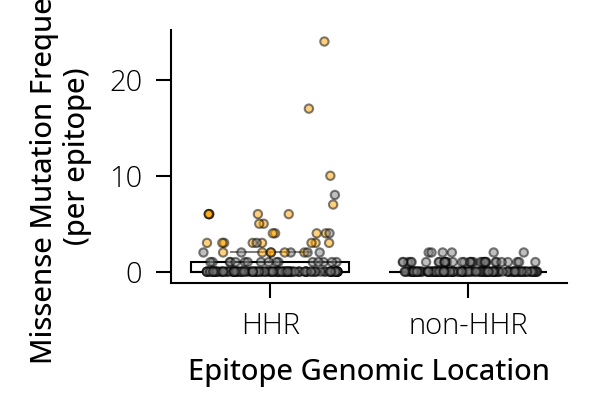

In [758]:
plt.figure(figsize=(2, 1.4))

IN_PEP_DF = LPM_PosEpi_InL2Antigen_V3_DF

sns.stripplot(x="Region_Label", y="N_NSMut_Total", hue = "IsMutBypGCE",
              order = ["HHR", "non-HHR"],  
              jitter = 0.35, palette = ["grey", "orange"],
               data = IN_PEP_DF,
               dodge = False,
               alpha = 0.5, size = 2,
               edgecolor="black", linewidth=0.5,
               legend=False )

sns.boxplot(x="Region_Label", y="N_NSMut_Total",
            order = ["HHR", "non-HHR"],  
            data = IN_PEP_DF,
            legend=False, linewidth = 0.5,
            showcaps=True, fliersize=0, width = 0.8,
            boxprops={'facecolor': 'none', 'edgecolor': 'black', 'alpha': 1},
            whiskerprops={'color': 'black', 'alpha': 0.5},
            capprops={'color': 'black', 'alpha': 0.5},
            medianprops={'color': 'black', 'alpha': 0.8})

plt.xlabel("Epitope Genomic Location")
plt.ylabel("Missense Mutation Frequency\n(per epitope)")

sns.despine()
plt.show()


In [759]:
LPM_PosEpi_InL2Antigen_V3_DF.sort_values("N_NSMut_Total", ascending=False).head(4)

,Epitope_ID,Epitope_Seq,Epitope_Len,RvID,Symbol,AA_Start,AA_End,Chrom,Rv_Start,Rv_End,EpitopeSeqFreqInAntigen,Dataset,Assayed_Panda24,PosEpitope_Panda24,Assayed_Lindestam16,PosEpitope_Lindestam16,PosEpitope_Any,EpitopeSymbol_ID,N_HmRegion,HasHmRegion,Antigen_LVL2,N_NSMut_Total,N_NSMut_mGCE,IsMutBymGCE,N_NSMut_pGCE,IsMutBypGCE,N_mGCEs_WiNS,WiNS_mGC_EventIDs,N_pGCEs_WiNS,WiNS_pGC_EventIDs,Reactivity,Hm_And_Reactivity_Tag,Region_Label
7810,UnqPeptide_7795,LGGLWTAVSPHLSPL,15,Rv3478,PPE60,223,238,NC_000962.3,3895094,3895139,1,Lindestam16_Panda24_Merged,True,False,True,True,True,UnqPeptide_7795-PPE60,1,True,True,24,24,True,24,True,5,"Event_295,Event_291,Event_290,Event_292,Event_293",5,"Event_295,Event_291,Event_290,Event_292,Event_293",Positive,True-Positive,HHR
11318,UnqPeptide_11315,AEHQAIIRDVLTASD,15,Rv1198,esxL,25,40,NC_000962.3,1341080,1341125,1,Lindestam16_Panda24_Merged,True,True,True,True,True,UnqPeptide_11315-esxL,1,True,True,17,11,True,12,True,5,"Event_105,Event_107,Event_108,Event_106,Event_099",6,"Event_105,Event_107,Event_108,Event_106,Event_...",Positive,True-Positive,HHR
16861,UnqPeptide_16863,GAMIRAQAGLLEAEH,15,Rv1198,esxL,13,28,NC_000962.3,1341044,1341089,1,Lindestam16_Panda24_Merged,True,True,False,False,True,UnqPeptide_16863-esxL,1,True,True,10,2,True,5,True,2,"Event_108,Event_102",4,"Event_103,Event_108,Event_100,Event_102",Positive,True-Positive,HHR
12891,UnqPeptide_12877,ARTDLLAFTAFPKQI,15,Rv2512c,Rv2512c,314,329,NC_000962.3,2828816,2828861,1,Lindestam16_Panda24_Merged,True,False,True,True,True,UnqPeptide_12877-Rv2512c,1,True,True,8,0,False,0,False,0,.,0,.,Positive,True-Positive,HHR


In [ ]:
plt.figure(figsize=(4, 2.2))

IN_PEP_DF = LPM_PosEpi_InL2Antigen_WiGCE_DF

sns.stripplot(x="Symbol", y="N_NSMut_Total", hue = "IsMutBypGCE",
              #order = ["HHR", "non-HHR"],  
              jitter = 0.35, palette = ["grey", "orange"],
               data = IN_PEP_DF,
               dodge = False,
               alpha = 0.5, size = 2,
               edgecolor="black", linewidth=0.5,
               legend=False )

sns.boxplot(x="Symbol", y="N_NSMut_Total",
            #order = ["HHR", "non-HHR"],  
            data = IN_PEP_DF,
            legend=False, linewidth = 0.5,
            showcaps=True, fliersize=0, width = 0.8,
            boxprops={'facecolor': 'none', 'edgecolor': 'black', 'alpha': 1},
            whiskerprops={'color': 'black', 'alpha': 0.5},
            capprops={'color': 'black', 'alpha': 0.5},
            medianprops={'color': 'black', 'alpha': 0.8})

plt.xlabel("Gene/Protein")
plt.ylabel("# Missense Mutation Events")

sns.despine()
plt.show()


In [760]:
LPM_PosEpi_InL2Antigen_V3_DF.query("N_mGCEs_WiNS > 0").shape

(27, 33)

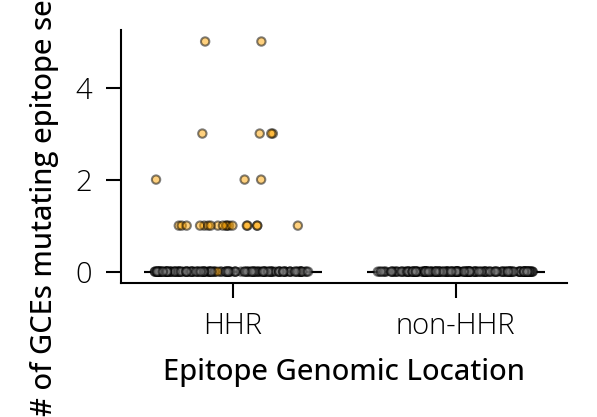

In [761]:
plt.figure(figsize=(2, 1.4))

IN_PEP_DF = LPM_PosEpi_InL2Antigen_V3_DF

sns.stripplot(x="Region_Label", y="N_mGCEs_WiNS", hue = "IsMutBypGCE",
              order = ["HHR", "non-HHR"],  
              jitter = 0.35, palette = ["grey", "orange"],
               data = IN_PEP_DF,
               dodge = False,
               alpha = 0.5, size = 2,
               edgecolor="black", linewidth=0.5,
               legend=False )

sns.boxplot(x="Region_Label", y="N_mGCEs_WiNS",
            order = ["HHR", "non-HHR"],  
            data = IN_PEP_DF,
            legend=False, linewidth = 0.5,
            showcaps=True, fliersize=0, width = 0.8,
            boxprops={'facecolor': 'none', 'edgecolor': 'black', 'alpha': 1},
            whiskerprops={'color': 'black', 'alpha': 0.5},
            capprops={'color': 'black', 'alpha': 0.5},
            medianprops={'color': 'black', 'alpha': 0.8})

plt.xlabel("Epitope Genomic Location")
plt.ylabel("# of GCEs mutating epitope sequence")

sns.despine()
plt.show()


In [762]:
LPM_PosEpi_InL2Antigen_WiGCE_DF = LPM_PosEpi_InL2Antigen_V3_DF.query("N_pGCEs_WiNS > 0")
LPM_PosEpi_InL2Antigen_WiGCE_DF.shape

(29, 33)

In [763]:
LPM_PosEpi_InL2Antigen_WiGCE_DF["Symbol"].value_counts()

Symbol
PPE18    16
PPE19     5
esxL      3
esxO      2
esxK      1
PPE60     1
esxP      1
Name: count, dtype: int64

In [764]:
LPM_PosEpi_InL2Antigen_WiGCE_DF.sort_values("N_pGCEs_WiNS", ascending = False)

,Epitope_ID,Epitope_Seq,Epitope_Len,RvID,Symbol,AA_Start,AA_End,Chrom,Rv_Start,Rv_End,EpitopeSeqFreqInAntigen,Dataset,Assayed_Panda24,PosEpitope_Panda24,Assayed_Lindestam16,PosEpitope_Lindestam16,PosEpitope_Any,EpitopeSymbol_ID,N_HmRegion,HasHmRegion,Antigen_LVL2,N_NSMut_Total,N_NSMut_mGCE,IsMutBymGCE,N_NSMut_pGCE,IsMutBypGCE,N_mGCEs_WiNS,WiNS_mGC_EventIDs,N_pGCEs_WiNS,WiNS_pGC_EventIDs,Reactivity,Hm_And_Reactivity_Tag,Region_Label
11318,UnqPeptide_11315,AEHQAIIRDVLTASD,15,Rv1198,esxL,25,40,NC_000962.3,1341080,1341125,1,Lindestam16_Panda24_Merged,True,True,True,True,True,UnqPeptide_11315-esxL,1,True,True,17,11,True,12,True,5,"Event_105,Event_107,Event_108,Event_106,Event_099",6,"Event_105,Event_107,Event_108,Event_106,Event_...",Positive,True-Positive,HHR
7810,UnqPeptide_7795,LGGLWTAVSPHLSPL,15,Rv3478,PPE60,223,238,NC_000962.3,3895094,3895139,1,Lindestam16_Panda24_Merged,True,False,True,True,True,UnqPeptide_7795-PPE60,1,True,True,24,24,True,24,True,5,"Event_295,Event_291,Event_290,Event_292,Event_293",5,"Event_295,Event_291,Event_290,Event_292,Event_293",Positive,True-Positive,HHR
16861,UnqPeptide_16863,GAMIRAQAGLLEAEH,15,Rv1198,esxL,13,28,NC_000962.3,1341044,1341089,1,Lindestam16_Panda24_Merged,True,True,False,False,True,UnqPeptide_16863-esxL,1,True,True,10,2,True,5,True,2,"Event_108,Event_102",4,"Event_103,Event_108,Event_100,Event_102",Positive,True-Positive,HHR
1146,UnqPeptide_1141,GSASLVAAAQMWDSV,15,Rv1196,PPE18,20,35,NC_000962.3,1339408,1339453,1,Lindestam16_Panda24_Merged,True,True,True,True,True,UnqPeptide_1141-PPE18,1,True,True,5,3,True,3,True,3,"Event_092,Event_093,Event_091",3,"Event_092,Event_093,Event_091",Positive,True-Positive,HHR
12312,UnqPeptide_12306,QFGDVDAHGAMIRAQ,15,Rv2346c,esxO,5,20,NC_000962.3,2626112,2626157,1,Lindestam16_Panda24_Merged,True,False,True,True,True,UnqPeptide_12306-esxO,1,True,True,3,3,True,3,True,3,"Event_208,Event_211,Event_209",3,"Event_208,Event_211,Event_209",Positive,True-Positive,HHR
9778,UnqPeptide_9768,MTINYQFGDVDAHGA,15,Rv2346c,esxO,0,15,NC_000962.3,2626127,2626172,1,Lindestam16_Panda24_Merged,True,False,True,True,True,UnqPeptide_9768-esxO,1,True,True,3,3,True,3,True,3,"Event_208,Event_211,Event_209",3,"Event_208,Event_211,Event_209",Positive,True-Positive,HHR
16787,UnqPeptide_16789,VAAAQMWDSVASDLF,15,Rv1196,PPE18,25,40,NC_000962.3,1339423,1339468,1,Lindestam16_Panda24_Merged,True,False,True,True,True,UnqPeptide_16789-PPE18,1,True,True,5,3,True,3,True,3,"Event_092,Event_093,Event_091",3,"Event_092,Event_093,Event_091",Positive,True-Positive,HHR
16960,UnqPeptide_16960,AAVEEASDTAAANQL,15,Rv1196,PPE18,185,200,NC_000962.3,1339903,1339948,1,Lindestam16_Panda24_Merged,True,False,True,True,True,UnqPeptide_16960-PPE18,1,True,True,3,2,True,2,True,2,"Event_096,Event_095",2,"Event_096,Event_095",Positive,True-Positive,HHR
1002,UnqPeptide_998,LLEQAAAVEEASDTA,15,Rv1196,PPE18,180,195,NC_000962.3,1339888,1339933,1,Lindestam16_Panda24_Merged,True,False,True,True,True,UnqPeptide_998-PPE18,1,True,True,3,2,True,2,True,2,"Event_096,Event_095",2,"Event_096,Event_095",Positive,True-Positive,HHR
4248,UnqPeptide_4240,SPYVAWMSVTAGQAE,15,Rv1361c,PPE19,70,85,NC_000962.3,1533378,1533423,1,Lindestam16_Panda24_Merged,True,False,True,True,True,UnqPeptide_4240-PPE19,1,True,True,3,1,True,1,True,1,Event_114,1,Event_114,Positive,True-Positive,HHR


/tmp/ipykernel_113237/2716126363.py:5: UserWarning: The palette list has more values (2) than needed (1), which may not be intended.
  sns.stripplot(x="Symbol", y="N_mGCEs_WiNS", hue = "IsMutBypGCE",


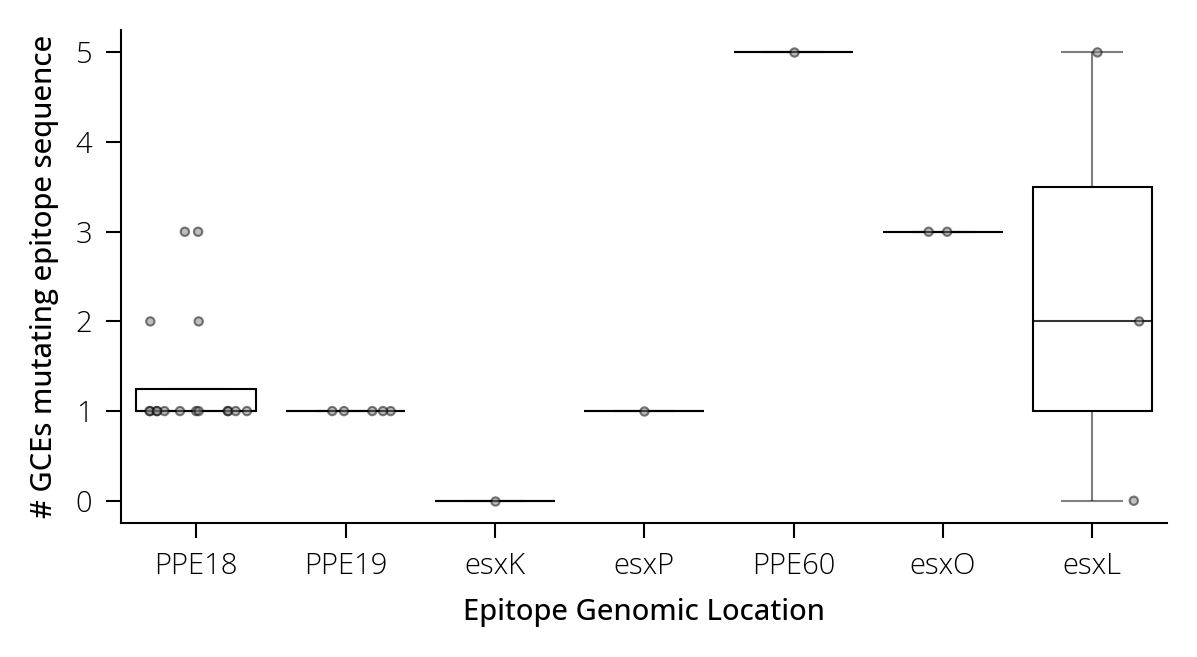

In [765]:
plt.figure(figsize=(4, 2.2))

IN_PEP_DF = LPM_PosEpi_InL2Antigen_WiGCE_DF

sns.stripplot(x="Symbol", y="N_mGCEs_WiNS", hue = "IsMutBypGCE",
              #order = ["HHR", "non-HHR"],  
              jitter = 0.35, palette = ["grey", "orange"],
               data = IN_PEP_DF,
               dodge = False,
               alpha = 0.5, size = 2,
               edgecolor="black", linewidth=0.5,
               legend=False )

sns.boxplot(x="Symbol", y="N_mGCEs_WiNS",
            #order = ["HHR", "non-HHR"],  
            data = IN_PEP_DF,
            legend=False, linewidth = 0.5,
            showcaps=True, fliersize=0, width = 0.8,
            boxprops={'facecolor': 'none', 'edgecolor': 'black', 'alpha': 1},
            whiskerprops={'color': 'black', 'alpha': 0.5},
            capprops={'color': 'black', 'alpha': 0.5},
            medianprops={'color': 'black', 'alpha': 0.8})

plt.xlabel("Epitope Genomic Location")
plt.ylabel("# GCEs mutating epitope sequence")

sns.despine()
plt.show()


# Part X

In [933]:
LPM_PosEpi_InL2Antigen_WiGCE_DF.shape

(29, 33)

In [934]:
LPM_PosEpi_InL2Antigen_WiGCE_DF.head()

,Epitope_ID,Epitope_Seq,Epitope_Len,RvID,Symbol,AA_Start,AA_End,Chrom,Rv_Start,Rv_End,EpitopeSeqFreqInAntigen,Dataset,Assayed_Panda24,PosEpitope_Panda24,Assayed_Lindestam16,PosEpitope_Lindestam16,PosEpitope_Any,EpitopeSymbol_ID,N_HmRegion,HasHmRegion,Antigen_LVL2,N_NSMut_Total,N_NSMut_mGCE,IsMutBymGCE,N_NSMut_pGCE,IsMutBypGCE,N_mGCEs_WiNS,WiNS_mGC_EventIDs,N_pGCEs_WiNS,WiNS_pGC_EventIDs,Reactivity,Hm_And_Reactivity_Tag,Region_Label
963,UnqPeptide_959,RSPISNMVSMANNHM,15,Rv1196,PPE18,234,249,NC_000962.3,1340050,1340095,1,Lindestam16_Panda24_Merged,True,False,True,True,True,UnqPeptide_959-PPE18,1,True,True,2,1,True,1,True,1,Event_096,1,Event_096,Positive,True-Positive,HHR
1002,UnqPeptide_998,LLEQAAAVEEASDTA,15,Rv1196,PPE18,180,195,NC_000962.3,1339888,1339933,1,Lindestam16_Panda24_Merged,True,False,True,True,True,UnqPeptide_998-PPE18,1,True,True,3,2,True,2,True,2,"Event_096,Event_095",2,"Event_096,Event_095",Positive,True-Positive,HHR
1146,UnqPeptide_1141,GSASLVAAAQMWDSV,15,Rv1196,PPE18,20,35,NC_000962.3,1339408,1339453,1,Lindestam16_Panda24_Merged,True,True,True,True,True,UnqPeptide_1141-PPE18,1,True,True,5,3,True,3,True,3,"Event_092,Event_093,Event_091",3,"Event_092,Event_093,Event_091",Positive,True-Positive,HHR
1817,UnqPeptide_1812,LLGQNTPAIAVNEAE,15,Rv1196,PPE18,125,140,NC_000962.3,1339723,1339768,1,Lindestam16_Panda24_Merged,True,False,True,True,True,UnqPeptide_1812-PPE18,1,True,True,4,4,True,4,True,1,Event_094,1,Event_094,Positive,True-Positive,HHR
4248,UnqPeptide_4240,SPYVAWMSVTAGQAE,15,Rv1361c,PPE19,70,85,NC_000962.3,1533378,1533423,1,Lindestam16_Panda24_Merged,True,False,True,True,True,UnqPeptide_4240-PPE19,1,True,True,3,1,True,1,True,1,Event_114,1,Event_114,Positive,True-Positive,HHR


In [935]:
LPM_PosEpi_InPPE18_WiGCE_DF = LPM_PosEpi_InL2Antigen_WiGCE_DF.query("Symbol == 'PPE18'")
LPM_PosEpi_InPPE18_WiGCE_DF.shape

(16, 33)

In [936]:
LPM_PosEpi_InPPE18_WiGCE_DF.head(1)

,Epitope_ID,Epitope_Seq,Epitope_Len,RvID,Symbol,AA_Start,AA_End,Chrom,Rv_Start,Rv_End,EpitopeSeqFreqInAntigen,Dataset,Assayed_Panda24,PosEpitope_Panda24,Assayed_Lindestam16,PosEpitope_Lindestam16,PosEpitope_Any,EpitopeSymbol_ID,N_HmRegion,HasHmRegion,Antigen_LVL2,N_NSMut_Total,N_NSMut_mGCE,IsMutBymGCE,N_NSMut_pGCE,IsMutBypGCE,N_mGCEs_WiNS,WiNS_mGC_EventIDs,N_pGCEs_WiNS,WiNS_pGC_EventIDs,Reactivity,Hm_And_Reactivity_Tag,Region_Label
963,UnqPeptide_959,RSPISNMVSMANNHM,15,Rv1196,PPE18,234,249,NC_000962.3,1340050,1340095,1,Lindestam16_Panda24_Merged,True,False,True,True,True,UnqPeptide_959-PPE18,1,True,True,2,1,True,1,True,1,Event_096,1,Event_096,Positive,True-Positive,HHR


In [937]:
LPM_PosEpi_InPPE18_WiGCE_DF.query("Assayed_Lindestam16 == True").shape

(16, 33)

# Investigate specific epitope mutations

#### Pull out PPE18 (Rv1196) protein sequence

In [905]:
PPE18_AA_Seq = dictOf_H37Rv_MycoBrow_ProtSeq["Rv1196"]
len(PPE18_AA_Seq)


391

In [906]:
PPE60_AA_Seq = dictOf_H37Rv_MycoBrow_ProtSeq["Rv3478"]
len(PPE60_AA_Seq)


393

In [907]:
esxL_AA_Seq = dictOf_H37Rv_MycoBrow_ProtSeq["Rv1198"]
len(esxL_AA_Seq)


94

In [874]:
LPM_PosEpi_InL2Antigen_WiGCE_DF.sort_values("N_pGCEs_WiNS", ascending = False).head(9)

,Epitope_ID,Epitope_Seq,Epitope_Len,RvID,Symbol,AA_Start,AA_End,Chrom,Rv_Start,Rv_End,EpitopeSeqFreqInAntigen,Dataset,Assayed_Panda24,PosEpitope_Panda24,Assayed_Lindestam16,PosEpitope_Lindestam16,PosEpitope_Any,EpitopeSymbol_ID,N_HmRegion,HasHmRegion,Antigen_LVL2,N_NSMut_Total,N_NSMut_mGCE,IsMutBymGCE,N_NSMut_pGCE,IsMutBypGCE,N_mGCEs_WiNS,WiNS_mGC_EventIDs,N_pGCEs_WiNS,WiNS_pGC_EventIDs,Reactivity,Hm_And_Reactivity_Tag,Region_Label
11318,UnqPeptide_11315,AEHQAIIRDVLTASD,15,Rv1198,esxL,25,40,NC_000962.3,1341080,1341125,1,Lindestam16_Panda24_Merged,True,True,True,True,True,UnqPeptide_11315-esxL,1,True,True,17,11,True,12,True,5,"Event_105,Event_107,Event_108,Event_106,Event_099",6,"Event_105,Event_107,Event_108,Event_106,Event_...",Positive,True-Positive,HHR
7810,UnqPeptide_7795,LGGLWTAVSPHLSPL,15,Rv3478,PPE60,223,238,NC_000962.3,3895094,3895139,1,Lindestam16_Panda24_Merged,True,False,True,True,True,UnqPeptide_7795-PPE60,1,True,True,24,24,True,24,True,5,"Event_295,Event_291,Event_290,Event_292,Event_293",5,"Event_295,Event_291,Event_290,Event_292,Event_293",Positive,True-Positive,HHR
16861,UnqPeptide_16863,GAMIRAQAGLLEAEH,15,Rv1198,esxL,13,28,NC_000962.3,1341044,1341089,1,Lindestam16_Panda24_Merged,True,True,False,False,True,UnqPeptide_16863-esxL,1,True,True,10,2,True,5,True,2,"Event_108,Event_102",4,"Event_103,Event_108,Event_100,Event_102",Positive,True-Positive,HHR
1146,UnqPeptide_1141,GSASLVAAAQMWDSV,15,Rv1196,PPE18,20,35,NC_000962.3,1339408,1339453,1,Lindestam16_Panda24_Merged,True,True,True,True,True,UnqPeptide_1141-PPE18,1,True,True,5,3,True,3,True,3,"Event_092,Event_093,Event_091",3,"Event_092,Event_093,Event_091",Positive,True-Positive,HHR
12312,UnqPeptide_12306,QFGDVDAHGAMIRAQ,15,Rv2346c,esxO,5,20,NC_000962.3,2626112,2626157,1,Lindestam16_Panda24_Merged,True,False,True,True,True,UnqPeptide_12306-esxO,1,True,True,3,3,True,3,True,3,"Event_208,Event_211,Event_209",3,"Event_208,Event_211,Event_209",Positive,True-Positive,HHR
9778,UnqPeptide_9768,MTINYQFGDVDAHGA,15,Rv2346c,esxO,0,15,NC_000962.3,2626127,2626172,1,Lindestam16_Panda24_Merged,True,False,True,True,True,UnqPeptide_9768-esxO,1,True,True,3,3,True,3,True,3,"Event_208,Event_211,Event_209",3,"Event_208,Event_211,Event_209",Positive,True-Positive,HHR
16787,UnqPeptide_16789,VAAAQMWDSVASDLF,15,Rv1196,PPE18,25,40,NC_000962.3,1339423,1339468,1,Lindestam16_Panda24_Merged,True,False,True,True,True,UnqPeptide_16789-PPE18,1,True,True,5,3,True,3,True,3,"Event_092,Event_093,Event_091",3,"Event_092,Event_093,Event_091",Positive,True-Positive,HHR
16960,UnqPeptide_16960,AAVEEASDTAAANQL,15,Rv1196,PPE18,185,200,NC_000962.3,1339903,1339948,1,Lindestam16_Panda24_Merged,True,False,True,True,True,UnqPeptide_16960-PPE18,1,True,True,3,2,True,2,True,2,"Event_096,Event_095",2,"Event_096,Event_095",Positive,True-Positive,HHR
1002,UnqPeptide_998,LLEQAAAVEEASDTA,15,Rv1196,PPE18,180,195,NC_000962.3,1339888,1339933,1,Lindestam16_Panda24_Merged,True,False,True,True,True,UnqPeptide_998-PPE18,1,True,True,3,2,True,2,True,2,"Event_096,Event_095",2,"Event_096,Event_095",Positive,True-Positive,HHR


### Look @ PPE18 epitope `GSASLVAAAQMWDSV`

#### PREDICTED TO BE RESTRICTED By the following alleles:
`HLA-DPB1*01:01`, <br>
`HLA-DRB5*01:01`, <br>
`HLA-DRB1*15:01` <br>

In [875]:
Lind16_IEDB_AllPeptides_HLAInfo_DF.query("Epitope_Seq == 'GSASLVAAAQMWDSV' ")

,Epitope_Seq,Epitope_Status,HLA_Allele,Num_Assayed,Num_Positive,Fraction_PositiveAssay,Gene(s)
79,GSASLVAAAQMWDSV,Positive,HLA-DPB1*01:01,1,1,1.0,PPE18
80,GSASLVAAAQMWDSV,Positive,HLA-DRB5*01:01,1,1,1.0,PPE18
81,GSASLVAAAQMWDSV,Positive,HLA-DRB1*15:01,1,1,1.0,PPE18


In [876]:
i_SingleEpitope_DF = LPM_PosEpi_V2_DF.query(f"Epitope_Seq == 'GSASLVAAAQMWDSV' & Symbol == 'PPE18' ")

i_Rv_Start_Epi = i_SingleEpitope_DF["Rv_Start"].values[0]
i_Rv_End_Epi = i_SingleEpitope_DF["Rv_End"].values[0]

print(i_Rv_Start_Epi, i_Rv_End_Epi)

bf.select(pGCE_DF, f"NC_000962.3:{i_Rv_Start_Epi}-{i_Rv_End_Epi}",
          cols = RE_CoordCols ) 

1339408 1339453


,seqname,start_1based,end_1based,score,strand,Parent_Node,Child_Node,neg_log_likelihood,snp_count,taxa_List,start_0based,CenterOfRegion,EventLen,Lineage,Overlap_Genes,Overlap_Gene_RvIDs,Contains_Esx,Contains_PEPPE,Contains_REP13E12,NoOverlap_Wi_PEPPE_Esx_13E12_Genes,EventID,N_HmMapAln_PR_Ovrlap,OvrlapWi_HmMapAln_PR,N_HmMapAln_LR_Ovrlap,OvrlapWi_HmMapAln_LR,Overlap_HHRs,N_LCR_Ovrlap,OvrlapWi_LowComplexityRegion,N_LowPmap_Ovrlap,OvrlapWi_LowPmap,LenOfTaxaList,IsTermNode,Freq_SNP_FoundInAnyPR,NumHmTargets,NumHm_AtMaxKmerMatch,Top_KmerMatch_HomologTarIDs,Top_KmerMatch_HomologGeneIDs,Max_KmerMatch_ToHm,DistToHm_TopKmatch,TotalKmers_Eval,NumHm_AtMaxSNPMatch,Top_SNPMatch_HomologTarIDs,Top_SNPMatch_HomologGeneIDs,Max_SNPMatch_ToHm,DistToHm_TopSNPmatch,Overlap_WiAntigenLVL2Gene,N_NS_Mut,N_EpiMutated_By_GCE,N_NegPepMutated_By_GCE,EpitopeIDs_NSMutByEvent
90,NC_000962.3,1339399,1339436,0.0,.,Node_36,Node_28,655.459143,4,"['M0016395_7', 'R15311']",1339398,1339417.0,38,lineage4,PPE18,Rv1196,False,True,False,False,Event_091,2,1,0,0,PR_HmRegion_053,0,0,1,1,2,False,0.75,2,2,"PE31,PPE60-H37Rv-3894016-3895519-PPE19-H37Rv-1...","PE31,PPE60-PPE19",0.5769,NaN,26,1,"PE31,PPE60-H37Rv-3894016-3895519","PE31,PPE60",0.75,1856181.5,True,1,2,1,"UnqPeptide_1141-PPE18,UnqPeptide_16789-PPE18"
91,NC_000962.3,1339432,1339516,0.0,.,Node_114,TB3368,475.291405,6,['TB3368'],1339431,1339473.5,85,lineage2,PPE18,Rv1196,False,True,False,False,Event_092,2,1,0,0,PR_HmRegion_053,0,0,1,1,1,True,1.00,2,1,PPE19-H37Rv-1532539-1533632,PPE19,1.0000,193612.0,31,1,"PE31,PPE60-H37Rv-3894016-3895519","PE31,PPE60",0.50,1856238.0,True,3,2,4,"UnqPeptide_1141-PPE18,UnqPeptide_16789-PPE18"
92,NC_000962.3,1339432,1339774,0.0,.,Node_27,Node_5,1536.817046,5,"['mada_2-31', 'mada_1-41']",1339431,1339602.5,343,lineage4,PPE18,Rv1196,False,True,False,False,Event_093,2,1,0,0,PR_HmRegion_053,0,0,1,1,2,False,1.00,2,2,"PE31,PPE60-H37Rv-3894016-3895519-PPE19-H37Rv-1...","PE31,PPE60-PPE19",0.7027,NaN,37,1,"PE31,PPE60-H37Rv-3894016-3895519","PE31,PPE60",0.80,1856367.0,True,1,2,1,"UnqPeptide_1141-PPE18,UnqPeptide_16789-PPE18"


In [877]:
i_SingleEpitope_DF

,Epitope_ID,Epitope_Seq,Epitope_Len,RvID,Symbol,AA_Start,AA_End,Chrom,Rv_Start,Rv_End,EpitopeSeqFreqInAntigen,Dataset,Assayed_Panda24,PosEpitope_Panda24,Assayed_Lindestam16,PosEpitope_Lindestam16,PosEpitope_Any,EpitopeSymbol_ID,N_HmRegion,HasHmRegion,Antigen_LVL2,N_NSMut_Total,N_NSMut_mGCE,IsMutBymGCE,N_NSMut_pGCE,IsMutBypGCE,N_mGCEs_WiNS,WiNS_mGC_EventIDs,N_pGCEs_WiNS,WiNS_pGC_EventIDs,Reactivity
1146,UnqPeptide_1141,GSASLVAAAQMWDSV,15,Rv1196,PPE18,20,35,NC_000962.3,1339408,1339453,1,Lindestam16_Panda24_Merged,True,True,True,True,True,UnqPeptide_1141-PPE18,1,True,True,5,3,True,3,True,3,"Event_092,Event_093,Event_091",3,"Event_092,Event_093,Event_091",Positive


In [878]:
Gub_All_SNPs_CDS_Effect_DF.query( f"Pos_1based >= {i_Rv_Start_Epi} & Pos_1based <= {i_Rv_End_Epi}")["Child_Node"].nunique()   

5

In [879]:
Gub_All_SNPs_CDS_Effect_DF.query( f"Pos_1based >= {i_Rv_Start_Epi} & Pos_1based <= {i_Rv_End_Epi}")["EventID"].nunique()   

3

In [880]:
Gub_All_SNPs_CDS_Effect_DF.query( f"Pos_1based >= {i_Rv_Start_Epi} & Pos_1based <= {i_Rv_End_Epi}") #.sort_values("Pos_1based")

,Pos_1based,Parent_Node,Child_Node,Parent_Call,Child_Call,EventID,Pos_0based,Chrom,NumHmOvrlap,HmOvrlap,RegionType,N_OverlapGenes,Symbol,Strand,Gene_Pos_0,Codon,Codon_Pos,Ref_AA,Mut_AA,Start,End,Lineage,N_Epitopes_Overlap
959,1339432,Node_114,TB3368,G,C,Event_092,1339431,NC_000962.3,2,1,PR,1,PPE18,+,83.0,28.0,3.0,NaN,NaN,1339431,1339432,lineage2,2
960,1339435,Node_114,TB3368,T,G,Event_092,1339434,NC_000962.3,2,1,PR,1,PPE18,+,86.0,29.0,3.0,NaN,NaN,1339434,1339435,lineage2,2
961,1339436,Node_114,TB3368,C,A,Event_092,1339435,NC_000962.3,2,1,PR,1,PPE18,+,87.0,30.0,1.0,Q,K,1339435,1339436,lineage2,2
4922,1339436,Node_136,mada_2-46,C,A,NaN,1339435,NC_000962.3,2,1,PR,1,PPE18,+,87.0,30.0,1.0,Q,K,1339435,1339436,lineage1,2
7310,1339444,Node_146,N0153,G,C,NaN,1339443,NC_000962.3,2,1,PR,1,PPE18,+,95.0,32.0,3.0,W,C,1339443,1339444,lineage1,2
13296,1339432,Node_27,Node_5,G,C,Event_093,1339431,NC_000962.3,2,1,PR,1,PPE18,+,83.0,28.0,3.0,NaN,NaN,1339431,1339432,lineage4,2
13297,1339435,Node_27,Node_5,T,G,Event_093,1339434,NC_000962.3,2,1,PR,1,PPE18,+,86.0,29.0,3.0,NaN,NaN,1339434,1339435,lineage4,2
13298,1339436,Node_27,Node_5,C,A,Event_093,1339435,NC_000962.3,2,1,PR,1,PPE18,+,87.0,30.0,1.0,Q,K,1339435,1339436,lineage4,2
15395,1339432,Node_36,Node_28,G,C,Event_091,1339431,NC_000962.3,2,1,PR,1,PPE18,+,83.0,28.0,3.0,NaN,NaN,1339431,1339432,lineage4,2
15396,1339435,Node_36,Node_28,T,G,Event_091,1339434,NC_000962.3,2,1,PR,1,PPE18,+,86.0,29.0,3.0,NaN,NaN,1339434,1339435,lineage4,2


In [896]:
Epi2_Seq = PPE18_AA_Seq[20:35]
print(len(Epi2_Seq))
print(Epi2_Seq)

15
GSASLVAAAQMWDSV


In [897]:
Epi2_Seq[30 - 21]

'Q'

In [904]:
Epi2_Seq_WiMut_E092 = list(Epi2_Seq)
Epi2_Seq_WiMut_E092[30 - 21] = 'K' # Codon pos 30 Q to K

# Epi2_Seq_WiMut_E092[136 - 21] = 'A' # Codon pos 136 V to A

# Epi2_Seq_WiMut_E092[138 - 21] = 'Q' # Codon pos 138 E to Q
# Epi2_Seq_WiMut_E092[140 - 21] = 'A' # Codon pos 140 E to A
# Epi2_Seq_WiMut_E092[142 - 21] = 'S' # Codon pos 142 G to S
# Epi2_Seq_WiMut_E092[143 - 131] = 'Q' # Codon pos 143 E to Q

Epi2_Seq_WiMut_E092 = "".join(Epi2_Seq_WiMut_E092)
print(Epi2_Seq) 
print(Epi2_Seq_WiMut_E092)

GSASLVAAAQMWDSV
GSASLVAAAKMWDSV


In [903]:
Epi2_Seq_WiMut_E093 = list(Epi2_Seq)
Epi2_Seq_WiMut_E093[30 - 21] = 'K' # Codon pos 30 Q to K


Epi2_Seq_WiMut_E093 = "".join(Epi2_Seq_WiMut_E093)
print(Epi2_Seq) 
print(Epi2_Seq_WiMut_E093)

GSASLVAAAQMWDSV
GSASLVAAAKMWDSV


```
>H37Rv_PPE18_Epitope_AA20to35
GSASLVAAAQMWDSV
>Event092_PPE18_Epitope_AA20to35
GSASLVAAAKMWDSV
```

### Look @ PPE60 epitope `LGGLWTAVSPHLSPL`

#### PREDICTED TO BE RESTRICTED By the following alleles:
`HLA-DQB1*06:02`,
`HLA-DQB1*05:01`,
`HLA-DRB5*01:01`

In [911]:
Lind16_IEDB_AllPeptides_HLAInfo_DF.query("Epitope_Seq == 'LGGLWTAVSPHLSPL' ")

,Epitope_Seq,Epitope_Status,HLA_Allele,Num_Assayed,Num_Positive,Fraction_PositiveAssay,Gene(s)
416,LGGLWTAVSPHLSPL,Positive,NaN,63,2,0.031746,PPE60


In [912]:
i_SingleEpitope_DF = LPM_PosEpi_V2_DF.query(f"Epitope_Seq == 'LGGLWTAVSPHLSPL' & Symbol == 'PPE60' ")

i_Rv_Start_Epi = i_SingleEpitope_DF["Rv_Start"].values[0]
i_Rv_End_Epi = i_SingleEpitope_DF["Rv_End"].values[0]

print(i_Rv_Start_Epi, i_Rv_End_Epi)

bf.select(pGCE_DF, f"NC_000962.3:{i_Rv_Start_Epi}-{i_Rv_End_Epi}",
          cols = RE_CoordCols ) 

3895094 3895139


,seqname,start_1based,end_1based,score,strand,Parent_Node,Child_Node,neg_log_likelihood,snp_count,taxa_List,start_0based,CenterOfRegion,EventLen,Lineage,Overlap_Genes,Overlap_Gene_RvIDs,Contains_Esx,Contains_PEPPE,Contains_REP13E12,NoOverlap_Wi_PEPPE_Esx_13E12_Genes,EventID,N_HmMapAln_PR_Ovrlap,OvrlapWi_HmMapAln_PR,N_HmMapAln_LR_Ovrlap,OvrlapWi_HmMapAln_LR,Overlap_HHRs,N_LCR_Ovrlap,OvrlapWi_LowComplexityRegion,N_LowPmap_Ovrlap,OvrlapWi_LowPmap,LenOfTaxaList,IsTermNode,Freq_SNP_FoundInAnyPR,NumHmTargets,NumHm_AtMaxKmerMatch,Top_KmerMatch_HomologTarIDs,Top_KmerMatch_HomologGeneIDs,Max_KmerMatch_ToHm,DistToHm_TopKmatch,TotalKmers_Eval,NumHm_AtMaxSNPMatch,Top_SNPMatch_HomologTarIDs,Top_SNPMatch_HomologGeneIDs,Max_SNPMatch_ToHm,DistToHm_TopSNPmatch,Overlap_WiAntigenLVL2Gene,N_NS_Mut,N_EpiMutated_By_GCE,N_NegPepMutated_By_GCE,EpitopeIDs_NSMutByEvent
289,NC_000962.3,3894588,3895342,0.0,.,Node_48,TB3054,1246.216765,27,['TB3054'],3894587,3894964.5,755,lineage4,PPE60,Rv3478,False,True,False,False,Event_290,2,1,0,0,PR_HmRegion_182,0,0,4,1,1,True,0.888889,2,1,"PE13,PPE18-H37Rv-1338923-1340433","PE13,PPE18",0.8882,1856245.5,161,1,"PE13,PPE18-H37Rv-1338923-1340433","PE13,PPE18",0.7778,1856245.5,True,23,1,5,UnqPeptide_7795-PPE60
290,NC_000962.3,3895055,3895116,0.0,.,Node_41,Node_39,711.840017,20,"['mada_103', 'mada_112', 'mada_124']",3895054,3895085.0,62,lineage4,PPE60,Rv3478,False,True,False,False,Event_291,2,1,0,0,PR_HmRegion_182,0,0,2,1,3,False,1.000000,2,1,PPE19-H37Rv-1532461-1533653,PPE19,0.7042,2049504.0,71,1,"PE13,PPE18-H37Rv-1338923-1340433","PE13,PPE18",0.2000,1856125.0,True,15,1,0,UnqPeptide_7795-PPE60
291,NC_000962.3,3895055,3895116,0.0,.,Node_50,mada_1-50,235.832795,20,['mada_1-50'],3895054,3895085.0,62,lineage4,PPE60,Rv3478,False,True,False,False,Event_292,2,1,0,0,PR_HmRegion_182,0,0,2,1,1,True,1.000000,2,1,PPE19-H37Rv-1532461-1533653,PPE19,0.7042,2049504.0,71,1,"PE13,PPE18-H37Rv-1338923-1340433","PE13,PPE18",0.2000,1856125.0,True,15,1,0,UnqPeptide_7795-PPE60
292,NC_000962.3,3895055,3895185,0.0,.,Node_9,mada_105,631.945972,33,['mada_105'],3895054,3895119.5,131,lineage4,PPE60,Rv3478,False,True,False,False,Event_293,2,1,0,0,PR_HmRegion_182,0,0,3,1,1,True,0.878788,2,1,PPE19-H37Rv-1532461-1533653,PPE19,0.8190,2049469.5,116,1,"PE13,PPE18-H37Rv-1338923-1340433","PE13,PPE18",0.3636,1856090.5,True,28,1,0,UnqPeptide_7795-PPE60
294,NC_000962.3,3895067,3895257,0.0,.,Node_31,Node_30,412.863731,25,"['TB3162', 'TB2661', 'TB3386']",3895066,3895161.5,191,lineage4,PPE60,Rv3478,False,True,False,False,Event_295,2,1,0,0,PR_HmRegion_182,0,0,3,1,3,False,0.880000,2,1,"PE13,PPE18-H37Rv-1338923-1340433","PE13,PPE18",0.9565,1856048.5,115,1,"PE13,PPE18-H37Rv-1338923-1340433","PE13,PPE18",0.8800,1856048.5,True,22,1,1,UnqPeptide_7795-PPE60


In [913]:
i_SingleEpitope_DF

,Epitope_ID,Epitope_Seq,Epitope_Len,RvID,Symbol,AA_Start,AA_End,Chrom,Rv_Start,Rv_End,EpitopeSeqFreqInAntigen,Dataset,Assayed_Panda24,PosEpitope_Panda24,Assayed_Lindestam16,PosEpitope_Lindestam16,PosEpitope_Any,EpitopeSymbol_ID,N_HmRegion,HasHmRegion,Antigen_LVL2,N_NSMut_Total,N_NSMut_mGCE,IsMutBymGCE,N_NSMut_pGCE,IsMutBypGCE,N_mGCEs_WiNS,WiNS_mGC_EventIDs,N_pGCEs_WiNS,WiNS_pGC_EventIDs,Reactivity
7810,UnqPeptide_7795,LGGLWTAVSPHLSPL,15,Rv3478,PPE60,223,238,NC_000962.3,3895094,3895139,1,Lindestam16_Panda24_Merged,True,False,True,True,True,UnqPeptide_7795-PPE60,1,True,True,24,24,True,24,True,5,"Event_295,Event_291,Event_290,Event_292,Event_293",5,"Event_295,Event_291,Event_290,Event_292,Event_293",Positive


In [914]:
Gub_All_SNPs_CDS_Effect_DF.query( f"Pos_1based >= {i_Rv_Start_Epi} & Pos_1based <= {i_Rv_End_Epi}")["Child_Node"].nunique()   

5

In [915]:
Gub_All_SNPs_CDS_Effect_DF.query( f"Pos_1based >= {i_Rv_Start_Epi} & Pos_1based <= {i_Rv_End_Epi}")["EventID"].nunique()   

5

In [916]:
#Gub_All_SNPs_CDS_Effect_DF.query( f"Pos_1based >= {i_Rv_Start_Epi} & Pos_1based <= {i_Rv_End_Epi}") #.sort_values("Pos_1based")

In [917]:
Gub_All_SNPs_CDS_Effect_DF.query( f"Pos_1based >= {i_Rv_Start_Epi} & Pos_1based <= {i_Rv_End_Epi} & EventID == 'Event_295' ") #.sort_values("Pos_1based")

,Pos_1based,Parent_Node,Child_Node,Parent_Call,Child_Call,EventID,Pos_0based,Chrom,NumHmOvrlap,HmOvrlap,RegionType,N_OverlapGenes,Symbol,Strand,Gene_Pos_0,Codon,Codon_Pos,Ref_AA,Mut_AA,Start,End,Lineage,N_Epitopes_Overlap
14839,3895103,Node_31,Node_30,G,C,Event_295,3895102,NC_000962.3,2,1,PR,1,PPE60,+,677.0,226.0,3.0,NaN,NaN,3895102,3895103,lineage4,1
14840,3895111,Node_31,Node_30,C,A,Event_295,3895110,NC_000962.3,2,1,PR,1,PPE60,+,685.0,229.0,2.0,T,K,3895110,3895111,lineage4,1
14841,3895113,Node_31,Node_30,G,A,Event_295,3895112,NC_000962.3,2,1,PR,1,PPE60,+,687.0,230.0,1.0,A,T,3895112,3895113,lineage4,1
14842,3895129,Node_31,Node_30,T,G,Event_295,3895128,NC_000962.3,2,1,PR,1,PPE60,+,703.0,235.0,2.0,L,R,3895128,3895129,lineage4,1
14843,3895137,Node_31,Node_30,C,A,Event_295,3895136,NC_000962.3,2,1,PR,1,PPE60,+,711.0,238.0,1.0,L,I,3895136,3895137,lineage4,1


In [918]:
Gub_All_SNPs_CDS_Effect_DF.query( f"Pos_1based >= {i_Rv_Start_Epi} & Pos_1based <= {i_Rv_End_Epi} & EventID == 'Event_293' ") #.sort_values("Pos_1based")

,Pos_1based,Parent_Node,Child_Node,Parent_Call,Child_Call,EventID,Pos_0based,Chrom,NumHmOvrlap,HmOvrlap,RegionType,N_OverlapGenes,Symbol,Strand,Gene_Pos_0,Codon,Codon_Pos,Ref_AA,Mut_AA,Start,End,Lineage,N_Epitopes_Overlap
25615,3895098,Node_9,mada_105,G,A,Event_293,3895097,NC_000962.3,2,1,PR,1,PPE60,+,672.0,225.0,1.0,G,S,3895097,3895098,lineage4,1
25616,3895102,Node_9,mada_105,G,A,Event_293,3895101,NC_000962.3,2,1,PR,1,PPE60,+,676.0,226.0,2.0,G,E,3895101,3895102,lineage4,1
25617,3895103,Node_9,mada_105,G,A,Event_293,3895102,NC_000962.3,2,1,PR,1,PPE60,+,677.0,226.0,3.0,G,E,3895102,3895103,lineage4,1
25618,3895106,Node_9,mada_105,G,C,Event_293,3895105,NC_000962.3,2,1,PR,1,PPE60,+,680.0,227.0,3.0,NaN,NaN,3895105,3895106,lineage4,1
25619,3895111,Node_9,mada_105,C,A,Event_293,3895110,NC_000962.3,2,1,PR,1,PPE60,+,685.0,229.0,2.0,T,K,3895110,3895111,lineage4,1
25620,3895112,Node_9,mada_105,G,A,Event_293,3895111,NC_000962.3,2,1,PR,1,PPE60,+,686.0,229.0,3.0,T,K,3895111,3895112,lineage4,1
25621,3895115,Node_9,mada_105,G,C,Event_293,3895114,NC_000962.3,2,1,PR,1,PPE60,+,689.0,230.0,3.0,NaN,NaN,3895114,3895115,lineage4,1
25622,3895116,Node_9,mada_105,G,A,Event_293,3895115,NC_000962.3,2,1,PR,1,PPE60,+,690.0,231.0,1.0,V,I,3895115,3895116,lineage4,1


In [920]:
Gub_All_SNPs_CDS_Effect_DF.query( f"Pos_1based >= {i_Rv_Start_Epi} & Pos_1based <= {i_Rv_End_Epi} & EventID == 'Event_293' ")[["EventID", "Parent_Call", "Child_Call", "Codon", "Codon_Pos", "Ref_AA", "Mut_AA", "Lineage"]]

,EventID,Parent_Call,Child_Call,Codon,Codon_Pos,Ref_AA,Mut_AA,Lineage
25615,Event_293,G,A,225.0,1.0,G,S,lineage4
25616,Event_293,G,A,226.0,2.0,G,E,lineage4
25617,Event_293,G,A,226.0,3.0,G,E,lineage4
25618,Event_293,G,C,227.0,3.0,NaN,NaN,lineage4
25619,Event_293,C,A,229.0,2.0,T,K,lineage4
25620,Event_293,G,A,229.0,3.0,T,K,lineage4
25621,Event_293,G,C,230.0,3.0,NaN,NaN,lineage4
25622,Event_293,G,A,231.0,1.0,V,I,lineage4


In [921]:
i_SingleEpitope_DF

,Epitope_ID,Epitope_Seq,Epitope_Len,RvID,Symbol,AA_Start,AA_End,Chrom,Rv_Start,Rv_End,EpitopeSeqFreqInAntigen,Dataset,Assayed_Panda24,PosEpitope_Panda24,Assayed_Lindestam16,PosEpitope_Lindestam16,PosEpitope_Any,EpitopeSymbol_ID,N_HmRegion,HasHmRegion,Antigen_LVL2,N_NSMut_Total,N_NSMut_mGCE,IsMutBymGCE,N_NSMut_pGCE,IsMutBypGCE,N_mGCEs_WiNS,WiNS_mGC_EventIDs,N_pGCEs_WiNS,WiNS_pGC_EventIDs,Reactivity
7810,UnqPeptide_7795,LGGLWTAVSPHLSPL,15,Rv3478,PPE60,223,238,NC_000962.3,3895094,3895139,1,Lindestam16_Panda24_Merged,True,False,True,True,True,UnqPeptide_7795-PPE60,1,True,True,24,24,True,24,True,5,"Event_295,Event_291,Event_290,Event_292,Event_293",5,"Event_295,Event_291,Event_290,Event_292,Event_293",Positive


In [927]:
Epi3_Seq = PPE60_AA_Seq[223:238]
print(len(Epi3_Seq))
print(Epi3_Seq)

15
LGGLWTAVSPHLSPL


In [928]:
Epi3_Seq[223 - 224]

'L'

In [929]:
Epi3_Seq[225 - 224]

'G'

In [932]:
Epi3_Seq_WiMut_E293 = list(Epi3_Seq)
Epi3_Seq_WiMut_E293[225 - 224] = 'S' # Codon pos 225 G to S
Epi3_Seq_WiMut_E293[226 - 224] = 'E' # Codon pos 226 G to E
Epi3_Seq_WiMut_E293[229 - 224] = 'K' # Codon pos 229 T to K
Epi3_Seq_WiMut_E293[231 - 224] = 'I' # Codon pos 231 V to I

#Epi3_Seq_WiMut_E293[___ - 224] = '_' # Codon pos __ _ to _


Epi3_Seq_WiMut_E293 = "".join(Epi3_Seq_WiMut_E293)
print(Epi3_Seq) 
print(Epi3_Seq_WiMut_E293)

LGGLWTAVSPHLSPL
LSELWKAISPHLSPL


```
>H37Rv_PPE60_Epitope_AA223to238
LGGLWTAVSPHLSPL
>Event293_PPE60_Epitope_AA223to238
LSELWKAISPHLSPL
```

# Initial Exploration of epitope mutations BELOW

# PPE18 Epitope mutaton analysis - FOCUSED

In [766]:
LPM_PosEpi_V2_DF.head(3)

,Epitope_ID,Epitope_Seq,Epitope_Len,RvID,Symbol,AA_Start,AA_End,Chrom,Rv_Start,Rv_End,EpitopeSeqFreqInAntigen,Dataset,Assayed_Panda24,PosEpitope_Panda24,Assayed_Lindestam16,PosEpitope_Lindestam16,PosEpitope_Any,EpitopeSymbol_ID,N_HmRegion,HasHmRegion,Antigen_LVL2,N_NSMut_Total,N_NSMut_mGCE,IsMutBymGCE,N_NSMut_pGCE,IsMutBypGCE,N_mGCEs_WiNS,WiNS_mGC_EventIDs,N_pGCEs_WiNS,WiNS_pGC_EventIDs,Reactivity
29,UnqPeptide_29,AQAAVVRFQEAANKQ,15,Rv3874,esxB,50,65,NC_000962.3,4352423,4352468,1,Lindestam16_Panda24_Merged,True,False,True,True,True,UnqPeptide_29-esxB,0,False,True,0,0,False,0,False,0,.,0,.,Positive
48,UnqPeptide_48,SGSEAYQGVQQKWDA,15,Rv3875,esxA,45,60,NC_000962.3,4352743,4352788,1,Lindestam16_Panda24_Merged,True,True,True,True,True,UnqPeptide_48-esxA,0,False,True,0,0,False,0,False,0,.,0,.,Positive
106,UnqPeptide_106,NNALQNLARTISEAG,15,Rv3875,esxA,65,80,NC_000962.3,4352803,4352848,1,Lindestam16_Panda24_Merged,True,True,True,True,True,UnqPeptide_106-esxA,0,False,True,0,0,False,0,False,0,.,0,.,Positive


In [767]:
# This table is taken from Supp File #1 of Lindestrom et al 2016 (Plos Pathogens)

listOf_Lindestam2016_PPE18_TopEpitopes = ["ALPPEINSARMYAGP",
                                          "TPAIAVNEAEYGEMW",
                                          "VPPPVIAENRAELMI",
                                          "LIATNLLGQNTPAIA",
                                          "VAAAQMWDSVASDLF",
                                          "MVAAASPYVAWMSVT",
                                          "YGEMWAQDAAAMFGY",
                                          "AAVEEASDTAAANQL" ]

len(listOf_Lindestam2016_PPE18_TopEpitopes)

8

In [768]:
len(listOf_Lindestam2016_PPE18_TopEpitopes[0])

15

In [769]:
PPE18_Epitope_To_NumRespondDonors = {'ALPPEINSARMYAGP': 6,
                                      'TPAIAVNEAEYGEMW': 6,
                                      'VPPPVIAENRAELMI': 4,
                                      'LIATNLLGQNTPAIA': 4,
                                      'VAAAQMWDSVASDLF': 3,
                                      'MVAAASPYVAWMSVT': 3,
                                      'YGEMWAQDAAAMFGY': 3,
                                      'AAVEEASDTAAANQL': 2
                                    }

PPE18_Epitope_To_MagResponseSFC = {'ALPPEINSARMYAGP': 525,
                                  'TPAIAVNEAEYGEMW': 1798,
                                  'VPPPVIAENRAELMI': 533,
                                  'LIATNLLGQNTPAIA': 341,
                                  'VAAAQMWDSVASDLF': 125,
                                  'MVAAASPYVAWMSVT': 385,
                                  'YGEMWAQDAAAMFGY': 183,
                                  'AAVEEASDTAAANQL': 66
}


#### Pull out PPE18 (Rv1196) protein sequence

In [770]:
PPE18_AA_Seq = dictOf_H37Rv_MycoBrow_ProtSeq["Rv1196"]

In [771]:
len(PPE18_AA_Seq)

391

In [772]:
LPM_PosEpi_V2_DF.head(1)

,Epitope_ID,Epitope_Seq,Epitope_Len,RvID,Symbol,AA_Start,AA_End,Chrom,Rv_Start,Rv_End,EpitopeSeqFreqInAntigen,Dataset,Assayed_Panda24,PosEpitope_Panda24,Assayed_Lindestam16,PosEpitope_Lindestam16,PosEpitope_Any,EpitopeSymbol_ID,N_HmRegion,HasHmRegion,Antigen_LVL2,N_NSMut_Total,N_NSMut_mGCE,IsMutBymGCE,N_NSMut_pGCE,IsMutBypGCE,N_mGCEs_WiNS,WiNS_mGC_EventIDs,N_pGCEs_WiNS,WiNS_pGC_EventIDs,Reactivity
29,UnqPeptide_29,AQAAVVRFQEAANKQ,15,Rv3874,esxB,50,65,NC_000962.3,4352423,4352468,1,Lindestam16_Panda24_Merged,True,False,True,True,True,UnqPeptide_29-esxB,0,False,True,0,0,False,0,False,0,.,0,.,Positive


In [773]:
PPE18_S1_TopEpi_DF = LPM_PosEpi_V2_DF[ LPM_PosEpi_V2_DF["Epitope_Seq"].isin(listOf_Lindestam2016_PPE18_TopEpitopes) ].query("Symbol == 'PPE18' ")

PPE18_S1_TopEpi_DF["N_RespondDonors"] = PPE18_S1_TopEpi_DF["Epitope_Seq"].map(PPE18_Epitope_To_NumRespondDonors)
PPE18_S1_TopEpi_DF["MagResponse_SFC"] = PPE18_S1_TopEpi_DF["Epitope_Seq"].map(PPE18_Epitope_To_MagResponseSFC)
PPE18_S1_TopEpi_DF.shape

(8, 33)

In [774]:
PPE18_S1_TopEpi_DF

,Epitope_ID,Epitope_Seq,Epitope_Len,RvID,Symbol,AA_Start,AA_End,Chrom,Rv_Start,Rv_End,EpitopeSeqFreqInAntigen,Dataset,Assayed_Panda24,PosEpitope_Panda24,Assayed_Lindestam16,PosEpitope_Lindestam16,PosEpitope_Any,EpitopeSymbol_ID,N_HmRegion,HasHmRegion,Antigen_LVL2,N_NSMut_Total,N_NSMut_mGCE,IsMutBymGCE,N_NSMut_pGCE,IsMutBypGCE,N_mGCEs_WiNS,WiNS_mGC_EventIDs,N_pGCEs_WiNS,WiNS_pGC_EventIDs,Reactivity,N_RespondDonors,MagResponse_SFC
5493,UnqPeptide_5494,LIATNLLGQNTPAIA,15,Rv1196,PPE18,120,135,NC_000962.3,1339708,1339753,1,Lindestam16_Panda24_Merged,True,True,True,True,True,UnqPeptide_5494-PPE18,1,True,True,3,3,True,3,True,1,Event_094,1,Event_094,Positive,4,341
5678,UnqPeptide_5681,MVAAASPYVAWMSVT,15,Rv1196,PPE18,65,80,NC_000962.3,1339543,1339588,1,Lindestam16_Panda24_Merged,True,False,True,True,True,UnqPeptide_5681-PPE18,1,True,True,1,0,False,0,False,0,.,0,.,Positive,3,385
7218,UnqPeptide_7207,TPAIAVNEAEYGEMW,15,Rv1196,PPE18,130,145,NC_000962.3,1339738,1339783,1,Lindestam16_Panda24_Merged,True,True,True,True,True,UnqPeptide_7207-PPE18,1,True,True,6,6,True,6,True,1,Event_094,1,Event_094,Positive,6,1798
11126,UnqPeptide_11128,ALPPEINSARMYAGP,15,Rv1196,PPE18,5,20,NC_000962.3,1339363,1339408,1,Lindestam16_Panda24_Merged,True,False,True,True,True,UnqPeptide_11128-PPE18,1,True,True,0,0,False,0,False,0,.,0,.,Positive,6,525
16444,UnqPeptide_16444,YGEMWAQDAAAMFGY,15,Rv1196,PPE18,140,155,NC_000962.3,1339768,1339813,1,Lindestam16_Panda24_Merged,True,False,True,True,True,UnqPeptide_16444-PPE18,1,True,True,6,6,True,6,True,1,Event_094,1,Event_094,Positive,3,183
16787,UnqPeptide_16789,VAAAQMWDSVASDLF,15,Rv1196,PPE18,25,40,NC_000962.3,1339423,1339468,1,Lindestam16_Panda24_Merged,True,False,True,True,True,UnqPeptide_16789-PPE18,1,True,True,5,3,True,3,True,3,"Event_092,Event_093,Event_091",3,"Event_092,Event_093,Event_091",Positive,3,125
16960,UnqPeptide_16960,AAVEEASDTAAANQL,15,Rv1196,PPE18,185,200,NC_000962.3,1339903,1339948,1,Lindestam16_Panda24_Merged,True,False,True,True,True,UnqPeptide_16960-PPE18,1,True,True,3,2,True,2,True,2,"Event_096,Event_095",2,"Event_096,Event_095",Positive,2,66
17227,UnqPeptide_17231,VPPPVIAENRAELMI,15,Rv1196,PPE18,105,120,NC_000962.3,1339663,1339708,1,Lindestam16_Panda24_Merged,True,False,True,True,True,UnqPeptide_17231-PPE18,1,True,True,4,4,True,4,True,1,Event_094,1,Event_094,Positive,4,533


## PPE18 - Explore Mapped Epitopes & HLA types

In [775]:
LPM_PosEpi_V2_DF.query("Symbol == 'PPE18'").shape

(27, 31)

In [776]:
LPM_PosEpi_V2_DF.query("Symbol == 'PPE18'").shape

(27, 31)

In [777]:
LPM_PosEpi_V2_DF.query("Symbol == 'PPE18'").shape

(27, 31)

In [778]:
LPM_PosEpi_V2_DF.query("Symbol == 'PPE18' & Assayed_Panda24 == True").shape

(27, 31)

In [779]:
LPM_PosEpi_V2_DF.query("Symbol == 'PPE18' & Assayed_Lindestam16 == True").shape

(27, 31)

In [780]:
LPM_PosEpi_V2_DF.query("Symbol == 'PPE18' & Assayed_Lindestam16 == True & Assayed_Panda24 == True ").shape

(27, 31)

In [781]:
PPE18_PosEpitopeSeqs = LPM_PosEpi_V2_DF.query("Symbol == 'PPE18' & Assayed_Lindestam16 == True")["Epitope_Seq"].values

In [782]:
Lind16_IEDB_AllPeptides_HLAInfo_DF.query("Epitope_Seq == 'LIATNLLGQNTPAIA' ")

,Epitope_Seq,Epitope_Status,HLA_Allele,Num_Assayed,Num_Positive,Fraction_PositiveAssay,Gene(s)
8,LIATNLLGQNTPAIA,Positive,HLA-DQB1*06:02,2,2,1.000000,"PPE18, PPE19"
102,LIATNLLGQNTPAIA,Positive,HLA-DRB1*11:01,1,1,1.000000,"PPE18, PPE19"
207,LIATNLLGQNTPAIA,Positive,HLA-DRB3*02:02,3,2,0.666667,"PPE18, PPE19"
270,LIATNLLGQNTPAIA,Positive,HLA-DRB1*13:01,2,1,0.500000,"PPE18, PPE19"
329,LIATNLLGQNTPAIA,Positive,HLA-DPB1*02:01,3,1,0.333333,"PPE18, PPE19"


In [783]:
Lind16_EpiPosFreq_DF.sort_values("Fraction_Positive", ascending=False).head(10)

,Epitope_Seq,Num_Positive,Num_Assayed,Fraction_Positive,Gene(s)
202,EISTNIRQAGVQYSR,41,63,0.650794,esxB
366,ISTNIRQAGVQYSRA,39,63,0.619048,esxB
547,QAAVVRFQEAANKQK,25,63,0.396825,esxB
690,VDLAKSLRIAAKIYS,19,63,0.301587,espC
462,MHVSFVMAYPEMLAA,16,63,0.253968,
473,MSQIMYNYPAMLGHA,16,63,0.253968,esxH
116,AQAAVVRFQEAANKQ,12,63,0.190476,esxB
475,MSQIMYNYPAMMAHA,11,63,0.174603,esxR
270,GINTIPIAINEAEYV,11,63,0.174603,PPE20
6,AAFQAAHARFVAAAA,10,63,0.158730,esxG


In [784]:
#LPM_PosEpitopes_Mapped_DF.groupby("Epitope_Seq").count()

In [785]:
Lind16_EpiPosFreq_DF[Lind16_EpiPosFreq_DF["Epitope_Seq"].isin(PPE18_PosEpitopeSeqs)].sort_values("Fraction_Positive", ascending=False)

,Epitope_Seq,Num_Positive,Num_Assayed,Fraction_Positive,Gene(s)
405,LIATNLLGQNTPAIA,7,63,0.111111,"PPE18, PPE19"
83,ALPPEINSARMYAGP,5,63,0.079365,"PPE18, PPE19, PPE60"
305,GSASLVAAAQMWDSV,3,63,0.047619,PPE18
339,IAENRAELMILIATN,3,63,0.047619,"PPE18, PPE19"
675,TPAIAVNEAEYGEMW,3,63,0.047619,"PPE18, PPE19"
485,MVAAASPYVAWMSVT,3,63,0.047619,"PPE18, PPE19"
682,VAAAQMWDSVASDLF,3,63,0.047619,PPE18
641,SPYVAWMSVTAGQAE,3,63,0.047619,"PPE18, PPE19"
29,AANQLMNNVPQALQQ,3,63,0.047619,"PPE18, PPE19, PPE60"
706,VPPPVIAENRAELMI,2,63,0.031746,"PPE18, PPE19"


In [786]:
#Lind16_IEDB_AllPeptides_HLAInfo_DF[Lind16_IEDB_AllPeptides_HLAInfo_DF["Epitope_Seq"].isin(PPE18_PosEpitopeSeqs)].sort_values("Epitope_Seq")

In [787]:
#LPM_PosEpitopes_Mapped_DF.query("Symbol == 'PPE18' & Assayed_Lindestam16 == True")

In [788]:
LPM_PosEpi_V2_DF.head(1)

,Epitope_ID,Epitope_Seq,Epitope_Len,RvID,Symbol,AA_Start,AA_End,Chrom,Rv_Start,Rv_End,EpitopeSeqFreqInAntigen,Dataset,Assayed_Panda24,PosEpitope_Panda24,Assayed_Lindestam16,PosEpitope_Lindestam16,PosEpitope_Any,EpitopeSymbol_ID,N_HmRegion,HasHmRegion,Antigen_LVL2,N_NSMut_Total,N_NSMut_mGCE,IsMutBymGCE,N_NSMut_pGCE,IsMutBypGCE,N_mGCEs_WiNS,WiNS_mGC_EventIDs,N_pGCEs_WiNS,WiNS_pGC_EventIDs,Reactivity
29,UnqPeptide_29,AQAAVVRFQEAANKQ,15,Rv3874,esxB,50,65,NC_000962.3,4352423,4352468,1,Lindestam16_Panda24_Merged,True,False,True,True,True,UnqPeptide_29-esxB,0,False,True,0,0,False,0,False,0,.,0,.,Positive


#### Pull out PPE18 (Rv1196) protein sequence

In [789]:
PPE18_AA_Seq = dictOf_H37Rv_MycoBrow_ProtSeq["Rv1196"]

In [790]:
len(PPE18_AA_Seq)

391

In [791]:
esxL_AA_Seq = dictOf_H37Rv_MycoBrow_ProtSeq["Rv1198"]

In [792]:
PPE18_S1_TopEpi_DF.head(1)

,Epitope_ID,Epitope_Seq,Epitope_Len,RvID,Symbol,AA_Start,AA_End,Chrom,Rv_Start,Rv_End,EpitopeSeqFreqInAntigen,Dataset,Assayed_Panda24,PosEpitope_Panda24,Assayed_Lindestam16,PosEpitope_Lindestam16,PosEpitope_Any,EpitopeSymbol_ID,N_HmRegion,HasHmRegion,Antigen_LVL2,N_NSMut_Total,N_NSMut_mGCE,IsMutBymGCE,N_NSMut_pGCE,IsMutBypGCE,N_mGCEs_WiNS,WiNS_mGC_EventIDs,N_pGCEs_WiNS,WiNS_pGC_EventIDs,Reactivity,N_RespondDonors,MagResponse_SFC
5493,UnqPeptide_5494,LIATNLLGQNTPAIA,15,Rv1196,PPE18,120,135,NC_000962.3,1339708,1339753,1,Lindestam16_Panda24_Merged,True,True,True,True,True,UnqPeptide_5494-PPE18,1,True,True,3,3,True,3,True,1,Event_094,1,Event_094,Positive,4,341


### Look @ PPE18_TopEpitope_2 (`TPAIAVNEAEYGEMW`)

### PREDICTED TO BE MOST STRONGLY RESTRICTED By `DRB3*02:02`

https://nextgen-tools.iedb.org/docs/tools/tcell_ii/index.html#mhc-binding-and-elution-predictions


In [793]:
i_SingleEpitope_DF = PPE18_S1_TopEpi_DF.query(f"Epitope_Seq == 'TPAIAVNEAEYGEMW'")

i_Rv_Start_Epi = i_SingleEpitope_DF["Rv_Start"].values[0]
i_Rv_End_Epi = i_SingleEpitope_DF["Rv_End"].values[0]

print(i_Rv_Start_Epi, i_Rv_End_Epi)

bf.select(pGCE_DF, f"NC_000962.3:{i_Rv_Start_Epi}-{i_Rv_End_Epi}",
          cols = RE_CoordCols ) 

1339738 1339783


,seqname,start_1based,end_1based,score,strand,Parent_Node,Child_Node,neg_log_likelihood,snp_count,taxa_List,start_0based,CenterOfRegion,EventLen,Lineage,Overlap_Genes,Overlap_Gene_RvIDs,Contains_Esx,Contains_PEPPE,Contains_REP13E12,NoOverlap_Wi_PEPPE_Esx_13E12_Genes,EventID,N_HmMapAln_PR_Ovrlap,OvrlapWi_HmMapAln_PR,N_HmMapAln_LR_Ovrlap,OvrlapWi_HmMapAln_LR,Overlap_HHRs,N_LCR_Ovrlap,OvrlapWi_LowComplexityRegion,N_LowPmap_Ovrlap,OvrlapWi_LowPmap,LenOfTaxaList,IsTermNode,Freq_SNP_FoundInAnyPR,NumHmTargets,NumHm_AtMaxKmerMatch,Top_KmerMatch_HomologTarIDs,Top_KmerMatch_HomologGeneIDs,Max_KmerMatch_ToHm,DistToHm_TopKmatch,TotalKmers_Eval,NumHm_AtMaxSNPMatch,Top_SNPMatch_HomologTarIDs,Top_SNPMatch_HomologGeneIDs,Max_SNPMatch_ToHm,DistToHm_TopSNPmatch,Overlap_WiAntigenLVL2Gene,N_NS_Mut,N_EpiMutated_By_GCE,N_NegPepMutated_By_GCE,EpitopeIDs_NSMutByEvent
92,NC_000962.3,1339432,1339774,0.0,.,Node_27,Node_5,1536.817046,5,"['mada_2-31', 'mada_1-41']",1339431,1339602.5,343,lineage4,PPE18,Rv1196,False,True,False,False,Event_093,2,1,0,0,PR_HmRegion_053,0,0,1,1,2,False,1.0,2,2,"PE31,PPE60-H37Rv-3894016-3895519-PPE19-H37Rv-1...","PE31,PPE60-PPE19",0.7027,NaN,37,1,"PE31,PPE60-H37Rv-3894016-3895519","PE31,PPE60",0.8,1856367.0,True,1,2,1,"UnqPeptide_1141-PPE18,UnqPeptide_16789-PPE18"
93,NC_000962.3,1339648,1339806,0.0,.,Node_25,M0017522_5,1625.533450,20,['M0017522_5'],1339647,1339726.5,159,lineage4,PPE18,Rv1196,False,True,False,False,Event_094,2,1,0,0,PR_HmRegion_053,0,0,1,1,1,True,1.0,2,1,"PE31,PPE60-H37Rv-3894016-3895519","PE31,PPE60",1.0000,1856491.0,114,1,"PE31,PPE60-H37Rv-3894016-3895519","PE31,PPE60",1.0,1856491.0,True,17,8,6,"UnqPeptide_1812-PPE18,UnqPeptide_5494-PPE18,Un..."


In [794]:
i_SingleEpitope_DF

,Epitope_ID,Epitope_Seq,Epitope_Len,RvID,Symbol,AA_Start,AA_End,Chrom,Rv_Start,Rv_End,EpitopeSeqFreqInAntigen,Dataset,Assayed_Panda24,PosEpitope_Panda24,Assayed_Lindestam16,PosEpitope_Lindestam16,PosEpitope_Any,EpitopeSymbol_ID,N_HmRegion,HasHmRegion,Antigen_LVL2,N_NSMut_Total,N_NSMut_mGCE,IsMutBymGCE,N_NSMut_pGCE,IsMutBypGCE,N_mGCEs_WiNS,WiNS_mGC_EventIDs,N_pGCEs_WiNS,WiNS_pGC_EventIDs,Reactivity,N_RespondDonors,MagResponse_SFC
7218,UnqPeptide_7207,TPAIAVNEAEYGEMW,15,Rv1196,PPE18,130,145,NC_000962.3,1339738,1339783,1,Lindestam16_Panda24_Merged,True,True,True,True,True,UnqPeptide_7207-PPE18,1,True,True,6,6,True,6,True,1,Event_094,1,Event_094,Positive,6,1798


In [795]:
MRS_151CI_VarAnno_V2_DF = Gub_SNPs_V2_DF

In [796]:
MRS_151CI_VarAnno_V2_DF.head(1)

,Pos_1based,Parent_Node,Child_Node,Parent_Call,Child_Call,EventID,Pos_0based,Chrom,NumHmOvrlap,HmOvrlap,RegionType,N_OverlapGenes,Symbol,Strand,Gene_Pos_0,Codon,Codon_Pos,Ref_AA,Mut_AA,Start,End,Lineage,N_Epitopes_Overlap
0,1088,Node_1,N1176,G,A,NaN,1087,NC_000962.3,0,0,Unq,1,dnaA,+,1087.0,363.0,2.0,S,N,1087,1088,lineage5,0


In [797]:
MRS_151CI_VarAnno_V2_DF.query("Pos_0based == 1339751")

,Pos_1based,Parent_Node,Child_Node,Parent_Call,Child_Call,EventID,Pos_0based,Chrom,NumHmOvrlap,HmOvrlap,RegionType,N_OverlapGenes,Symbol,Strand,Gene_Pos_0,Codon,Codon_Pos,Ref_AA,Mut_AA,Start,End,Lineage,N_Epitopes_Overlap
12604,1339752,Node_25,M0017522_5,C,A,Event_094,1339751,NC_000962.3,2,1,PR,1,PPE18,+,403.0,135.0,2.0,A,E,1339751,1339752,lineage4,3


In [798]:
MRS_151CI_VarAnno_V2_DF.query("Pos_0based == 1339754")

,Pos_1based,Parent_Node,Child_Node,Parent_Call,Child_Call,EventID,Pos_0based,Chrom,NumHmOvrlap,HmOvrlap,RegionType,N_OverlapGenes,Symbol,Strand,Gene_Pos_0,Codon,Codon_Pos,Ref_AA,Mut_AA,Start,End,Lineage,N_Epitopes_Overlap
12605,1339755,Node_25,M0017522_5,T,C,Event_094,1339754,NC_000962.3,2,1,PR,1,PPE18,+,406.0,136.0,2.0,V,A,1339754,1339755,lineage4,2


In [799]:
MRS_151CI_VarAnno_V2_DF.query("Pos_0based == 1339758")

,Pos_1based,Parent_Node,Child_Node,Parent_Call,Child_Call,EventID,Pos_0based,Chrom,NumHmOvrlap,HmOvrlap,RegionType,N_OverlapGenes,Symbol,Strand,Gene_Pos_0,Codon,Codon_Pos,Ref_AA,Mut_AA,Start,End,Lineage,N_Epitopes_Overlap
12606,1339759,Node_25,M0017522_5,C,T,Event_094,1339758,NC_000962.3,2,1,PR,1,PPE18,+,410.0,137.0,3.0,NaN,NaN,1339758,1339759,lineage4,2


In [800]:
Gub_All_SNPs_CDS_Effect_DF = Gub_SNPs_V2_DF

In [801]:
Gub_All_SNPs_CDS_Effect_DF.query( f"Pos_1based > {i_Rv_Start_Epi} & Pos_1based <= {i_Rv_End_Epi}").query("EventID == 'Event_094' ")

,Pos_1based,Parent_Node,Child_Node,Parent_Call,Child_Call,EventID,Pos_0based,Chrom,NumHmOvrlap,HmOvrlap,RegionType,N_OverlapGenes,Symbol,Strand,Gene_Pos_0,Codon,Codon_Pos,Ref_AA,Mut_AA,Start,End,Lineage,N_Epitopes_Overlap
12604,1339752,Node_25,M0017522_5,C,A,Event_094,1339751,NC_000962.3,2,1,PR,1,PPE18,+,403.0,135.0,2.0,A,E,1339751,1339752,lineage4,3
12605,1339755,Node_25,M0017522_5,T,C,Event_094,1339754,NC_000962.3,2,1,PR,1,PPE18,+,406.0,136.0,2.0,V,A,1339754,1339755,lineage4,2
12606,1339759,Node_25,M0017522_5,C,T,Event_094,1339758,NC_000962.3,2,1,PR,1,PPE18,+,410.0,137.0,3.0,NaN,NaN,1339758,1339759,lineage4,2
12607,1339760,Node_25,M0017522_5,G,C,Event_094,1339759,NC_000962.3,2,1,PR,1,PPE18,+,411.0,138.0,1.0,E,Q,1339759,1339760,lineage4,2
12608,1339767,Node_25,M0017522_5,A,C,Event_094,1339766,NC_000962.3,2,1,PR,1,PPE18,+,418.0,140.0,2.0,E,A,1339766,1339767,lineage4,2
12609,1339772,Node_25,M0017522_5,G,A,Event_094,1339771,NC_000962.3,2,1,PR,1,PPE18,+,423.0,142.0,1.0,G,S,1339771,1339772,lineage4,2
12610,1339775,Node_25,M0017522_5,G,C,Event_094,1339774,NC_000962.3,2,1,PR,1,PPE18,+,426.0,143.0,1.0,E,Q,1339774,1339775,lineage4,2


In [802]:
Epi2_Seq = PPE18_AA_Seq[130:145]
print(Epi2_Seq)

TPAIAVNEAEYGEMW


In [803]:
Epi2_Seq[135 - 131]

'A'

In [804]:
Epi2_Seq_WiMut = list(Epi2_Seq)
Epi2_Seq_WiMut[135 - 131] = 'E' # Codon pos 135 A to E
Epi2_Seq_WiMut[136 - 131] = 'A' # Codon pos 136 V to A

Epi2_Seq_WiMut[138 - 131] = 'Q' # Codon pos 138 E to Q
Epi2_Seq_WiMut[140 - 131] = 'A' # Codon pos 140 E to A
Epi2_Seq_WiMut[142 - 131] = 'S' # Codon pos 142 G to S
Epi2_Seq_WiMut[143 - 131] = 'Q' # Codon pos 143 E to Q

Epi2_Seq_WiMut = "".join(Epi2_Seq_WiMut)

In [805]:
list(Epi2_Seq)

['T', 'P', 'A', 'I', 'A', 'V', 'N', 'E', 'A', 'E', 'Y', 'G', 'E', 'M', 'W']

In [806]:
list(Epi2_Seq_WiMut)

['T', 'P', 'A', 'I', 'E', 'A', 'N', 'Q', 'A', 'A', 'Y', 'S', 'Q', 'M', 'W']

In [807]:
print(Epi2_Seq) 
print(Epi2_Seq_WiMut)

TPAIAVNEAEYGEMW
TPAIEANQAAYSQMW


#### Here is a FASTA of the H37Rv and mutated epitope
```
>H37Rv_PPE18_Epitope_AA20to35
GSASLVAAAQMWDSV
>Event092_PPE18_Epitope_AA20to35
GSASLVAAAKMWDSV
```

In [808]:
Epi2_Seq = PPE18_AA_Seq[130:145]
print(Epi2_Seq)

TPAIAVNEAEYGEMW


In [809]:
Epi2_Seq_WiMut = list(Epi2_Seq)
Epi2_Seq_WiMut[135 - 131] = 'E' # Codon pos 135 A to E
Epi2_Seq_WiMut[136 - 131] = 'A' # Codon pos 136 V to A

Epi2_Seq_WiMut[138 - 131] = 'Q' # Codon pos 138 E to Q
Epi2_Seq_WiMut[140 - 131] = 'A' # Codon pos 140 E to A
Epi2_Seq_WiMut[142 - 131] = 'S' # Codon pos 142 G to S
Epi2_Seq_WiMut[143 - 131] = 'Q' # Codon pos 143 E to Q

Epi2_Seq_WiMut = "".join(Epi2_Seq_WiMut)

In [810]:
list(Epi2_Seq)

['T', 'P', 'A', 'I', 'A', 'V', 'N', 'E', 'A', 'E', 'Y', 'G', 'E', 'M', 'W']

In [811]:
list(Epi2_Seq_WiMut)

['T', 'P', 'A', 'I', 'E', 'A', 'N', 'Q', 'A', 'A', 'Y', 'S', 'Q', 'M', 'W']

In [812]:
print(Epi2_Seq) 
print(Epi2_Seq_WiMut)

TPAIAVNEAEYGEMW
TPAIEANQAAYSQMW


### Look @ PPE18 epitope `LIATNLLGQNTPAIA`

#### PREDICTED TO BE RESTRICTED By the following alleles:
`HLA-DQB1*06:02`,
`HLA-DRB1*11:01`,
`HLA-DRB3*02:02`,
`HLA-DRB1*13:01`,
`HLA-DPB1*02:01`

In [813]:
Lind16_IEDB_AllPeptides_HLAInfo_DF.query("Epitope_Seq == 'LIATNLLGQNTPAIA' ")

,Epitope_Seq,Epitope_Status,HLA_Allele,Num_Assayed,Num_Positive,Fraction_PositiveAssay,Gene(s)
8,LIATNLLGQNTPAIA,Positive,HLA-DQB1*06:02,2,2,1.000000,"PPE18, PPE19"
102,LIATNLLGQNTPAIA,Positive,HLA-DRB1*11:01,1,1,1.000000,"PPE18, PPE19"
207,LIATNLLGQNTPAIA,Positive,HLA-DRB3*02:02,3,2,0.666667,"PPE18, PPE19"
270,LIATNLLGQNTPAIA,Positive,HLA-DRB1*13:01,2,1,0.500000,"PPE18, PPE19"
329,LIATNLLGQNTPAIA,Positive,HLA-DPB1*02:01,3,1,0.333333,"PPE18, PPE19"


In [814]:
# i_SingleEpitope_DF = LPM_PosEpitopes_Mapped_DF.query(f"Epitope_Seq == 'LIATNLLGQNTPAIA'")

# i_Rv_Start_Epi = i_SingleEpitope_DF["Rv_Start"].values[1]
# i_Rv_End_Epi = i_SingleEpitope_DF["Rv_End"].values[1]

# print(i_Rv_Start_Epi, i_Rv_End_Epi)

# bf.select(G_Filt_DF, f"NC_000962.3:{i_Rv_Start_Epi}-{i_Rv_End_Epi}",
#           cols = RE_CoordCols ) 

In [815]:
i_SingleEpitope_DF = LPM_PosEpi_V2_DF.query(f"Epitope_Seq == 'LIATNLLGQNTPAIA'")

i_Rv_Start_Epi = i_SingleEpitope_DF["Rv_Start"].values[0]
i_Rv_End_Epi = i_SingleEpitope_DF["Rv_End"].values[0]

print(i_Rv_Start_Epi, i_Rv_End_Epi)

bf.select(pGCE_DF, f"NC_000962.3:{i_Rv_Start_Epi}-{i_Rv_End_Epi}",
          cols = RE_CoordCols ) 

1339708 1339753


,seqname,start_1based,end_1based,score,strand,Parent_Node,Child_Node,neg_log_likelihood,snp_count,taxa_List,start_0based,CenterOfRegion,EventLen,Lineage,Overlap_Genes,Overlap_Gene_RvIDs,Contains_Esx,Contains_PEPPE,Contains_REP13E12,NoOverlap_Wi_PEPPE_Esx_13E12_Genes,EventID,N_HmMapAln_PR_Ovrlap,OvrlapWi_HmMapAln_PR,N_HmMapAln_LR_Ovrlap,OvrlapWi_HmMapAln_LR,Overlap_HHRs,N_LCR_Ovrlap,OvrlapWi_LowComplexityRegion,N_LowPmap_Ovrlap,OvrlapWi_LowPmap,LenOfTaxaList,IsTermNode,Freq_SNP_FoundInAnyPR,NumHmTargets,NumHm_AtMaxKmerMatch,Top_KmerMatch_HomologTarIDs,Top_KmerMatch_HomologGeneIDs,Max_KmerMatch_ToHm,DistToHm_TopKmatch,TotalKmers_Eval,NumHm_AtMaxSNPMatch,Top_SNPMatch_HomologTarIDs,Top_SNPMatch_HomologGeneIDs,Max_SNPMatch_ToHm,DistToHm_TopSNPmatch,Overlap_WiAntigenLVL2Gene,N_NS_Mut,N_EpiMutated_By_GCE,N_NegPepMutated_By_GCE,EpitopeIDs_NSMutByEvent
92,NC_000962.3,1339432,1339774,0.0,.,Node_27,Node_5,1536.817046,5,"['mada_2-31', 'mada_1-41']",1339431,1339602.5,343,lineage4,PPE18,Rv1196,False,True,False,False,Event_093,2,1,0,0,PR_HmRegion_053,0,0,1,1,2,False,1.0,2,2,"PE31,PPE60-H37Rv-3894016-3895519-PPE19-H37Rv-1...","PE31,PPE60-PPE19",0.7027,NaN,37,1,"PE31,PPE60-H37Rv-3894016-3895519","PE31,PPE60",0.8,1856367.0,True,1,2,1,"UnqPeptide_1141-PPE18,UnqPeptide_16789-PPE18"
93,NC_000962.3,1339648,1339806,0.0,.,Node_25,M0017522_5,1625.533450,20,['M0017522_5'],1339647,1339726.5,159,lineage4,PPE18,Rv1196,False,True,False,False,Event_094,2,1,0,0,PR_HmRegion_053,0,0,1,1,1,True,1.0,2,1,"PE31,PPE60-H37Rv-3894016-3895519","PE31,PPE60",1.0000,1856491.0,114,1,"PE31,PPE60-H37Rv-3894016-3895519","PE31,PPE60",1.0,1856491.0,True,17,8,6,"UnqPeptide_1812-PPE18,UnqPeptide_5494-PPE18,Un..."


In [816]:
i_SingleEpitope_DF

,Epitope_ID,Epitope_Seq,Epitope_Len,RvID,Symbol,AA_Start,AA_End,Chrom,Rv_Start,Rv_End,EpitopeSeqFreqInAntigen,Dataset,Assayed_Panda24,PosEpitope_Panda24,Assayed_Lindestam16,PosEpitope_Lindestam16,PosEpitope_Any,EpitopeSymbol_ID,N_HmRegion,HasHmRegion,Antigen_LVL2,N_NSMut_Total,N_NSMut_mGCE,IsMutBymGCE,N_NSMut_pGCE,IsMutBypGCE,N_mGCEs_WiNS,WiNS_mGC_EventIDs,N_pGCEs_WiNS,WiNS_pGC_EventIDs,Reactivity
5493,UnqPeptide_5494,LIATNLLGQNTPAIA,15,Rv1196,PPE18,120,135,NC_000962.3,1339708,1339753,1,Lindestam16_Panda24_Merged,True,True,True,True,True,UnqPeptide_5494-PPE18,1,True,True,3,3,True,3,True,1,Event_094,1,Event_094,Positive
5494,UnqPeptide_5494,LIATNLLGQNTPAIA,15,Rv1361c,PPE19,120,135,NC_000962.3,1533228,1533273,1,Lindestam16_Panda24_Merged,True,True,True,True,True,UnqPeptide_5494-PPE19,1,True,True,1,0,False,0,False,0,.,0,.,Positive


In [817]:
MRS_151CI_VarAnno_V2_DF.head(1)

,Pos_1based,Parent_Node,Child_Node,Parent_Call,Child_Call,EventID,Pos_0based,Chrom,NumHmOvrlap,HmOvrlap,RegionType,N_OverlapGenes,Symbol,Strand,Gene_Pos_0,Codon,Codon_Pos,Ref_AA,Mut_AA,Start,End,Lineage,N_Epitopes_Overlap
0,1088,Node_1,N1176,G,A,NaN,1087,NC_000962.3,0,0,Unq,1,dnaA,+,1087.0,363.0,2.0,S,N,1087,1088,lineage5,0


In [818]:
MRS_151CI_VarAnno_V2_DF.query("Pos_0based == 1339707")

,Pos_1based,Parent_Node,Child_Node,Parent_Call,Child_Call,EventID,Pos_0based,Chrom,NumHmOvrlap,HmOvrlap,RegionType,N_OverlapGenes,Symbol,Strand,Gene_Pos_0,Codon,Codon_Pos,Ref_AA,Mut_AA,Start,End,Lineage,N_Epitopes_Overlap
12601,1339708,Node_25,M0017522_5,T,G,Event_094,1339707,NC_000962.3,2,1,PR,1,PPE18,+,359.0,120.0,3.0,I,T,1339707,1339708,lineage4,3


In [819]:
MRS_151CI_VarAnno_V2_DF.query("Pos_0based == 1339712")

,Pos_1based,Parent_Node,Child_Node,Parent_Call,Child_Call,EventID,Pos_0based,Chrom,NumHmOvrlap,HmOvrlap,RegionType,N_OverlapGenes,Symbol,Strand,Gene_Pos_0,Codon,Codon_Pos,Ref_AA,Mut_AA,Start,End,Lineage,N_Epitopes_Overlap
12602,1339713,Node_25,M0017522_5,T,C,Event_094,1339712,NC_000962.3,2,1,PR,1,PPE18,+,364.0,122.0,2.0,I,T,1339712,1339713,lineage4,3


In [820]:
MRS_151CI_VarAnno_V2_DF.query("Pos_0based == 1339713")

,Pos_1based,Parent_Node,Child_Node,Parent_Call,Child_Call,EventID,Pos_0based,Chrom,NumHmOvrlap,HmOvrlap,RegionType,N_OverlapGenes,Symbol,Strand,Gene_Pos_0,Codon,Codon_Pos,Ref_AA,Mut_AA,Start,End,Lineage,N_Epitopes_Overlap
12603,1339714,Node_25,M0017522_5,A,C,Event_094,1339713,NC_000962.3,2,1,PR,1,PPE18,+,365.0,122.0,3.0,I,T,1339713,1339714,lineage4,3


In [821]:
Gub_All_SNPs_CDS_Effect_DF.query( f"Pos_1based > {i_Rv_Start_Epi} & Pos_1based <= {i_Rv_End_Epi}")

,Pos_1based,Parent_Node,Child_Node,Parent_Call,Child_Call,EventID,Pos_0based,Chrom,NumHmOvrlap,HmOvrlap,RegionType,N_OverlapGenes,Symbol,Strand,Gene_Pos_0,Codon,Codon_Pos,Ref_AA,Mut_AA,Start,End,Lineage,N_Epitopes_Overlap
12602,1339713,Node_25,M0017522_5,T,C,Event_094,1339712,NC_000962.3,2,1,PR,1,PPE18,+,364.0,122.0,2.0,I,T,1339712,1339713,lineage4,3
12603,1339714,Node_25,M0017522_5,A,C,Event_094,1339713,NC_000962.3,2,1,PR,1,PPE18,+,365.0,122.0,3.0,I,T,1339713,1339714,lineage4,3
12604,1339752,Node_25,M0017522_5,C,A,Event_094,1339751,NC_000962.3,2,1,PR,1,PPE18,+,403.0,135.0,2.0,A,E,1339751,1339752,lineage4,3
13136,1339741,Node_26,Node_18,C,G,NaN,1339740,NC_000962.3,2,1,PR,1,PPE18,+,392.0,131.0,3.0,NaN,NaN,1339740,1339741,lineage4,3
13299,1339741,Node_27,Node_5,C,G,Event_093,1339740,NC_000962.3,2,1,PR,1,PPE18,+,392.0,131.0,3.0,NaN,NaN,1339740,1339741,lineage4,3


In [822]:
PPE18_AA_Seq[119:135]

Seq('ILIATNLLGQNTPAIA')

In [823]:
Epi2_Seq = PPE18_AA_Seq[120:135]
print(len(Epi2_Seq))
print(Epi2_Seq)

15
LIATNLLGQNTPAIA


In [824]:
Epi2_Seq_WiMut = list(Epi2_Seq)
Epi2_Seq_WiMut[122 - 121] = 'T' # Codon pos 120 I to T
Epi2_Seq_WiMut[135 - 121] = 'E' # Codon pos 123 A to P

Epi2_Seq_WiMut = "".join(Epi2_Seq_WiMut)

In [825]:
list(Epi2_Seq)

['L', 'I', 'A', 'T', 'N', 'L', 'L', 'G', 'Q', 'N', 'T', 'P', 'A', 'I', 'A']

In [826]:
list(Epi2_Seq_WiMut)

['L', 'T', 'A', 'T', 'N', 'L', 'L', 'G', 'Q', 'N', 'T', 'P', 'A', 'I', 'E']

In [827]:
print(Epi2_Seq)
print(Epi2_Seq_WiMut)

LIATNLLGQNTPAIA
LTATNLLGQNTPAIE


In [828]:
Epi2_Seq_WiMut = list(Epi2_Seq)
Epi2_Seq_WiMut[121 - 121] = 'V' # Codon pos 121 L to V
Epi2_Seq_WiMut[123 - 121] = 'P' # Codon pos 123 A to P

Epi2_Seq_WiMut = "".join(Epi2_Seq_WiMut)

In [829]:
list(Epi2_Seq)

['L', 'I', 'A', 'T', 'N', 'L', 'L', 'G', 'Q', 'N', 'T', 'P', 'A', 'I', 'A']

In [830]:
list(Epi2_Seq_WiMut)

['V', 'I', 'P', 'T', 'N', 'L', 'L', 'G', 'Q', 'N', 'T', 'P', 'A', 'I', 'A']

In [831]:
print(Epi2_Seq)
print(Epi2_Seq_WiMut)

LIATNLLGQNTPAIA
VIPTNLLGQNTPAIA


### Look @ PPE18 epitope `ALPPEINSARMYAGP`

#### PREDICTED TO BE RESTRICTED By the following alleles:
`HLA-DQB1*06:02`,
`HLA-DQB1*05:01	`,
`HLA-DRB5*01:01`

In [832]:
Lind16_IEDB_AllPeptides_HLAInfo_DF.query("Epitope_Seq == 'ALPPEINSARMYAGP' ")

,Epitope_Seq,Epitope_Status,HLA_Allele,Num_Assayed,Num_Positive,Fraction_PositiveAssay,Gene(s)
3,ALPPEINSARMYAGP,Positive,HLA-DQB1*06:02,3,3,1.00,"PPE18, PPE19, PPE60"
38,ALPPEINSARMYAGP,Positive,HLA-DQB1*05:01,1,1,1.00,"PPE18, PPE19, PPE60"
349,ALPPEINSARMYAGP,Positive,HLA-DRB5*01:01,4,1,0.25,"PPE18, PPE19, PPE60"


In [833]:
i_SingleEpitope_DF = LPM_PosEpi_V2_DF.query(f"Epitope_Seq == 'ALPPEINSARMYAGP'")

i_Rv_Start_Epi = i_SingleEpitope_DF["Rv_Start"].values[0]
i_Rv_End_Epi = i_SingleEpitope_DF["Rv_End"].values[0]

print(i_Rv_Start_Epi, i_Rv_End_Epi)

bf.select(pGCE_DF, f"NC_000962.3:{i_Rv_Start_Epi}-{i_Rv_End_Epi}",
          cols = RE_CoordCols ) 

1339363 1339408


,seqname,start_1based,end_1based,score,strand,Parent_Node,Child_Node,neg_log_likelihood,snp_count,taxa_List,start_0based,CenterOfRegion,EventLen,Lineage,Overlap_Genes,Overlap_Gene_RvIDs,Contains_Esx,Contains_PEPPE,Contains_REP13E12,NoOverlap_Wi_PEPPE_Esx_13E12_Genes,EventID,N_HmMapAln_PR_Ovrlap,OvrlapWi_HmMapAln_PR,N_HmMapAln_LR_Ovrlap,OvrlapWi_HmMapAln_LR,Overlap_HHRs,N_LCR_Ovrlap,OvrlapWi_LowComplexityRegion,N_LowPmap_Ovrlap,OvrlapWi_LowPmap,LenOfTaxaList,IsTermNode,Freq_SNP_FoundInAnyPR,NumHmTargets,NumHm_AtMaxKmerMatch,Top_KmerMatch_HomologTarIDs,Top_KmerMatch_HomologGeneIDs,Max_KmerMatch_ToHm,DistToHm_TopKmatch,TotalKmers_Eval,NumHm_AtMaxSNPMatch,Top_SNPMatch_HomologTarIDs,Top_SNPMatch_HomologGeneIDs,Max_SNPMatch_ToHm,DistToHm_TopSNPmatch,Overlap_WiAntigenLVL2Gene,N_NS_Mut,N_EpiMutated_By_GCE,N_NegPepMutated_By_GCE,EpitopeIDs_NSMutByEvent
90,NC_000962.3,1339399,1339436,0.0,.,Node_36,Node_28,655.459143,4,"['M0016395_7', 'R15311']",1339398,1339417.0,38,lineage4,PPE18,Rv1196,False,True,False,False,Event_091,2,1,0,0,PR_HmRegion_053,0,0,1,1,2,False,0.75,2,2,"PE31,PPE60-H37Rv-3894016-3895519-PPE19-H37Rv-1...","PE31,PPE60-PPE19",0.5769,NaN,26,1,"PE31,PPE60-H37Rv-3894016-3895519","PE31,PPE60",0.75,1856181.5,True,1,2,1,"UnqPeptide_1141-PPE18,UnqPeptide_16789-PPE18"


In [834]:
i_SingleEpitope_DF

,Epitope_ID,Epitope_Seq,Epitope_Len,RvID,Symbol,AA_Start,AA_End,Chrom,Rv_Start,Rv_End,EpitopeSeqFreqInAntigen,Dataset,Assayed_Panda24,PosEpitope_Panda24,Assayed_Lindestam16,PosEpitope_Lindestam16,PosEpitope_Any,EpitopeSymbol_ID,N_HmRegion,HasHmRegion,Antigen_LVL2,N_NSMut_Total,N_NSMut_mGCE,IsMutBymGCE,N_NSMut_pGCE,IsMutBypGCE,N_mGCEs_WiNS,WiNS_mGC_EventIDs,N_pGCEs_WiNS,WiNS_pGC_EventIDs,Reactivity
11126,UnqPeptide_11128,ALPPEINSARMYAGP,15,Rv1196,PPE18,5,20,NC_000962.3,1339363,1339408,1,Lindestam16_Panda24_Merged,True,False,True,True,True,UnqPeptide_11128-PPE18,1,True,True,0,0,False,0,False,0,.,0,.,Positive
11127,UnqPeptide_11128,ALPPEINSARMYAGP,15,Rv1361c,PPE19,5,20,NC_000962.3,1533573,1533618,1,Lindestam16_Panda24_Merged,True,False,True,True,True,UnqPeptide_11128-PPE19,1,True,True,0,0,False,0,False,0,.,0,.,Positive
11128,UnqPeptide_11128,ALPPEINSARMYAGP,15,Rv3478,PPE60,5,20,NC_000962.3,3894440,3894485,1,Lindestam16_Panda24_Merged,True,False,True,True,True,UnqPeptide_11128-PPE60,1,True,True,0,0,False,0,False,0,.,0,.,Positive


In [835]:
Gub_All_SNPs_CDS_Effect_DF.query( f"Pos_1based > {i_Rv_Start_Epi} & Pos_1based <= {i_Rv_End_Epi}")

,Pos_1based,Parent_Node,Child_Node,Parent_Call,Child_Call,EventID,Pos_0based,Chrom,NumHmOvrlap,HmOvrlap,RegionType,N_OverlapGenes,Symbol,Strand,Gene_Pos_0,Codon,Codon_Pos,Ref_AA,Mut_AA,Start,End,Lineage,N_Epitopes_Overlap
1862,1339399,Node_13,Node_12,C,T,NaN,1339398,NC_000962.3,2,1,PR,1,PPE18,+,50.0,17.0,3.0,NaN,NaN,1339398,1339399,lineage4,2
11999,1339399,Node_20,R21770,C,T,NaN,1339398,NC_000962.3,2,1,PR,1,PPE18,+,50.0,17.0,3.0,NaN,NaN,1339398,1339399,lineage4,2
15394,1339399,Node_36,Node_28,C,T,Event_091,1339398,NC_000962.3,2,1,PR,1,PPE18,+,50.0,17.0,3.0,NaN,NaN,1339398,1339399,lineage4,2


In [836]:
Epi3_Seq = PPE18_AA_Seq[5:20]
print(len(Epi3_Seq))
print(Epi3_Seq)

15
ALPPEINSARMYAGP


In [837]:
Epi3_Seq_WiMut = list(Epi3_Seq)
#Epi3_Seq_WiMut[18 - 6] = 'V' # Codon pos 18 A to S

Epi3_Seq_WiMut = "".join(Epi3_Seq_WiMut)

In [838]:
list(Epi3_Seq)

['A', 'L', 'P', 'P', 'E', 'I', 'N', 'S', 'A', 'R', 'M', 'Y', 'A', 'G', 'P']

In [839]:
list(Epi3_Seq_WiMut)

['A', 'L', 'P', 'P', 'E', 'I', 'N', 'S', 'A', 'R', 'M', 'Y', 'A', 'G', 'P']

In [840]:
print(Epi3_Seq)
print(Epi3_Seq_WiMut)

ALPPEINSARMYAGP
ALPPEINSARMYAGP


### Look @ PPE18 epitope `TPAIAVNEAEYGEMW`

#### PREDICTED TO BE RESTRICTED By the following alleles:
`HLA-DRB3*02:02`

In [841]:
Lind16_IEDB_AllPeptides_HLAInfo_DF.query("Epitope_Seq == 'TPAIAVNEAEYGEMW' ")

,Epitope_Seq,Epitope_Status,HLA_Allele,Num_Assayed,Num_Positive,Fraction_PositiveAssay,Gene(s)
215,TPAIAVNEAEYGEMW,Positive,HLA-DRB3*02:02,5,3,0.6,"PPE18, PPE19"


In [842]:
i_SingleEpitope_DF = LPM_PosEpi_V2_DF.query(f"Epitope_Seq == 'TPAIAVNEAEYGEMW'")

i_Rv_Start_Epi = i_SingleEpitope_DF["Rv_Start"].values[0]
i_Rv_End_Epi = i_SingleEpitope_DF["Rv_End"].values[0]

print(i_Rv_Start_Epi, i_Rv_End_Epi)

bf.select(pGCE_DF, f"NC_000962.3:{i_Rv_Start_Epi}-{i_Rv_End_Epi}",
          cols = RE_CoordCols ) 

1339738 1339783


,seqname,start_1based,end_1based,score,strand,Parent_Node,Child_Node,neg_log_likelihood,snp_count,taxa_List,start_0based,CenterOfRegion,EventLen,Lineage,Overlap_Genes,Overlap_Gene_RvIDs,Contains_Esx,Contains_PEPPE,Contains_REP13E12,NoOverlap_Wi_PEPPE_Esx_13E12_Genes,EventID,N_HmMapAln_PR_Ovrlap,OvrlapWi_HmMapAln_PR,N_HmMapAln_LR_Ovrlap,OvrlapWi_HmMapAln_LR,Overlap_HHRs,N_LCR_Ovrlap,OvrlapWi_LowComplexityRegion,N_LowPmap_Ovrlap,OvrlapWi_LowPmap,LenOfTaxaList,IsTermNode,Freq_SNP_FoundInAnyPR,NumHmTargets,NumHm_AtMaxKmerMatch,Top_KmerMatch_HomologTarIDs,Top_KmerMatch_HomologGeneIDs,Max_KmerMatch_ToHm,DistToHm_TopKmatch,TotalKmers_Eval,NumHm_AtMaxSNPMatch,Top_SNPMatch_HomologTarIDs,Top_SNPMatch_HomologGeneIDs,Max_SNPMatch_ToHm,DistToHm_TopSNPmatch,Overlap_WiAntigenLVL2Gene,N_NS_Mut,N_EpiMutated_By_GCE,N_NegPepMutated_By_GCE,EpitopeIDs_NSMutByEvent
92,NC_000962.3,1339432,1339774,0.0,.,Node_27,Node_5,1536.817046,5,"['mada_2-31', 'mada_1-41']",1339431,1339602.5,343,lineage4,PPE18,Rv1196,False,True,False,False,Event_093,2,1,0,0,PR_HmRegion_053,0,0,1,1,2,False,1.0,2,2,"PE31,PPE60-H37Rv-3894016-3895519-PPE19-H37Rv-1...","PE31,PPE60-PPE19",0.7027,NaN,37,1,"PE31,PPE60-H37Rv-3894016-3895519","PE31,PPE60",0.8,1856367.0,True,1,2,1,"UnqPeptide_1141-PPE18,UnqPeptide_16789-PPE18"
93,NC_000962.3,1339648,1339806,0.0,.,Node_25,M0017522_5,1625.533450,20,['M0017522_5'],1339647,1339726.5,159,lineage4,PPE18,Rv1196,False,True,False,False,Event_094,2,1,0,0,PR_HmRegion_053,0,0,1,1,1,True,1.0,2,1,"PE31,PPE60-H37Rv-3894016-3895519","PE31,PPE60",1.0000,1856491.0,114,1,"PE31,PPE60-H37Rv-3894016-3895519","PE31,PPE60",1.0,1856491.0,True,17,8,6,"UnqPeptide_1812-PPE18,UnqPeptide_5494-PPE18,Un..."


In [843]:
Gub_All_SNPs_CDS_Effect_DF.query( f"Pos_1based >= {i_Rv_Start_Epi} & Pos_1based <= {i_Rv_End_Epi}")["Child_Node"].nunique()

7

In [844]:
Gub_All_SNPs_CDS_Effect_DF.query( f"Pos_1based >= {i_Rv_Start_Epi} & Pos_1based <= {i_Rv_End_Epi}")["EventID"].nunique()

2

In [845]:
Gub_All_SNPs_CDS_Effect_DF.query( f"Pos_1based > {i_Rv_Start_Epi} & Pos_1based <= {i_Rv_End_Epi}")

,Pos_1based,Parent_Node,Child_Node,Parent_Call,Child_Call,EventID,Pos_0based,Chrom,NumHmOvrlap,HmOvrlap,RegionType,N_OverlapGenes,Symbol,Strand,Gene_Pos_0,Codon,Codon_Pos,Ref_AA,Mut_AA,Start,End,Lineage,N_Epitopes_Overlap
6162,1339774,Node_143,mada_118,C,G,NaN,1339773,NC_000962.3,2,1,PR,1,PPE18,+,425.0,142.0,3.0,NaN,NaN,1339773,1339774,lineage1,2
12604,1339752,Node_25,M0017522_5,C,A,Event_094,1339751,NC_000962.3,2,1,PR,1,PPE18,+,403.0,135.0,2.0,A,E,1339751,1339752,lineage4,3
12605,1339755,Node_25,M0017522_5,T,C,Event_094,1339754,NC_000962.3,2,1,PR,1,PPE18,+,406.0,136.0,2.0,V,A,1339754,1339755,lineage4,2
12606,1339759,Node_25,M0017522_5,C,T,Event_094,1339758,NC_000962.3,2,1,PR,1,PPE18,+,410.0,137.0,3.0,NaN,NaN,1339758,1339759,lineage4,2
12607,1339760,Node_25,M0017522_5,G,C,Event_094,1339759,NC_000962.3,2,1,PR,1,PPE18,+,411.0,138.0,1.0,E,Q,1339759,1339760,lineage4,2
12608,1339767,Node_25,M0017522_5,A,C,Event_094,1339766,NC_000962.3,2,1,PR,1,PPE18,+,418.0,140.0,2.0,E,A,1339766,1339767,lineage4,2
12609,1339772,Node_25,M0017522_5,G,A,Event_094,1339771,NC_000962.3,2,1,PR,1,PPE18,+,423.0,142.0,1.0,G,S,1339771,1339772,lineage4,2
12610,1339775,Node_25,M0017522_5,G,C,Event_094,1339774,NC_000962.3,2,1,PR,1,PPE18,+,426.0,143.0,1.0,E,Q,1339774,1339775,lineage4,2
13136,1339741,Node_26,Node_18,C,G,NaN,1339740,NC_000962.3,2,1,PR,1,PPE18,+,392.0,131.0,3.0,NaN,NaN,1339740,1339741,lineage4,3
13137,1339774,Node_26,Node_18,C,G,NaN,1339773,NC_000962.3,2,1,PR,1,PPE18,+,425.0,142.0,3.0,NaN,NaN,1339773,1339774,lineage4,2


In [846]:
Gub_All_SNPs_CDS_Effect_DF.query("Child_Node == 'Node_18' & Pos_1based >= 1339648 & Pos_1based <= 1339806 ")

,Pos_1based,Parent_Node,Child_Node,Parent_Call,Child_Call,EventID,Pos_0based,Chrom,NumHmOvrlap,HmOvrlap,RegionType,N_OverlapGenes,Symbol,Strand,Gene_Pos_0,Codon,Codon_Pos,Ref_AA,Mut_AA,Start,End,Lineage,N_Epitopes_Overlap
13136,1339741,Node_26,Node_18,C,G,NaN,1339740,NC_000962.3,2,1,PR,1,PPE18,+,392.0,131.0,3.0,NaN,NaN,1339740,1339741,lineage4,3
13137,1339774,Node_26,Node_18,C,G,NaN,1339773,NC_000962.3,2,1,PR,1,PPE18,+,425.0,142.0,3.0,NaN,NaN,1339773,1339774,lineage4,2


In [847]:
Gub_All_SNPs_CDS_Effect_DF.query("Child_Node == 'Node_5' & Pos_1based >= 1339648 & Pos_1based <= 1339806 ")

,Pos_1based,Parent_Node,Child_Node,Parent_Call,Child_Call,EventID,Pos_0based,Chrom,NumHmOvrlap,HmOvrlap,RegionType,N_OverlapGenes,Symbol,Strand,Gene_Pos_0,Codon,Codon_Pos,Ref_AA,Mut_AA,Start,End,Lineage,N_Epitopes_Overlap
13299,1339741,Node_27,Node_5,C,G,Event_093,1339740,NC_000962.3,2,1,PR,1,PPE18,+,392.0,131.0,3.0,NaN,NaN,1339740,1339741,lineage4,3
13300,1339774,Node_27,Node_5,C,G,Event_093,1339773,NC_000962.3,2,1,PR,1,PPE18,+,425.0,142.0,3.0,NaN,NaN,1339773,1339774,lineage4,2


In [848]:
Gub_All_SNPs_CDS_Effect_DF.query("Child_Node == 'TB3237' & Pos_1based >= 1339648 & Pos_1based <= 1339806 ")

,Pos_1based,Parent_Node,Child_Node,Parent_Call,Child_Call,EventID,Pos_0based,Chrom,NumHmOvrlap,HmOvrlap,RegionType,N_OverlapGenes,Symbol,Strand,Gene_Pos_0,Codon,Codon_Pos,Ref_AA,Mut_AA,Start,End,Lineage,N_Epitopes_Overlap
18417,1339774,Node_43,TB3237,C,G,NaN,1339773,NC_000962.3,2,1,PR,1,PPE18,+,425.0,142.0,3.0,NaN,NaN,1339773,1339774,lineage4,2


In [849]:
#LPM_PosEpitopes_Mapped_DF.query("N_Codon_AAmut > 1 & N_HmRegion > 0").sort_values("N_Codon_AAmut", ascending=False)[COI_EpiMap].head(10)

### Look @ esxL epitope `QFGDVDAHGAMIRAQ`

#### PREDICTED TO BE RESTRICTED By the following alleles:
`HLA-DQB1*06:02`,
`HLA-DQB1*05:01	`,
`HLA-DRB5*01:01`

In [850]:
Lind16_IEDB_AllPeptides_HLAInfo_DF.query("Epitope_Seq == 'QFGDVDAHGAMIRAQ' ")

,Epitope_Seq,Epitope_Status,HLA_Allele,Num_Assayed,Num_Positive,Fraction_PositiveAssay,Gene(s)
195,QFGDVDAHGAMIRAQ,Positive,HLA-DQB1*06:02,4,3,0.75,"esxI, esxL, esxN, esxO, esxV"
288,QFGDVDAHGAMIRAQ,Positive,HLA-DRB1*15:01,2,1,0.50,"esxI, esxL, esxN, esxO, esxV"


In [851]:
i_SingleEpitope_DF = LPM_PosEpi_V2_DF.query(f"Epitope_Seq == 'QFGDVDAHGAMIRAQ' & Symbol == 'esxL' ")

i_Rv_Start_Epi = i_SingleEpitope_DF["Rv_Start"].values[0]
i_Rv_End_Epi = i_SingleEpitope_DF["Rv_End"].values[0]

print(i_Rv_Start_Epi, i_Rv_End_Epi)

bf.select(pGCE_DF, f"NC_000962.3:{i_Rv_Start_Epi}-{i_Rv_End_Epi}",
          cols = RE_CoordCols ) 

1341020 1341065


,seqname,start_1based,end_1based,score,strand,Parent_Node,Child_Node,neg_log_likelihood,snp_count,taxa_List,start_0based,CenterOfRegion,EventLen,Lineage,Overlap_Genes,Overlap_Gene_RvIDs,Contains_Esx,Contains_PEPPE,Contains_REP13E12,NoOverlap_Wi_PEPPE_Esx_13E12_Genes,EventID,N_HmMapAln_PR_Ovrlap,OvrlapWi_HmMapAln_PR,N_HmMapAln_LR_Ovrlap,OvrlapWi_HmMapAln_LR,Overlap_HHRs,N_LCR_Ovrlap,OvrlapWi_LowComplexityRegion,N_LowPmap_Ovrlap,OvrlapWi_LowPmap,LenOfTaxaList,IsTermNode,Freq_SNP_FoundInAnyPR,NumHmTargets,NumHm_AtMaxKmerMatch,Top_KmerMatch_HomologTarIDs,Top_KmerMatch_HomologGeneIDs,Max_KmerMatch_ToHm,DistToHm_TopKmatch,TotalKmers_Eval,NumHm_AtMaxSNPMatch,Top_SNPMatch_HomologTarIDs,Top_SNPMatch_HomologGeneIDs,Max_SNPMatch_ToHm,DistToHm_TopSNPmatch,Overlap_WiAntigenLVL2Gene,N_NS_Mut,N_EpiMutated_By_GCE,N_NegPepMutated_By_GCE,EpitopeIDs_NSMutByEvent
97,NC_000962.3,1340500,1341152,0.0,.,Node_149,RW-TB008,4520.801917,10,['RW-TB008'],1340499,1340825.5,653,lineage8,"PPE18,esxK,esxL","Rv1196,Rv1197,Rv1198",True,True,False,False,Event_098,4,1,0,0,PR_HmRegion_054,0,0,1,1,1,True,0.600000,4,1,"esxI,esxJ-H37Rv-1160545-1161167","esxI,esxJ",0.1573,179969.5,89,1,"esxM,esxN-H37Rv-2030331-2030976","esxM,esxN",0.3000,689828.0,True,3,1,4,UnqPeptide_4422-esxK
98,NC_000962.3,1340657,1341120,0.0,.,Node_59,01_R1134,1656.415569,5,['01_R1134'],1340656,1340888.0,464,lineage4,"esxK,esxL","Rv1197,Rv1198",True,False,False,False,Event_099,4,1,0,0,PR_HmRegion_054,0,0,1,1,1,True,1.000000,4,1,"esxV,esxW-H37Rv-4059985-4060591","esxV,esxW",0.6000,1692132.0,55,1,"esxM,esxN-H37Rv-2030331-2030976","esxM,esxN",0.6000,689765.5,True,2,1,4,UnqPeptide_11315-esxL
99,NC_000962.3,1340667,1341102,0.0,.,Node_28,M0016395_7,650.777286,4,['M0016395_7'],1340666,1340884.0,436,lineage4,"esxK,esxL","Rv1197,Rv1198",True,False,False,False,Event_100,4,1,0,0,PR_HmRegion_054,0,0,1,1,1,True,0.500000,4,1,"esxM,esxN-H37Rv-2030331-2030976","esxM,esxN",0.5000,689769.5,44,1,"esxM,esxN-H37Rv-2030331-2030976","esxM,esxN",0.2500,689769.5,True,2,3,0,"UnqPeptide_11315-esxL,UnqPeptide_12306-esxL,Un..."
101,NC_000962.3,1340916,1341073,0.0,.,Node_46,M0016737_0,1168.490206,6,['M0016737_0'],1340915,1340994.0,158,lineage4,"esxK,esxL","Rv1197,Rv1198",True,False,False,False,Event_102,4,1,0,0,PR_HmRegion_054,0,0,1,1,1,True,0.833333,4,2,"esxI,esxJ-H37Rv-1160545-1161167-esxV,esxW-H37R...","esxI,esxJ-esxV,esxW",0.5312,NaN,64,1,"esxM,esxN-H37Rv-2030331-2030976","esxM,esxN",0.6667,689659.5,True,1,1,0,UnqPeptide_16863-esxL
102,NC_000962.3,1340974,1341174,0.0,.,Node_137,mada_107,535.665848,15,['mada_107'],1340973,1341073.5,201,lineage1,esxL,Rv1198,True,False,False,False,Event_103,4,1,0,0,PR_HmRegion_054,0,0,1,1,1,True,0.666667,4,1,"esxO,esxP,Rv2348c-H37Rv-2625885-2626683","esxO,esxP,Rv2348c",0.4957,1285210.5,115,1,"esxM,esxN-H37Rv-2030331-2030976","esxM,esxN",0.4667,689580.0,True,5,1,6,UnqPeptide_16863-esxL
103,NC_000962.3,1341023,1341120,0.0,.,Node_70,Node_69,128.129338,4,"['QC-3', 'QC-9', 'QC-5', 'N0004', 'mada_1-30']",1341022,1341071.0,98,lineage3,esxL,Rv1198,True,False,False,False,Event_104,4,1,0,0,PR_HmRegion_054,0,0,1,1,5,False,0.000000,4,2,"esxI,esxJ-H37Rv-1160545-1161167-esxV,esxW-H37R...","esxI,esxJ-esxV,esxW",0.7436,NaN,39,1,"esxM,esxN-H37Rv-2030331-2030976","esxM,esxN",1.0000,689582.5,True,0,0,0,.
104,NC_000962.3,1341023,1341295,0.0,.,Node_132,Node_71,1445.396970,5,"['N1274', 'N0054', 'QC-3', 'QC-9', 'QC-5', 'N0...",1341022,1341158.5,273,lineage3,esxL,Rv1198,True,False,False,False,Event_105,4,1,0,0,PR_HmRegion_054,0,0,1,1,7,False,0.800000,4,1,"esxO,esxP,Rv2348c-H37Rv-2625885-2626683","esxO,esxP,Rv2348c",0.6800,1285125.5,50,1,"esxM,esxN-H37Rv-2030331-2030976","esxM,esxN",0.8000,689495.0,True,3,1,3,UnqPeptide_11315-esxL
105,NC_000962.3,1341029,1341120,0.0,.,Node_25,Node_24,677.651945,6,"['S0106-01', 'R21770', 'R21839', 'R21363', 'ma...",1341028,1341074.0,92,lineage4,esxL,Rv1198,True,False,False,False,Event_106,4,1,0,0,PR_HmRegion_054,0,0,1,1,7,False,1.000000,4,1,"esxO,esxP,Rv2348c-H37Rv-2625885-2626683","es

In [852]:
i_SingleEpitope_DF

,Epitope_ID,Epitope_Seq,Epitope_Len,RvID,Symbol,AA_Start,AA_End,Chrom,Rv_Start,Rv_End,EpitopeSeqFreqInAntigen,Dataset,Assayed_Panda24,PosEpitope_Panda24,Assayed_Lindestam16,PosEpitope_Lindestam16,PosEpitope_Any,EpitopeSymbol_ID,N_HmRegion,HasHmRegion,Antigen_LVL2,N_NSMut_Total,N_NSMut_mGCE,IsMutBymGCE,N_NSMut_pGCE,IsMutBypGCE,N_mGCEs_WiNS,WiNS_mGC_EventIDs,N_pGCEs_WiNS,WiNS_pGC_EventIDs,Reactivity
12310,UnqPeptide_12306,QFGDVDAHGAMIRAQ,15,Rv1198,esxL,5,20,NC_000962.3,1341020,1341065,1,Lindestam16_Panda24_Merged,True,False,True,True,True,UnqPeptide_12306-esxL,1,True,True,4,0,False,1,True,0,.,1,Event_100,Positive


In [853]:
Gub_All_SNPs_CDS_Effect_DF.query( f"Pos_1based >= {i_Rv_Start_Epi} & Pos_1based <= {i_Rv_End_Epi}")["Child_Node"].nunique()

18

In [854]:
Gub_All_SNPs_CDS_Effect_DF.query( f"Pos_1based >= {i_Rv_Start_Epi} & Pos_1based <= {i_Rv_End_Epi}") #.sort_values("Pos_1based")

,Pos_1based,Parent_Node,Child_Node,Parent_Call,Child_Call,EventID,Pos_0based,Chrom,NumHmOvrlap,HmOvrlap,RegionType,N_OverlapGenes,Symbol,Strand,Gene_Pos_0,Codon,Codon_Pos,Ref_AA,Mut_AA,Start,End,Lineage,N_Epitopes_Overlap
2915,1341023,Node_132,Node_71,A,G,Event_105,1341022,NC_000962.3,4,1,PR,1,esxL,+,17.0,6.0,3.0,NaN,NaN,1341022,1341023,lineage3,2
5016,1341023,Node_137,mada_107,A,G,Event_103,1341022,NC_000962.3,4,1,PR,1,esxL,+,17.0,6.0,3.0,NaN,NaN,1341022,1341023,lineage1,2
5017,1341029,Node_137,mada_107,G,T,Event_103,1341028,NC_000962.3,4,1,PR,1,esxL,+,23.0,8.0,3.0,NaN,NaN,1341028,1341029,lineage1,2
5018,1341040,Node_137,mada_107,A,C,Event_103,1341039,NC_000962.3,4,1,PR,1,esxL,+,34.0,12.0,2.0,NaN,NaN,1341039,1341040,lineage1,2
5722,1341064,Node_141,mada_122,A,T,NaN,1341063,NC_000962.3,4,1,PR,1,esxL,+,58.0,20.0,2.0,Q,L,1341063,1341064,lineage1,2
6164,1341040,Node_143,mada_118,A,C,NaN,1341039,NC_000962.3,4,1,PR,1,esxL,+,34.0,12.0,2.0,NaN,NaN,1341039,1341040,lineage1,2
6165,1341064,Node_143,mada_118,A,T,NaN,1341063,NC_000962.3,4,1,PR,1,esxL,+,58.0,20.0,2.0,Q,L,1341063,1341064,lineage1,2
6390,1341032,Node_144,mada_1-10,T,C,Event_107,1341031,NC_000962.3,4,1,PR,1,esxL,+,26.0,9.0,3.0,NaN,NaN,1341031,1341032,lineage1,2
8141,1341040,Node_148,Node_133,A,C,NaN,1341039,NC_000962.3,4,1,PR,1,esxL,+,34.0,12.0,2.0,NaN,NaN,1341039,1341040,NaN,2
8142,1341044,Node_148,Node_133,T,C,NaN,1341043,NC_000962.3,4,1,PR,1,esxL,+,38.0,13.0,3.0,NaN,NaN,1341043,1341044,NaN,2


In [855]:
Epi3_Seq = esxL_AA_Seq[5:20]
print(len(Epi3_Seq))
print(Epi3_Seq)

15
QFGDVDAHGAMIRAQ


In [856]:
Epi3_Seq_WiMut = list(Epi3_Seq)
Epi3_Seq_WiMut[7 - 6] = 'V' # Codon pos 7 F to V
Epi3_Seq_WiMut = "".join(Epi3_Seq_WiMut)
print(Epi3_Seq)
print(Epi3_Seq_WiMut)

QFGDVDAHGAMIRAQ
QVGDVDAHGAMIRAQ


In [857]:
Gub_All_SNPs_CDS_Effect_DF.query( f"Pos_1based >= {i_Rv_Start_Epi} & Pos_1based <= {i_Rv_End_Epi} & EventID == 'Event_102' ") #.sort_values("Pos_1based")

,Pos_1based,Parent_Node,Child_Node,Parent_Call,Child_Call,EventID,Pos_0based,Chrom,NumHmOvrlap,HmOvrlap,RegionType,N_OverlapGenes,Symbol,Strand,Gene_Pos_0,Codon,Codon_Pos,Ref_AA,Mut_AA,Start,End,Lineage,N_Epitopes_Overlap
18667,1341032,Node_46,M0016737_0,T,C,Event_102,1341031,NC_000962.3,4,1,PR,1,esxL,+,26.0,9.0,3.0,NaN,NaN,1341031,1341032,lineage4,2
18668,1341044,Node_46,M0016737_0,C,T,Event_102,1341043,NC_000962.3,4,1,PR,1,esxL,+,38.0,13.0,3.0,NaN,NaN,1341043,1341044,lineage4,2


In [858]:
Epi3_Seq_WiMut = list(Epi3_Seq)
Epi3_Seq_WiMut[10 - 6] = 'L' # Codon pos 10 V to L
Epi3_Seq_WiMut[14 - 6] = 'L' # Codon pos 14 G to C


Epi3_Seq_WiMut = "".join(Epi3_Seq_WiMut)
print(Epi3_Seq)
print(Epi3_Seq_WiMut)

QFGDVDAHGAMIRAQ
QFGDLDAHLAMIRAQ


In [859]:
Epi3_Seq = esxL_AA_Seq[5:20]
print(len(Epi3_Seq))
print(Epi3_Seq)

15
QFGDVDAHGAMIRAQ


In [860]:
Epi3_Seq_WiMut = list(Epi3_Seq)
Epi3_Seq_WiMut[7 - 6] = 'V' # Codon pos 7 F to V

Epi3_Seq_WiMut = "".join(Epi3_Seq_WiMut)

In [861]:
list(Epi3_Seq)

['Q', 'F', 'G', 'D', 'V', 'D', 'A', 'H', 'G', 'A', 'M', 'I', 'R', 'A', 'Q']

In [862]:
list(Epi3_Seq_WiMut)

['Q', 'V', 'G', 'D', 'V', 'D', 'A', 'H', 'G', 'A', 'M', 'I', 'R', 'A', 'Q']

In [863]:
print(Epi3_Seq)
print(Epi3_Seq_WiMut)

QFGDVDAHGAMIRAQ
QVGDVDAHGAMIRAQ


### Look @ PPE60 epitope `LGGLWTAVSPHLSPL`

#### PREDICTED TO BE RESTRICTED By the following alleles:
`HLA-DQB1*06:02`,
`HLA-DQB1*05:01	`,
`HLA-DRB5*01:01`

In [864]:
Lind16_IEDB_AllPeptides_HLAInfo_DF.query("Epitope_Seq == 'LGGLWTAVSPHLSPL' ")

,Epitope_Seq,Epitope_Status,HLA_Allele,Num_Assayed,Num_Positive,Fraction_PositiveAssay,Gene(s)
416,LGGLWTAVSPHLSPL,Positive,NaN,63,2,0.031746,PPE60


In [865]:
i_SingleEpitope_DF = LPM_PosEpi_V2_DF.query(f"Epitope_Seq == 'LGGLWTAVSPHLSPL' & Symbol == 'PPE60' ")

i_Rv_Start_Epi = i_SingleEpitope_DF["Rv_Start"].values[0]
i_Rv_End_Epi = i_SingleEpitope_DF["Rv_End"].values[0]

print(i_Rv_Start_Epi, i_Rv_End_Epi)

bf.select(pGCE_DF, f"NC_000962.3:{i_Rv_Start_Epi}-{i_Rv_End_Epi}",
          cols = RE_CoordCols ) 

3895094 3895139


,seqname,start_1based,end_1based,score,strand,Parent_Node,Child_Node,neg_log_likelihood,snp_count,taxa_List,start_0based,CenterOfRegion,EventLen,Lineage,Overlap_Genes,Overlap_Gene_RvIDs,Contains_Esx,Contains_PEPPE,Contains_REP13E12,NoOverlap_Wi_PEPPE_Esx_13E12_Genes,EventID,N_HmMapAln_PR_Ovrlap,OvrlapWi_HmMapAln_PR,N_HmMapAln_LR_Ovrlap,OvrlapWi_HmMapAln_LR,Overlap_HHRs,N_LCR_Ovrlap,OvrlapWi_LowComplexityRegion,N_LowPmap_Ovrlap,OvrlapWi_LowPmap,LenOfTaxaList,IsTermNode,Freq_SNP_FoundInAnyPR,NumHmTargets,NumHm_AtMaxKmerMatch,Top_KmerMatch_HomologTarIDs,Top_KmerMatch_HomologGeneIDs,Max_KmerMatch_ToHm,DistToHm_TopKmatch,TotalKmers_Eval,NumHm_AtMaxSNPMatch,Top_SNPMatch_HomologTarIDs,Top_SNPMatch_HomologGeneIDs,Max_SNPMatch_ToHm,DistToHm_TopSNPmatch,Overlap_WiAntigenLVL2Gene,N_NS_Mut,N_EpiMutated_By_GCE,N_NegPepMutated_By_GCE,EpitopeIDs_NSMutByEvent
289,NC_000962.3,3894588,3895342,0.0,.,Node_48,TB3054,1246.216765,27,['TB3054'],3894587,3894964.5,755,lineage4,PPE60,Rv3478,False,True,False,False,Event_290,2,1,0,0,PR_HmRegion_182,0,0,4,1,1,True,0.888889,2,1,"PE13,PPE18-H37Rv-1338923-1340433","PE13,PPE18",0.8882,1856245.5,161,1,"PE13,PPE18-H37Rv-1338923-1340433","PE13,PPE18",0.7778,1856245.5,True,23,1,5,UnqPeptide_7795-PPE60
290,NC_000962.3,3895055,3895116,0.0,.,Node_41,Node_39,711.840017,20,"['mada_103', 'mada_112', 'mada_124']",3895054,3895085.0,62,lineage4,PPE60,Rv3478,False,True,False,False,Event_291,2,1,0,0,PR_HmRegion_182,0,0,2,1,3,False,1.000000,2,1,PPE19-H37Rv-1532461-1533653,PPE19,0.7042,2049504.0,71,1,"PE13,PPE18-H37Rv-1338923-1340433","PE13,PPE18",0.2000,1856125.0,True,15,1,0,UnqPeptide_7795-PPE60
291,NC_000962.3,3895055,3895116,0.0,.,Node_50,mada_1-50,235.832795,20,['mada_1-50'],3895054,3895085.0,62,lineage4,PPE60,Rv3478,False,True,False,False,Event_292,2,1,0,0,PR_HmRegion_182,0,0,2,1,1,True,1.000000,2,1,PPE19-H37Rv-1532461-1533653,PPE19,0.7042,2049504.0,71,1,"PE13,PPE18-H37Rv-1338923-1340433","PE13,PPE18",0.2000,1856125.0,True,15,1,0,UnqPeptide_7795-PPE60
292,NC_000962.3,3895055,3895185,0.0,.,Node_9,mada_105,631.945972,33,['mada_105'],3895054,3895119.5,131,lineage4,PPE60,Rv3478,False,True,False,False,Event_293,2,1,0,0,PR_HmRegion_182,0,0,3,1,1,True,0.878788,2,1,PPE19-H37Rv-1532461-1533653,PPE19,0.8190,2049469.5,116,1,"PE13,PPE18-H37Rv-1338923-1340433","PE13,PPE18",0.3636,1856090.5,True,28,1,0,UnqPeptide_7795-PPE60
294,NC_000962.3,3895067,3895257,0.0,.,Node_31,Node_30,412.863731,25,"['TB3162', 'TB2661', 'TB3386']",3895066,3895161.5,191,lineage4,PPE60,Rv3478,False,True,False,False,Event_295,2,1,0,0,PR_HmRegion_182,0,0,3,1,3,False,0.880000,2,1,"PE13,PPE18-H37Rv-1338923-1340433","PE13,PPE18",0.9565,1856048.5,115,1,"PE13,PPE18-H37Rv-1338923-1340433","PE13,PPE18",0.8800,1856048.5,True,22,1,1,UnqPeptide_7795-PPE60


In [866]:
i_SingleEpitope_DF

,Epitope_ID,Epitope_Seq,Epitope_Len,RvID,Symbol,AA_Start,AA_End,Chrom,Rv_Start,Rv_End,EpitopeSeqFreqInAntigen,Dataset,Assayed_Panda24,PosEpitope_Panda24,Assayed_Lindestam16,PosEpitope_Lindestam16,PosEpitope_Any,EpitopeSymbol_ID,N_HmRegion,HasHmRegion,Antigen_LVL2,N_NSMut_Total,N_NSMut_mGCE,IsMutBymGCE,N_NSMut_pGCE,IsMutBypGCE,N_mGCEs_WiNS,WiNS_mGC_EventIDs,N_pGCEs_WiNS,WiNS_pGC_EventIDs,Reactivity
7810,UnqPeptide_7795,LGGLWTAVSPHLSPL,15,Rv3478,PPE60,223,238,NC_000962.3,3895094,3895139,1,Lindestam16_Panda24_Merged,True,False,True,True,True,UnqPeptide_7795-PPE60,1,True,True,24,24,True,24,True,5,"Event_295,Event_291,Event_290,Event_292,Event_293",5,"Event_295,Event_291,Event_290,Event_292,Event_293",Positive


In [867]:
Gub_All_SNPs_CDS_Effect_DF.query( f"Pos_1based >= {i_Rv_Start_Epi} & Pos_1based <= {i_Rv_End_Epi}")["Child_Node"].nunique()   

5

In [868]:
Gub_All_SNPs_CDS_Effect_DF.query( f"Pos_1based >= {i_Rv_Start_Epi} & Pos_1based <= {i_Rv_End_Epi}")["EventID"].nunique()   

5

In [869]:
Gub_All_SNPs_CDS_Effect_DF.query( f"Pos_1based >= {i_Rv_Start_Epi} & Pos_1based <= {i_Rv_End_Epi}") #.sort_values("Pos_1based")

,Pos_1based,Parent_Node,Child_Node,Parent_Call,Child_Call,EventID,Pos_0based,Chrom,NumHmOvrlap,HmOvrlap,RegionType,N_OverlapGenes,Symbol,Strand,Gene_Pos_0,Codon,Codon_Pos,Ref_AA,Mut_AA,Start,End,Lineage,N_Epitopes_Overlap
14839,3895103,Node_31,Node_30,G,C,Event_295,3895102,NC_000962.3,2,1,PR,1,PPE60,+,677.0,226.0,3.0,NaN,NaN,3895102,3895103,lineage4,1
14840,3895111,Node_31,Node_30,C,A,Event_295,3895110,NC_000962.3,2,1,PR,1,PPE60,+,685.0,229.0,2.0,T,K,3895110,3895111,lineage4,1
14841,3895113,Node_31,Node_30,G,A,Event_295,3895112,NC_000962.3,2,1,PR,1,PPE60,+,687.0,230.0,1.0,A,T,3895112,3895113,lineage4,1
14842,3895129,Node_31,Node_30,T,G,Event_295,3895128,NC_000962.3,2,1,PR,1,PPE60,+,703.0,235.0,2.0,L,R,3895128,3895129,lineage4,1
14843,3895137,Node_31,Node_30,C,A,Event_295,3895136,NC_000962.3,2,1,PR,1,PPE60,+,711.0,238.0,1.0,L,I,3895136,3895137,lineage4,1
17667,3895098,Node_41,Node_39,G,A,Event_291,3895097,NC_000962.3,2,1,PR,1,PPE60,+,672.0,225.0,1.0,G,S,3895097,3895098,lineage4,1
17668,3895102,Node_41,Node_39,G,A,Event_291,3895101,NC_000962.3,2,1,PR,1,PPE60,+,676.0,226.0,2.0,G,E,3895101,3895102,lineage4,1
17669,3895103,Node_41,Node_39,G,A,Event_291,3895102,NC_000962.3,2,1,PR,1,PPE60,+,677.0,226.0,3.0,G,E,3895102,3895103,lineage4,1
17670,3895106,Node_41,Node_39,G,C,Event_291,3895105,NC_000962.3,2,1,PR,1,PPE60,+,680.0,227.0,3.0,NaN,NaN,3895105,3895106,lineage4,1
17671,3895111,Node_41,Node_39,C,A,Event_291,3895110,NC_000962.3,2,1,PR,1,PPE60,+,685.0,229.0,2.0,T,K,3895110,3895111,lineage4,1


In [870]:
Gub_All_SNPs_CDS_Effect_DF.query( f"Pos_1based >= {i_Rv_Start_Epi} & Pos_1based <= {i_Rv_End_Epi} & EventID == 'Event_295' ") #.sort_values("Pos_1based")

,Pos_1based,Parent_Node,Child_Node,Parent_Call,Child_Call,EventID,Pos_0based,Chrom,NumHmOvrlap,HmOvrlap,RegionType,N_OverlapGenes,Symbol,Strand,Gene_Pos_0,Codon,Codon_Pos,Ref_AA,Mut_AA,Start,End,Lineage,N_Epitopes_Overlap
14839,3895103,Node_31,Node_30,G,C,Event_295,3895102,NC_000962.3,2,1,PR,1,PPE60,+,677.0,226.0,3.0,NaN,NaN,3895102,3895103,lineage4,1
14840,3895111,Node_31,Node_30,C,A,Event_295,3895110,NC_000962.3,2,1,PR,1,PPE60,+,685.0,229.0,2.0,T,K,3895110,3895111,lineage4,1
14841,3895113,Node_31,Node_30,G,A,Event_295,3895112,NC_000962.3,2,1,PR,1,PPE60,+,687.0,230.0,1.0,A,T,3895112,3895113,lineage4,1
14842,3895129,Node_31,Node_30,T,G,Event_295,3895128,NC_000962.3,2,1,PR,1,PPE60,+,703.0,235.0,2.0,L,R,3895128,3895129,lineage4,1
14843,3895137,Node_31,Node_30,C,A,Event_295,3895136,NC_000962.3,2,1,PR,1,PPE60,+,711.0,238.0,1.0,L,I,3895136,3895137,lineage4,1


In [871]:
Gub_All_SNPs_CDS_Effect_DF.query( f"Pos_1based >= {i_Rv_Start_Epi} & Pos_1based <= {i_Rv_End_Epi} & EventID == 'Event_293' ") #.sort_values("Pos_1based")

,Pos_1based,Parent_Node,Child_Node,Parent_Call,Child_Call,EventID,Pos_0based,Chrom,NumHmOvrlap,HmOvrlap,RegionType,N_OverlapGenes,Symbol,Strand,Gene_Pos_0,Codon,Codon_Pos,Ref_AA,Mut_AA,Start,End,Lineage,N_Epitopes_Overlap
25615,3895098,Node_9,mada_105,G,A,Event_293,3895097,NC_000962.3,2,1,PR,1,PPE60,+,672.0,225.0,1.0,G,S,3895097,3895098,lineage4,1
25616,3895102,Node_9,mada_105,G,A,Event_293,3895101,NC_000962.3,2,1,PR,1,PPE60,+,676.0,226.0,2.0,G,E,3895101,3895102,lineage4,1
25617,3895103,Node_9,mada_105,G,A,Event_293,3895102,NC_000962.3,2,1,PR,1,PPE60,+,677.0,226.0,3.0,G,E,3895102,3895103,lineage4,1
25618,3895106,Node_9,mada_105,G,C,Event_293,3895105,NC_000962.3,2,1,PR,1,PPE60,+,680.0,227.0,3.0,NaN,NaN,3895105,3895106,lineage4,1
25619,3895111,Node_9,mada_105,C,A,Event_293,3895110,NC_000962.3,2,1,PR,1,PPE60,+,685.0,229.0,2.0,T,K,3895110,3895111,lineage4,1
25620,3895112,Node_9,mada_105,G,A,Event_293,3895111,NC_000962.3,2,1,PR,1,PPE60,+,686.0,229.0,3.0,T,K,3895111,3895112,lineage4,1
25621,3895115,Node_9,mada_105,G,C,Event_293,3895114,NC_000962.3,2,1,PR,1,PPE60,+,689.0,230.0,3.0,NaN,NaN,3895114,3895115,lineage4,1
25622,3895116,Node_9,mada_105,G,A,Event_293,3895115,NC_000962.3,2,1,PR,1,PPE60,+,690.0,231.0,1.0,V,I,3895115,3895116,lineage4,1


# Extras